# Analysing IBKR's S&P 500 Promotion with PCA

## Abstract

This notebook studies Interactive Brokers' (`IBKR`) migration from the S&P MidCap 400 to the S&P 500, announced after the market close on 25 August 2025 and effective before the open on 28 August 2025. [Official S&P announcement](https://www.spglobal.com/spdji/en/documents/indexnews/announcements/20250825-1479699/1479699_wba5-ppbi6.pdf)

The objective is to estimate how much of IBKR's return around the event can be explained by movements shared with comparable financial companies, and how much remains as an **event-associated abnormal return**. Critically, because IBKR left the S&P 400 while entering the S&P 500, the event represents a **net index migration** rather than a pure addition:

$$
\text{net passive trade}
=
\text{S\&P 500 buying}
-
\text{S\&P 400 selling}
$$

Using daily Yahoo Finance data, Principal Component Analysis summarizes the common movements of 11 comparable brokers, exchanges and market-infrastructure companies. A principal component regression then estimates the return IBKR would normally have earned given those movements. The final model used for the analysis is selected through walk-forward validation, tested on an untouched holdout and frozen before the first public indication that IBKR could become an S&P 500 candidate, identifying a "quarantine" period. Bootstrap intervals, historical residual placebos, leave-one-donor-out estimates and winsorization tests are used to measure uncertainty and robustness.

The validation selects two principal components, which explain approximately **53%** of donor variation. On the final holdout, the model produces out-of-sample $R^2$ values of approximately **0.71** for close-to-close returns and **0.79** for open-to-close returns, supporting its use as an IBKR counterfactual.

From the pre-announcement close through the 27 August implementation-close proxy, IBKR's estimated abnormal return is approximately **−2.65%**, but its confidence interval includes zero and are, therefore, not completely informative. From the first post-announcement open through the same close, the tradeable abnormal return is approximately **−5.24%**, with a pointwise interval below zero. This estimate remains close to **−5%** when any individual donor is removed and when extreme training returns are winsorized.

Trading volume provides strong timing evidence. On 27 August, IBKR traded approximately **21.7 times** its trailing 63-session median volume, while comparable securities traded below their normal median volume. Importantly, this concentration is consistent with index-related repositioning around the final close before effectiveness. However, Yahoo data cannot identify whether the trades came from S&P 500 funds, S&P 400 funds, arbitrageurs or active investors.

The negative tradeable return is therefore economically meaningful and robust across model specifications, but **it is not definitive causal evidence**. It does not survive the conservative correction for testing several related event windows, while the longer anticipation and post-implementation returns remain statistically unclear. The most defensible conclusion is that IBKR experienced a negative abnormal return after the first tradeable open, accompanied by exceptional implementation-period volume, which is coherent with the analysed literature, but the portion caused specifically by net passive trading cannot be separately identified using daily Yahoo Finance data.

## Notebook roadmap

The notebook follows the analysis in this order:

0. **Environment, reproducibility and configuration**
   - Install and import the required packages
   - Record the event facts, donor candidates and modelling choices

1. **Research motivation and question**
   - Explain why IBKR's S&P 400-to-S&P 500 migration is interesting
   - Define the research question
   - Explain why PCA is used
   - Describe how the counterfactual return will be constructed
   - State the data and source limitations

2. **Event clock, return windows and information sets**
   - Define event time
   - Separate total and tradeable returns
   - Register the announcement, implementation, anticipation and post-event windows
   - Separate model-development, trade-decision and ex-post information
   - Check that the event design is internally consistent

3. **Target-free donor universe and control governance**
   - Define the role of donor stocks
   - Record the economic reason for including each candidate
   - Keep index ETFs as descriptive benchmarks rather than PCA inputs
   - Establish the donor-selection and contamination rules

4. **Market data**
   - Download adjusted daily prices, opening prices and volumes from Yahoo Finance
   - Restrict the dataset to the registered analysis period
   - Preserve missing observations and corporate-action information

5. **Data and event audit**
   - Check price history, missing values, splits and dividends
   - Review overlapping donor-company events
   - Create the primary and extended-clean donor sets

6. **Return construction**
   - Calculate close-to-close log returns
   - Calculate open-to-close log returns
   - Align the target and donor observations
   - Separate model-estimation data from event-period data

7. **Pre-event return structure**
   - Examine volatility and correlations
   - Study the eigenvalue spectrum and condition number
   - Decide whether the donor universe contains enough common structure for PCA
   - Summarize the main pre-event findings

8. **Building and validating the PCA counterfactual**
   - Standardize donor returns
   - Construct the principal components
   - Combine PCA with a regression for IBKR
   - Select the number of components using walk-forward validation
   - Evaluate the selected model on an untouched holdout
   - Freeze the close-to-close and open-to-close models
   - Summarize the model-validation findings

9. **Frozen counterfactual and event abnormal returns**
   - Audit the holdout residuals
   - Estimate IBKR's expected event-period returns
   - Calculate daily and cumulative abnormal returns
   - Attach bootstrap uncertainty intervals
   - Compare the announcement, implementation, anticipation and post-event periods
   - Interpret the result as a net S&P 400-to-S&P 500 migration effect

10. **Timing, robustness and identification limits**
    - Compare the timing of abnormal returns and abnormal volume
    - Use historical residual windows as placebo events
    - Correct inference for testing several related windows
    - Repeat the analysis while removing one donor at a time
    - Test sensitivity to winsorizing extreme training returns
    - Compare the findings with the literature
    - Summarize the timing and robustness evidence

11. **Conclusion**

# 0. Environment, reproducibility and configuration

In [2]:
from __future__ import annotations

# library imports used to check and install dependencies
import importlib.util
import subprocess
import sys


# Install only packages missing from the active environment
required_packages = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'scipy': 'scipy',
    'sklearn': 'scikit-learn',
    'statsmodels': 'statsmodels',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'yfinance': 'yfinance',
    'pandas_market_calendars': 'pandas-market-calendars',
}

missing_packages = [
    package
    for import_name, package in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    subprocess.check_call(
        [
            sys.executable,
            '-m',
            'pip',
            'install',
            '-q',
            *missing_packages,
        ]
    )
    print('Installed:', ', '.join(missing_packages))
else:
    print('All required packages are already installed.')


# Standard-library project imports
import json
import platform
import warnings

from dataclasses import asdict, dataclass
from importlib import metadata
from pathlib import Path


# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import scipy
import seaborn as sns
import sklearn
import statsmodels
import yfinance as yf


# Notebook output settings
warnings.filterwarnings('ignore')

np.set_printoptions(
    precision=4,
    suppress=True,
)

pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', 100)


plt.style.use('dark_background')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.facecolor'] = '#0a0a0a'
plt.rcParams['axes.facecolor'] = '#0a0a0a'
plt.rcParams['savefig.facecolor'] = '#0a0a0a'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.2


# Reproducibility
SEED = 20250825
RNG = np.random.default_rng(SEED)


# Project folders
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DATA_DIR = DATA_DIR / 'raw'
DERIVED_DATA_DIR = DATA_DIR / 'derived'
OUTPUT_DIR = PROJECT_ROOT / 'output'

for directory in [
    RAW_DATA_DIR,
    DERIVED_DATA_DIR,
    OUTPUT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print('Environment configured successfully.')

All required packages are already installed.
Environment configured successfully.


In [3]:
@dataclass(frozen=True)
class EventDefinition:
    target: str
    company: str
    announcement_timestamp_et: str
    first_tradeable_session: str
    effective_date: str
    source_index: str
    destination_index: str
    gics_sector: str
    official_source: str


EVENT = EventDefinition(
    target='IBKR',
    company='Interactive Brokers Group Inc.',
    announcement_timestamp_et='2025-08-25 17:15:00-04:00',
    first_tradeable_session='2025-08-26',
    effective_date='2025-08-28',
    source_index='S&P MidCap 400',
    destination_index='S&P 500',
    gics_sector='Financials',
    official_source=(
        'https://press.spglobal.com/2025-08-25-Interactive-Brokers-Group-'
        'Set-to-Join-S-P-500,-Talen-Energy-to-Join-S-P-MidCap-400-and-'
        'Kinetik-Holdings-to-Join-S-P-SmallCap-600'
    ),
)

CANDIDATE_DONORS = {
    'brokerage_and_wealth': ['SCHW', 'HOOD', 'LPLA', 'RJF'],
    'exchanges_and_market_infrastructure': [
        'CME', 'CBOE', 'NDAQ', 'ICE', 'MKTX', 'TW'
    ],
    'market_making': ['VIRT'],
}

MODEL_POLICY = {
    'market_data_source': 'Yahoo Finance only',
    'price_field': 'adjusted OHLC',
    'return_convention': 'log returns internally; simple returns for trade handoff',
    'estimation_window_days': None,  # selected using pre-event evidence
    'validation_window_days': None,  # selected before inspecting event returns
    'holding_horizons_days': None,   # pre-registered in Section 2
    'target_in_pca': False,
}

event_table = pd.Series(asdict(EVENT), name='value').to_frame()
event_table

,value
target,IBKR
company,Interactive Brokers Group Inc.
announcement_timestamp_et,2025-08-25 17:15:00-04:00
first_tradeable_session,2025-08-26
effective_date,2025-08-28
source_index,S&P MidCap 400
destination_index,S&P 500
gics_sector,Financials
official_source,https://press.spglobal.com/2025-08-25-Interact...


In [4]:
announcement = pd.Timestamp(EVENT.announcement_timestamp_et)
first_tradeable = pd.Timestamp(EVENT.first_tradeable_session)
effective = pd.Timestamp(EVENT.effective_date)

assert announcement.date() < first_tradeable.date() <= effective.date()
assert EVENT.target not in {ticker for group in CANDIDATE_DONORS.values() for ticker in group}
assert MODEL_POLICY['target_in_pca'] is False

pd.DataFrame(
    {
        'event_time': ['Announcement after close', 'First tradeable open', 'Index effective before open'],
        'timestamp_or_date': [announcement, first_tradeable, effective],
    }
)

,event_time,timestamp_or_date
0,Announcement after close,2025-08-25 17:15:00-04:00
1,First tradeable open,2025-08-26 00:00:00
2,Index effective before open,2025-08-28 00:00:00


# 1. Research motivation and question

## 1.1 Why the IBKR event is interesting

On 25 August 2025, S&P announced that IBKR would move from the S&P MidCap 400 to the S&P 500, effective before trading opened on 28 August 2025. This announcement marked a **migration between two indices**.

A migration creates two opposite passive flows:

- funds tracking the S&P 500 may need to buy IBKR
- funds tracking the S&P MidCap 400 may need to sell it

However, the return after the announcement may contain much more than these passive flows. For example, financial stocks or trading-related companies may have moved together because of market conditions, interest rates, volatility or changes in investor risk appetite. The purpose of this notebook is therefore to estimate how much of IBKR's return can be explained by common movements and how much remains unexplained.

The S&P methodology explains the role of the Index Committee and the maintenance of the indices: the committee oversees constituent changes, with the migrations between S&P indices floow specific rules regarding eligibility. On the other hand, however, there are also numerical eligibility thresholds to be respected to make a stock eligible for additions or deletions, so both committee approval and eligibility conditions are critical musts that have to be observed.

## 1.2 Research question

> **How much of IBKR's return around its promotion to the S&P 500 can be explained by common return factors, and how much remains as an event-associated abnormal return?**

Let:

- $r_{IBKR,t}$ be IBKR's observed log return on day $t$, and
- $\widehat r_{IBKR,t}^{(0)}$ be the return predicted by the pre-event model.

The daily abnormal return is

$$
AR_t = r_{IBKR,t}-\widehat r_{IBKR,t}^{(0)}.
$$

If we study several days, we add the daily abnormal log returns:

$$
CAR_{[a,b]}=\sum_{t=a}^{b}AR_t.
$$

This is the cumulative abnormal log return from day $a$ to day $b$.

It can also be converted into a simple return:

$$
A_{[a,b]}^{simple}=\exp\left(CAR_{[a,b]}\right)-1.
$$

Importantly, the predicted return is a model-based counterfactual and it represents what IBKR might have earned if its usual relationship with the common factors had continued during the event window. It is not an observed “IBKR without the event”, therefore, the residual should be called **event-associated**, rather than automatically interpreted as a pure index-inclusion effect.

## 1.3 Why PCA?

The candidate control stocks are likely to move together, for example, brokers, exchanges and electronic trading platforms may all react to changes in:

- the general market
- interest rates
- volatility
- trading activity
- investor risk appetite

If we include every stock return separately in a regression, the model can become unstable because many of those returns contain similar or repetitive information. PCA in this case solves this problem by combining the control-stock returns into a smaller number of common factors, enabling dimensionality reduction.

If $X$ is the standardized control-return matrix, PCA approximates it as

$$
X \approx F_KL_K^\top,
$$

where:

- $F_K$ contains the common factors;
- $L_K$ contains the factor loadings; and
- $K$ is the number of factors retained.

We then model IBKR's pre-event return as

$$
r_{IBKR,t}=\alpha+\beta^\top f_t+\varepsilon_t.
$$

In simple terms, the regression asks:

> Given how the common factors moved, what return would we normally have expected from IBKR?

PCA is useful for compressing correlated information, however, it does not automatically discover true economic risk factors, and factors that explain control-stock variance may not necessarily predict IBKR well. For this reason, the number of components will be selected using pre-event prediction performance, not an arbitrary explained-variance threshold and factor loadings and prediction errors will be checked for stability.

These safeguards are motivated by the limitations of conventional PCA discussed by Lettau and Pelger in the related literature.

## 1.4 How the counterfactual will be built

The analysis follows six steps:

1. Choose economically related control stocks without looking at IBKR's event return
2. Estimate the PCA transformation using the pre-announcement dataset
3. Choose the number of factors using pre-announcement validation dataset
4. Estimate IBKR's normal relationship with those factors
5. Freeze the completed model before entering the event period
6. Use event-period control returns to estimate IBKR's counterfactual return

The remaining difference is the abnormal return and the key assumption is:

> Without an IBKR-specific event effect, IBKR's pre-announcement relationship with the common factors would have remained reasonably stable during the short event window.

This assumption may fail if:

- IBKR's economic exposures changed
- an important common factor was omitted
- a control stock experienced its own event
- IBKR released unrelated company news
- the estimated relationship was already unstable before the announcement

I will test these risks using validation errors, stability checks, alternative control sets and placebo dates. PCA residualization does not create random treatment assignment from a mere econometric point of view, for this reason, I will not claim that index inclusion **caused** the entire abnormal return.

In [5]:
research_design = pd.DataFrame(
    [
        ('Question', 'Return attribution around the IBKR index migration'),
        ('Target', EVENT.target),
        ('Treatment timestamp', EVENT.announcement_timestamp_et),
        ('Counterfactual', 'Frozen pre-event PCA-factor model'),
        ('Primary output', 'Distribution of event-associated CAR'),
        ('Causal claim', 'Not identified by PCA residualization alone'),
        ('Downstream output', 'Simple-return draws and metadata for calibration'),
    ],
    columns=['design_element', 'definition'],
).set_index('design_element')

research_design

,definition
design_element,
Question,Return attribution around the IBKR index migra...
Target,IBKR
Treatment timestamp,2025-08-25 17:15:00-04:00
Counterfactual,Frozen pre-event PCA-factor model
Primary output,Distribution of event-associated CAR
Causal claim,Not identified by PCA residualization alone
Downstream output,Simple-return draws and metadata for calibration


## 1.5 Data and source boundaries

### Market data

Yahoo Finance is the only market-data source used in this project and I acknowledge this might be a constraint.

I will use daily adjusted prices and volume, with raw downloads will be saved locally together with their retrieval date, because historical Yahoo data can occasionally be revised. Adjusted prices reduce problems caused by splits and cash distributions, but they do not remove the need to inspect corporate actions and unusual observations.

### Event and index sources

The main sources are:

- [Official S&P announcement of the IBKR promotion](https://press.spglobal.com/2025-08-25-Interactive-Brokers-Group-Set-to-Join-S-P-500,-Talen-Energy-to-Join-S-P-MidCap-400-and-Kinetik-Holdings-to-Join-S-P-SmallCap-600)
- Uploaded *S&P U.S. Indices Methodology*, April 2017
- [Current S&P U.S. Indices Methodology](https://www.spglobal.com/spdji/en/documents/methodologies/methodology-sp-us-indices.pdf)
- Lettau and Pelger, *Factors that Fit the Time Series and Cross-Section of Stock Returns* 
- [Yahoo historical-data documentation](https://help.yahoo.com/kb/finance-for-web/download-historical-data-yahoo-finance-sln2311.html)
- [Yahoo adjusted-close documentation](https://help.yahoo.com/kb/adjusted-close-sln28256.html) 

The uploaded S&P methodology is useful for understanding index governance, but it dates from 2017. If it differs from the current public methodology, the discrepancy will be reported and the current rules will be used for the 2025 event.

---

# 2. Event clock, return windows and information sets

The event dates are fixed before looking at IBKR's event-period returns and this prevents from choosing the most favourable dates after seeing what happened. S&P announced the change after the market closed on Monday, 25 August 2025 and the first regular trading session after the announcement was Tuesday, 26 August. IBKR entered the S&P 500 before trading opened on Thursday, 28 August.

Event time is defined as:

- $t=-1$: 25 August, the last close before the announcement
- $t=0$: 26 August, the first tradeable session
- $t=1$: 27 August, the last session before implementation
- $t=2$: 28 August, the first session with IBKR in the S&P 500

The code uses the Nasdaq trading calendar rather than ordinary weekdays, this correctly handles weekends, holidays and exchange closures.

In [6]:
MARKET_TIMEZONE = 'America/New_York'

EVENT_ZERO = pd.Timestamp(
    EVENT.first_tradeable_session
)

EFFECTIVE_SESSION = pd.Timestamp(
    EVENT.effective_date
)

# On 8 July 2025, Reuters reported that IBKR was already
# being discussed publicly as a possible S&P 500 migration.
POSSIBLE_ANTICIPATION_START = pd.Timestamp(
    '2025-07-08'
)

# Ten effective and post-effective sessions will be shown.
POST_IMPLEMENTATION_END_T = 11

nasdaq_calendar = mcal.get_calendar(
    'NASDAQ'
)

schedule = nasdaq_calendar.schedule(
    start_date=(
        POSSIBLE_ANTICIPATION_START
        - pd.Timedelta(days=7)
    ),
    end_date=(
        EFFECTIVE_SESSION
        + pd.Timedelta(days=30)
    ),
)

# Calendar rows are market sessions.
# The calendar supplies its timestamps in UTC.
event_calendar = schedule.reset_index(
    names='session'
)

event_calendar['session'] = (
    pd.to_datetime(
        event_calendar['session']
    )
    .dt.tz_localize(None)
)

event_calendar['market_open_et'] = (
    event_calendar['market_open']
    .dt.tz_convert(MARKET_TIMEZONE)
)

event_calendar['market_close_et'] = (
    event_calendar['market_close']
    .dt.tz_convert(MARKET_TIMEZONE)
)

event_zero_position = event_calendar.index[
    event_calendar['session'].eq(
        EVENT_ZERO
    )
][0]

event_calendar['event_time'] = (
    event_calendar.index
    - event_zero_position
)

EFFECTIVE_T = int(
    event_calendar.loc[
        event_calendar['session'].eq(
            EFFECTIVE_SESSION
        ),
        'event_time',
    ].iloc[0]
)

ANTICIPATION_START_T = int(
    event_calendar.loc[
        event_calendar['session'].eq(
            POSSIBLE_ANTICIPATION_START
        ),
        'event_time',
    ].iloc[0]
)

# Membership became effective before the open on t=2.
# Therefore, t=1 is the final close before implementation.
IMPLEMENTATION_CLOSE_T = EFFECTIVE_T - 1


def label_event_phase(event_time: int) -> str:
    if event_time < ANTICIPATION_START_T:
        return 'model-estimation period'

    if ANTICIPATION_START_T <= event_time < -1:
        return 'possible anticipation'

    if event_time == -1:
        return 'last close before announcement'

    if event_time == 0:
        return 'announcement reaction'

    if event_time == IMPLEMENTATION_CLOSE_T:
        return 'implementation-session proxy'

    if event_time == EFFECTIVE_T:
        return 'first effective session'

    return 'post-implementation'


event_calendar['phase'] = (
    event_calendar['event_time']
    .map(label_event_phase)
)

assert EFFECTIVE_T == 2
assert IMPLEMENTATION_CLOSE_T == 1
assert ANTICIPATION_START_T == -35

event_calendar.loc[
    event_calendar['event_time'].between(
        ANTICIPATION_START_T,
        POST_IMPLEMENTATION_END_T,
    ),
    [
        'session',
        'event_time',
        'market_open_et',
        'market_close_et',
        'phase',
    ],
].reset_index(drop=True)

,session,event_time,market_open_et,market_close_et,phase
0,2025-07-08,-35,2025-07-08 09:30:00-04:00,2025-07-08 16:00:00-04:00,possible anticipation
1,2025-07-09,-34,2025-07-09 09:30:00-04:00,2025-07-09 16:00:00-04:00,possible anticipation
2,2025-07-10,-33,2025-07-10 09:30:00-04:00,2025-07-10 16:00:00-04:00,possible anticipation
3,2025-07-11,-32,2025-07-11 09:30:00-04:00,2025-07-11 16:00:00-04:00,possible anticipation
4,2025-07-14,-31,2025-07-14 09:30:00-04:00,2025-07-14 16:00:00-04:00,possible anticipation
5,2025-07-15,-30,2025-07-15 09:30:00-04:00,2025-07-15 16:00:00-04:00,possible anticipation
6,2025-07-16,-29,2025-07-16 09:30:00-04:00,2025-07-16 16:00:00-04:00,possible anticipation
7,2025-07-17,-28,2025-07-17 09:30:00-04:00,2025-07-17 16:00:00-04:00,possible anticipation
8,2025-07-18,-27,2025-07-18 09:30:00-04:00,2025-07-18 16:00:00-04:00,possible anticipation
9,2025-07-21,-26,2025-07-21 09:30:00-04:00,2025-07-21 16:00:00-04:00,possible anticipation


## 2.1 Total return and tradeable return

Because the announcement was released after the market closed, I analysed two different measures.

### Total market reaction

The total return begins at the last price before the announcement:

$$
R_{total}(h)
=
\log\left(\frac{C_h^*}{C_{-1}^*}\right)
$$

This includes the overnight price change between the 25 August close and the 26 August open and it measures the full market reaction, but an investor who learned about the event from the public announcement could not necessarily earn the overnight part.

### Return available after the announcement

A more realistic tradeable benchmark begins at the 26 August open:

$$
R_{trade}(h)
=
\log\left(\frac{C_h^*}{O_0^*}\right)
$$

The matching abnormal return is

$$
CAR_{trade}(h)
=
AR_0^{OC}
+
\sum_{t=1}^{h}AR_t^{CC}
$$

Here:

- $AR_0^{OC}$ is the abnormal open-to-close return on the first tradeable day
- $AR_t^{CC}$ is the abnormal close-to-close return on later days

Using Yahoo's adjusted opening price as the entry price is an explicit assumption. It provides a clear benchmark, but it does not guarantee that a real order would have been executed at that exact price. Things like spread, slippage, market impact and opening-auction uncertainty exist and they have impact.

In [7]:
def session_for_event_time(event_time: int) -> pd.Timestamp:
    matches = event_calendar.loc[
        event_calendar['event_time'].eq(event_time), 'session'
    ]
    if len(matches) != 1:
        raise ValueError(f'Expected one session for t={event_time}, found {len(matches)}')
    return pd.Timestamp(matches.iloc[0])


def build_return_legs(end_t: int, scope: str) -> pd.DataFrame:
    '''Describe the non-overlapping daily return intervals in a cumulative estimand.'''
    if end_t < 0:
        raise ValueError('Post-announcement horizons must satisfy end_t >= 0.')
    if scope not in {'total', 'tradeable'}:
        raise ValueError('scope must be either \'total\' or \'tradeable\'.')

    legs: list[dict[str, object]] = []
    if scope == 'total':
        event_times = range(0, end_t + 1)
        intervals = ['close_to_close'] * (end_t + 1)
    else:
        event_times = range(0, end_t + 1)
        intervals = ['open_to_close'] + ['close_to_close'] * end_t

    for event_time, interval in zip(event_times, intervals):
        legs.append(
            {
                'event_time': event_time,
                'session': session_for_event_time(event_time),
                'return_interval': interval,
            }
        )
    return pd.DataFrame(legs)


build_return_legs(end_t=2, scope='tradeable')

,event_time,session,return_interval
0,0,2025-08-26,open_to_close
1,1,2025-08-27,close_to_close
2,2,2025-08-28,close_to_close


## 2.2 Event windows

S&P announced IBKR's promotion after the market closed on 25 August 2025, the change became effective before the market opened on 28 August. [Official S&P announcement](https://www.spglobal.com/spdji/en/documents/indexnews/announcements/20250825-1479699/1479699_wba5-ppbi6.pdf)

A fund that closely follows the new index composition would normally seek to have its required position when the change becomes effective, therefore, the close on 27 August is the best implementation proxy available from Yahoo's daily data. Daily data cannot isolate the closing auction itself and the return on 27 August includes the complete movement from the previous close to the implementation-day close.

The two primary estimands are therefore:

1. **Primary total return:** 25 August close to 27 August close
2. **Primary tradeable return:** 26 August open to 27 August close

The first includes the overnight reaction immediately after the announcement, the second measures the return available after the first regular-session open. The post-implementation windows do not represent delayed execution of the original rebalance, they may contain reversals, continuing ETF inflows, active-investor trading, company news and ordinary noise.

### Possible anticipation

On 8 July 2025, Reuters reported that IBKR was already being discussed as a possible S&P 500 migration. [Reuters report](https://www.tradingview.com/news/reuters.com%2C2025%3Anewsml_L1N3T40L8%3A0-who-s-on-deck-for-s-p-500-inclusion/). This makes anticipation before the official announcement plausible, but it does not mean that IBKR's selection was certain: the S&P 500 is maintained by a committee whose discussions are confidential and whose selection decisions retain discretion. [Current S&P methodology](https://www.spglobal.com/spdji/en/documents/methodologies/methodology-sp-us-indices.pdf?os=TMB)

I therefore use 8 July as the beginning of a **diagnostic possible-anticipation period** and freeze the model at the preceding close.

In [8]:
@dataclass(frozen=True)
class EventWindow:
    name: str
    role: str
    scope: str
    start_t: int
    end_t: int
    entry_price: str
    exit_price: str
    rationale: str


WINDOWS = (
    EventWindow(
        name='primary_total',
        role='primary',
        scope='total',
        start_t=0,
        end_t=IMPLEMENTATION_CLOSE_T,
        entry_price='t=-1 adjusted close',
        exit_price='t=1 adjusted close',
        rationale=(
            'Full announcement-to-implementation-close response'
        ),
    ),
    EventWindow(
        name='primary_tradeable',
        role='primary',
        scope='tradeable',
        start_t=0,
        end_t=IMPLEMENTATION_CLOSE_T,
        entry_price='t=0 adjusted open',
        exit_price='t=1 adjusted close',
        rationale=(
            'Tradeable return from the first post-announcement '
            'open through the implementation-close proxy'
        ),
    ),
    EventWindow(
        name='announcement_reaction_total',
        role='secondary',
        scope='total',
        start_t=0,
        end_t=0,
        entry_price='t=-1 adjusted close',
        exit_price='t=0 adjusted close',
        rationale=(
            'First-session response including the overnight gap'
        ),
    ),
    EventWindow(
        name='announcement_reaction_tradeable',
        role='secondary',
        scope='tradeable',
        start_t=0,
        end_t=0,
        entry_price='t=0 adjusted open',
        exit_price='t=0 adjusted close',
        rationale=(
            'First-session return available after the public announcement'
        ),
    ),
    EventWindow(
        name='implementation_session',
        role='secondary',
        scope='close_to_close_diagnostic',
        start_t=IMPLEMENTATION_CLOSE_T,
        end_t=IMPLEMENTATION_CLOSE_T,
        entry_price='t=0 adjusted close',
        exit_price='t=1 adjusted close',
        rationale=(
            'Daily-data proxy for repositioning into the final '
            'close before effectiveness'
        ),
    ),
    EventWindow(
        name='possible_anticipation',
        role='diagnostic',
        scope='close_to_close_diagnostic',
        start_t=ANTICIPATION_START_T,
        end_t=-1,
        entry_price='t=-36 adjusted close',
        exit_price='t=-1 adjusted close',
        rationale=(
            'Period beginning when IBKR was publicly identified '
            'as a possible S&P 500 migration'
        ),
    ),
    EventWindow(
        name='post_implementation_5d',
        role='diagnostic',
        scope='close_to_close_diagnostic',
        start_t=EFFECTIVE_T,
        end_t=EFFECTIVE_T + 4,
        entry_price='t=1 adjusted close',
        exit_price='t=6 adjusted close',
        rationale=(
            'Short post-implementation reversal or persistence diagnostic'
        ),
    ),
    EventWindow(
        name='post_implementation_10d',
        role='diagnostic',
        scope='close_to_close_diagnostic',
        start_t=EFFECTIVE_T,
        end_t=POST_IMPLEMENTATION_END_T,
        entry_price='t=1 adjusted close',
        exit_price='t=11 adjusted close',
        rationale=(
            'Longer diagnostic for persistence, reversal and later influences'
        ),
    ),
)

window_registry = pd.DataFrame(
    asdict(window)
    for window in WINDOWS
)

window_registry['start_session'] = (
    window_registry['start_t']
    .map(session_for_event_time)
)

window_registry['end_session'] = (
    window_registry['end_t']
    .map(session_for_event_time)
)

window_registry = window_registry[
    [
        'name',
        'role',
        'scope',
        'start_t',
        'end_t',
        'start_session',
        'end_session',
        'entry_price',
        'exit_price',
        'rationale',
    ]
]

window_registry

,name,role,scope,start_t,end_t,start_session,end_session,entry_price,exit_price,rationale
0,primary_total,primary,total,0,1,2025-08-26,2025-08-27,t=-1 adjusted close,t=1 adjusted close,Full announcement-to-implementation-close resp...
1,primary_tradeable,primary,tradeable,0,1,2025-08-26,2025-08-27,t=0 adjusted open,t=1 adjusted close,Tradeable return from the first post-announcem...
2,announcement_reaction_total,secondary,total,0,0,2025-08-26,2025-08-26,t=-1 adjusted close,t=0 adjusted close,First-session response including the overnight...
3,announcement_reaction_tradeable,secondary,tradeable,0,0,2025-08-26,2025-08-26,t=0 adjusted open,t=0 adjusted close,First-session return available after the publi...
4,implementation_session,secondary,close_to_close_diagnostic,1,1,2025-08-27,2025-08-27,t=0 adjusted close,t=1 adjusted close,Daily-data proxy for repositioning into the fi...
5,possible_anticipation,diagnostic,close_to_close_diagnostic,-35,-1,2025-07-08,2025-08-25,t=-36 adjusted close,t=-1 adjusted close,Period beginning when IBKR was publicly identi...
6,post_implementation_5d,diagnostic,close_to_close_diagnostic,2,6,2025-08-28,2025-09-04,t=1 adjusted close,t=6 adjusted close,Short post-implementation reversal or persiste...
7,post_implementation_10d,diagnostic,close_to_close_diagnostic,2,11,2025-08-28,2025-09-11,t=1 adjusted close,t=11 adjusted close,"Longer diagnostic for persistence, reversal an..."


## 2.3 Three different information sets

The project uses information at three different stages.

### 1. Model development

Only pre-announcement data can be used to:

- choose the controls
- estimate standardization parameters
- select the number of PCA factors
- estimate IBKR's relationship with those factors

### 2. Trade decision

A hypothetical trade entered at the 26 August open can use only information available by that time. The realized returns of the control stocks during 26 August were not yet known and cannot be used to size that trade.

### 3. Ex-post attribution

After the event, the realized control-stock returns can be used to estimate how the common factors actually moved.

This creates an important distinction:

- contemporaneous control returns are valid for explaining the event after it happened
- they are not valid inputs for an ex-ante trade decision

In [9]:
previous_session = event_calendar.loc[
    event_calendar['event_time'].eq(-1)
].iloc[0]
first_session = event_calendar.loc[
    event_calendar['event_time'].eq(0)
].iloc[0]

information_sets = pd.DataFrame(
    [
        {
            'stage': 'model development',
            'latest_possible_timestamp': previous_session['market_close_et'],
            'event_period_donor_returns_allowed': False,
            'purpose': 'Fit and select the counterfactual without event-return leakage',
        },
        {
            'stage': 'hypothetical trade decision',
            'latest_possible_timestamp': first_session['market_open_et'],
            'event_period_donor_returns_allowed': False,
            'purpose': 'Size a trade using only earlier-event calibration and public news',
        },
        {
            'stage': 'ex-post event attribution',
            'latest_possible_timestamp': pd.NaT,
            'event_period_donor_returns_allowed': True,
            'purpose': 'Estimate contemporaneous common-factor and abnormal components',
        },
    ]
)

information_sets

,stage,latest_possible_timestamp,event_period_donor_returns_allowed,purpose
0,model development,2025-08-25 16:00:00-04:00,False,Fit and select the counterfactual without even...
1,hypothetical trade decision,2025-08-26 09:30:00-04:00,False,Size a trade using only earlier-event calibrat...
2,ex-post event attribution,NaT,True,Estimate contemporaneous common-factor and abn...


In [10]:
announcement_et = pd.Timestamp(EVENT.announcement_timestamp_et)
previous_close_et = previous_session['market_close_et']
first_open_et = first_session['market_open_et']
effective_t = int(
    event_calendar.loc[
        event_calendar['session'].eq(EFFECTIVE_SESSION), 'event_time'
    ].iloc[0]
)

assert previous_close_et < announcement_et < first_open_et
assert effective_t == 2
assert window_registry['name'].is_unique
assert window_registry['end_t'].ge(window_registry['start_t']).all()
assert window_registry['role'].eq('primary').sum() == 2
assert set(
    window_registry.loc[window_registry['role'].eq('primary'), 'scope']
) == {'total', 'tradeable'}
assert EVENT.target not in {
    ticker for group in CANDIDATE_DONORS.values() for ticker in group
}

design_checks = pd.Series(
    {
        'announcement_after_previous_close': previous_close_et < announcement_et,
        'first_open_after_announcement': announcement_et < first_open_et,
        'effective_session_event_time': effective_t,
        'registered_primary_estimands': int(
            window_registry['role'].eq('primary').sum()
        ),
        'target_excluded_from_candidate_donors': True,
    },
    name='value',
)
design_checks.to_frame()

,value
announcement_after_previous_close,True
first_open_after_announcement,True
effective_session_event_time,2
registered_primary_estimands,2
target_excluded_from_candidate_donors,True


---

# 3. Target-free donor universe and control governance

## 3.1 Donor stock

A donor stock is a control whose return helps describe the common forces that may also affect IBKR.

A good donor should satisfy two conditions:

1. it should share an economically plausible return driver with IBKR
2. it should not be directly affected by the IBKR index event

The donor universe should contain different, but related, business models. If I used only retail brokers, the PCA factors might miss changes in exchange activity, institutional trading or market liquidity.

I therefore begin with three economic groups:

- **brokerage and wealth management**, representing client assets, brokerage activity and financial-market participation
- **exchanges and electronic market infrastructure**, representing trading volumes, market activity and transaction infrastructure
- **market making**, representing liquidity provision and volatility-sensitive activity

IBKR is excluded because including it would allow the event return we are trying to explain to influence the PCA factors. Importantly, these are only **candidate donors** and their final inclusion will depend on data availability, data quality and event-contamination checks.

In [11]:
DONOR_RECORDS = [
    {
        'ticker': 'SCHW',
        'company': 'The Charles Schwab Corporation',
        'economic_group': 'brokerage_and_wealth',
        'main_channel': 'Brokerage, client assets and wealth management',
        'why_it_may_help': (
            'Captures shocks affecting brokerage activity, client assets '
            'and participation in financial markets.'
        ),
        'main_limitation': (
            'Schwab has a large banking and wealth-management business, '
            'so its exposures are not identical to IBKR\'s.'
        ),
        'source_label': '[Web-confirmed]',
        'official_source': (
            'https://www.sec.gov/Archives/edgar/data/316709/'
            '000031670925000010/schw-20241231.htm'
        ),
    },
    {
        'ticker': 'HOOD',
        'company': 'Robinhood Markets, Inc.',
        'economic_group': 'brokerage_and_wealth',
        'main_channel': 'Retail brokerage and trading activity',
        'why_it_may_help': (
            'Provides exposure to retail investor activity and online brokerage demand.'
        ),
        'main_limitation': (
            'Robinhood has greater exposure to retail speculation and crypto activity '
            'than IBKR.'
        ),
        'source_label': '[Web-confirmed]',
        'official_source': 'https://investors.robinhood.com/',
    },
    {
        'ticker': 'LPLA',
        'company': 'LPL Financial Holdings Inc.',
        'economic_group': 'brokerage_and_wealth',
        'main_channel': 'Advisor platform, brokerage and client assets',
        'why_it_may_help': (
            'Captures conditions affecting brokerage platforms, advisors '
            'and assets held by financial clients.'
        ),
        'main_limitation': (
            'LPL is more focused on financial advisors and wealth management '
            'than on self-directed trading.'
        ),
        'source_label': '[Web-confirmed]',
        'official_source': 'https://www.lpl.com/about-us/what-we-do.html',
    },
    {
        'ticker': 'RJF',
        'company': 'Raymond James Financial, Inc.',
        'economic_group': 'brokerage_and_wealth',
        'main_channel': 'Private wealth, brokerage and capital markets',
        'why_it_may_help': (
            'Represents broad conditions affecting wealth management, '
            'brokerage clients and capital-market activity.'
        ),
        'main_limitation': (
            'Raymond James also has banking and investment-banking exposures '
            'that may create unrelated movements.'
        ),
        'source_label': '[Web-confirmed]',
        'official_source': 'https://www.raymondjames.com/about-us',
    },
    {
        'ticker': 'CME',
        'company': 'CME Group Inc.',
        'economic_group': 'exchanges_and_market_infrastructure',
        'main_channel': 'Derivatives trading and clearing',
        'why_it_may_help': (
            'Captures changes in trading volumes, risk management demand '
            'and derivatives-market activity.'
        ),
        'main_limitation': (
            'Its revenues are linked mainly to derivatives exchanges rather '
            'than retail or prime brokerage.'
        ),
        'source_label': '[Web-confirmed]',
        'official_source': 'https://www.cmegroup.com/company.html',
    },
    {
        'ticker': 'CBOE',
        'company': 'Cboe Global Markets, Inc.',
        'economic_group': 'exchanges_and_market_infrastructure',
        'main_channel': 'Options, equities and market-data infrastructure',
        'why_it_may_help': (
            'Provides exposure to volatility, options activity, equity trading '
            'and exchange volumes.'
        ),
        'main_limitation': (
            'An exchange operator earns transaction and data revenues rather '
            'than brokerage commissions.'
        ),
        'source_label': '[Web-confirmed]',
        'official_source': 'https://ir.cboe.com/financials/annual-reports/default.aspx',
    },
    {
        'ticker': 'NDAQ',
        'company': 'Nasdaq, Inc.',
        'economic_group': 'exchanges_and_market_infrastructure',
        'main_channel': 'Exchange, market data and capital-markets technology',
        'why_it_may_help': (
            'Captures market-activity and financial-infrastructure conditions.'
        ),
        'main_limitation': (
            'Nasdaq has meaningful software and data businesses whose returns '
            'may differ from brokerage activity.'
        ),
        'source_label': '[Web-confirmed]',
        'official_source': 'https://ir.nasdaq.com/',
    },
    {
        'ticker': 'ICE',
        'company': 'Intercontinental Exchange, Inc.',
        'economic_group': 'exchanges_and_market_infrastructure',
        'main_channel': 'Exchanges, clearing and market data',
        'why_it_may_help': (
            'Represents conditions affecting trading infrastructure, '
            'clearing and market-data demand.'
        ),
        'main_limitation': (
            'ICE is highly diversified and also has businesses outside '
            'the equity-trading channel.'
        ),
        'source_label': '[Web-confirmed]',
        'official_source': 'https://www.ice.com/about',
    },
    {
        'ticker': 'MKTX',
        'company': 'MarketAxess Holdings Inc.',
        'economic_group': 'exchanges_and_market_infrastructure',
        'main_channel': 'Institutional electronic fixed-income trading',
        'why_it_may_help': (
            'Captures institutional electronic-trading activity, liquidity '
            'and transaction-volume conditions.'
        ),
        'main_limitation': (
            'Its main exposure is institutional fixed income rather than '
            'multi-asset brokerage.'
        ),
        'source_label': '[Web-confirmed]',
        'official_source': (
            'https://www.sec.gov/Archives/edgar/data/1278021/'
            '000095017025025606/mktx-20241231.htm'
        ),
    },
    {
        'ticker': 'TW',
        'company': 'Tradeweb Markets Inc.',
        'economic_group': 'exchanges_and_market_infrastructure',
        'main_channel': 'Electronic fixed-income and derivatives trading',
        'why_it_may_help': (
            'Provides exposure to institutional trading volumes and '
            'electronic market activity.'
        ),
        'main_limitation': (
            'Tradeweb is concentrated in institutional fixed-income and '
            'rates markets.'
        ),
        'source_label': '[Web-confirmed]',
        'official_source': 'https://www.tradeweb.com/who-we-are/about-us/',
    },
    {
        'ticker': 'VIRT',
        'company': 'Virtu Financial, Inc.',
        'economic_group': 'market_making',
        'main_channel': 'Market making, execution and liquidity provision',
        'why_it_may_help': (
            'Captures conditions affecting liquidity provision, trading '
            'activity and market volatility.'
        ),
        'main_limitation': (
            'A market maker can benefit from volatility in ways that differ '
            'from an agency broker.'
        ),
        'source_label': '[Web-confirmed]',
        'official_source': 'https://www.virtu.com/about/',
    },
]

donor_registry = pd.DataFrame(DONOR_RECORDS)
donor_registry['role'] = 'pca_candidate'
donor_registry['economic_rationale_fixed_pre_event'] = True

# Expected candidate set fixed before examining event-period returns.
EXPECTED_DONOR_TICKERS = {
    'SCHW',
    'HOOD',
    'LPLA',
    'RJF',
    'CME',
    'CBOE',
    'NDAQ',
    'ICE',
    'MKTX',
    'TW',
    'VIRT',
}

registered_tickers = set(donor_registry['ticker'])

assert registered_tickers == EXPECTED_DONOR_TICKERS, (
    'The donor registry does not match the expected candidate universe.'
)
assert donor_registry['ticker'].is_unique, (
    'Each ticker must appear only once.'
)
assert EVENT.target not in registered_tickers, (
    'IBKR must not enter the PCA donor universe.'
)
assert donor_registry['official_source'].notna().all(), (
    'Every candidate must have an official supporting source.'
)
assert donor_registry['economic_group'].notna().all(), (
    'Every candidate must have an economic group.'
)

donor_registry[
    [
        'ticker',
        'company',
        'economic_group',
        'main_channel',
        'why_it_may_help',
        'main_limitation',
    ]
]

,ticker,company,economic_group,main_channel,why_it_may_help,main_limitation
0,SCHW,The Charles Schwab Corporation,brokerage_and_wealth,"Brokerage, client assets and wealth management","Captures shocks affecting brokerage activity, ...",Schwab has a large banking and wealth-manageme...
1,HOOD,"Robinhood Markets, Inc.",brokerage_and_wealth,Retail brokerage and trading activity,Provides exposure to retail investor activity ...,Robinhood has greater exposure to retail specu...
2,LPLA,LPL Financial Holdings Inc.,brokerage_and_wealth,"Advisor platform, brokerage and client assets",Captures conditions affecting brokerage platfo...,LPL is more focused on financial advisors and ...
3,RJF,"Raymond James Financial, Inc.",brokerage_and_wealth,"Private wealth, brokerage and capital markets",Represents broad conditions affecting wealth m...,Raymond James also has banking and investment-...
4,CME,CME Group Inc.,exchanges_and_market_infrastructure,Derivatives trading and clearing,"Captures changes in trading volumes, risk mana...",Its revenues are linked mainly to derivatives ...
5,CBOE,"Cboe Global Markets, Inc.",exchanges_and_market_infrastructure,"Options, equities and market-data infrastructure","Provides exposure to volatility, options activ...",An exchange operator earns transaction and dat...
6,NDAQ,"Nasdaq, Inc.",exchanges_and_market_infrastructure,"Exchange, market data and capital-markets tech...",Captures market-activity and financial-infrast...,Nasdaq has meaningful software and data busine...
7,ICE,"Intercontinental Exchange, Inc.",exchanges_and_market_infrastructure,"Exchanges, clearing and market data",Represents conditions affecting trading infras...,ICE is highly diversified and also has busines...
8,MKTX,MarketAxess Holdings Inc.,exchanges_and_market_infrastructure,Institutional electronic fixed-income trading,Captures institutional electronic-trading acti...,Its main exposure is institutional fixed incom...
9,TW,Tradeweb Markets Inc.,exchanges_and_market_infrastructure,Electronic fixed-income and derivatives trading,Provides exposure to institutional trading vol...,Tradeweb is concentrated in institutional fixe...


## 3.2 Donor-selection rules

A candidate will not be included simply because it is correlated with IBKR, selecting controls from the same event period that I am aiming to explain would create **outcome leakage**. In other words, I would be choosing the controls partly because they produce the desired event result.

The control rules are therefore fixed in advance and a good candidate must pass the following tests:

1. **Economic relevance:** there must be a clear reason why the company shares a return driver with IBKR
2. **Sufficient history:** Yahoo Finance must provide enough pre-announcement observations for estimation and validation
3. **Usable prices:** the return series must not contain unresolved missing values, duplicates or implausible observations
4. **No important overlapping event:** the candidate should not have earnings, an acquisition announcement, its own index change or another major company event during IBKR's event window
5. **No mechanical target overlap:** an instrument whose return directly contains IBKR should not enter the PCA donor matrix
6. **Pre-event decision rule:** final inclusion and model complexity must be decided without using IBKR's event-period return

Pre-event correlations will still be examined, but they will be treated as diagnostics:

- extremely weak relationships may show that a candidate adds little information
- extremely high relationships may show that two donors provide almost identical information
- unstable correlations may signal a changing economic relationship

No fixed correlation threshold is imposed because there is not yet mathematical or empirical evidence supporting one.

## 3.3 Why the index ETFs are benchmarks, not PCA donors

`SPY`, `MDY` and `XLF` are useful for describing the event, but I am not considering them in the PCA donor matrix.

- `SPY` tracks the S&P 500 
- `MDY` tracks the S&P MidCap 400 
- `XLF` tracks the financial companies in the S&P 500 

IBKR moved from the index followed by `MDY` to the index followed by `SPY`. As a financial company, it can also enter the universe represented by `XLF`.

Their event-period returns may therefore contain a direct or indirect part of IBKR's own return. Using them as PCA donors would introduce **mechanical leakage**: part of the variable being explained could also appear inside an explanatory variable.

These ETFs are retained for descriptive comparisons, such as:

- IBKR versus the broad S&P 500
- IBKR versus its former mid-cap index
- IBKR versus the S&P 500 financial sector

In [12]:
BENCHMARK_RECORDS = [
    {
        'ticker': 'SPY',
        'benchmark': 'S&P 500',
        'use': 'Broad large-cap market comparison',
        'role': 'benchmark_only',
        'why_not_pca': (
            'Tracks the destination index and can contain IBKR after implementation.'
        ),
        'source_label': '[Web-confirmed]',
        'official_source': (
            'https://www.ssga.com/us/en/intermediary/etfs/'
            'state-street-spdr-sp-500-etf-trust-spy'
        ),
    },
    {
        'ticker': 'MDY',
        'benchmark': 'S&P MidCap 400',
        'use': 'Comparison with IBKR\'s source index',
        'role': 'benchmark_only',
        'why_not_pca': (
            'Tracks the source index and contained IBKR before the migration.'
        ),
        'source_label': '[Web-confirmed]',
        'official_source': (
            'https://www.ssga.com/us/en/institutional/etfs/'
            'state-street-spdr-sp-midcap-400-etf-trust-mdy'
        ),
    },
    {
        'ticker': 'XLF',
        'benchmark': 'S&P 500 financial sector',
        'use': 'Financial-sector comparison',
        'role': 'benchmark_only',
        'why_not_pca': (
            'Its benchmark is constructed from S&P 500 financial companies, '
            'creating possible mechanical overlap with IBKR.'
        ),
        'source_label': '[Web-confirmed]',
        'official_source': (
            'https://www.ssga.com/us/en/institutional/etfs/'
            'state-street-financial-select-sector-spdr-etf-xlf'
        ),
    },
]

benchmark_registry = pd.DataFrame(BENCHMARK_RECORDS)

assert benchmark_registry['ticker'].is_unique
assert set(donor_registry['ticker']).isdisjoint(benchmark_registry['ticker'])
assert EVENT.target not in benchmark_registry['ticker'].tolist()
assert benchmark_registry['role'].eq('benchmark_only').all()

benchmark_registry

,ticker,benchmark,use,role,why_not_pca,source_label,official_source
0,SPY,S&P 500,Broad large-cap market comparison,benchmark_only,Tracks the destination index and can contain I...,[Web-confirmed],https://www.ssga.com/us/en/intermediary/etfs/s...
1,MDY,S&P MidCap 400,Comparison with IBKR's source index,benchmark_only,Tracks the source index and contained IBKR bef...,[Web-confirmed],https://www.ssga.com/us/en/institutional/etfs/...
2,XLF,S&P 500 financial sector,Financial-sector comparison,benchmark_only,Its benchmark is constructed from S&P 500 fina...,[Web-confirmed],https://www.ssga.com/us/en/institutional/etfs/...


## 3.4 Choosing the PCA universe

The economic rationale has been recorded, but the final PCA universe has not yet been chosen, this is because I still have to establish whether the each donor has:

- enough pre-event Yahoo Finance history
- acceptable price quality
- no important company-specific event overlapping the IBKR window

Each test initially has a missing value and this is intentional because a missing audit result must never be silently treated as a pass. The function assigns one of three statuses:

- **pending:** at least one test has not yet been completed
- **exclude:** at least one completed test failed
- **eligible:** every required test passed

The final donor universe will contain only candidates marked `eligible`.

In [13]:
AUDIT_COLUMNS = [
    'history_ok',
    'price_quality_ok',
    'event_window_clean',
]

donor_audit = donor_registry[
    ['ticker', 'company', 'economic_group', 'role']
].copy()

for column in AUDIT_COLUMNS:
    donor_audit[column] = pd.Series(
        pd.NA,
        index=donor_audit.index,
        dtype='boolean',
    )


def determine_governance_status(row: pd.Series) -> str:
    '''Return pending, exclude or eligible from the completed audit tests.'''
    values = [row[column] for column in AUDIT_COLUMNS]

    if any(pd.notna(value) and not bool(value) for value in values):
        return 'exclude'

    if all(pd.notna(value) and bool(value) for value in values):
        return 'eligible'

    return 'pending'


def explain_governance_status(row: pd.Series) -> str:
    '''Create a readable explanation of incomplete or failed audit tests.'''
    failed = [
        column
        for column in AUDIT_COLUMNS
        if pd.notna(row[column]) and not bool(row[column])
    ]
    pending = [
        column
        for column in AUDIT_COLUMNS
        if pd.isna(row[column])
    ]

    if failed:
        return 'Failed: ' + ', '.join(failed)

    if pending:
        return 'Pending: ' + ', '.join(pending)

    return 'All required tests passed'


def apply_donor_governance(audit: pd.DataFrame) -> pd.DataFrame:
    '''Apply the pre-registered governance rules to a completed audit table.'''
    missing_columns = set(AUDIT_COLUMNS).difference(audit.columns)
    if missing_columns:
        raise KeyError(
            'The audit table is missing: '
            + ', '.join(sorted(missing_columns))
        )

    governed = audit.copy()
    governed['governance_status'] = governed.apply(
        determine_governance_status,
        axis=1,
    )
    governed['governance_reason'] = governed.apply(
        explain_governance_status,
        axis=1,
    )
    governed['eligible_for_pca'] = governed[
        'governance_status'
    ].eq('eligible')

    return governed


donor_audit = apply_donor_governance(donor_audit)

donor_audit

,ticker,company,economic_group,role,history_ok,price_quality_ok,event_window_clean,governance_status,governance_reason,eligible_for_pca
0,SCHW,The Charles Schwab Corporation,brokerage_and_wealth,pca_candidate,<NA>,<NA>,<NA>,pending,"Pending: history_ok, price_quality_ok, event_w...",False
1,HOOD,"Robinhood Markets, Inc.",brokerage_and_wealth,pca_candidate,<NA>,<NA>,<NA>,pending,"Pending: history_ok, price_quality_ok, event_w...",False
2,LPLA,LPL Financial Holdings Inc.,brokerage_and_wealth,pca_candidate,<NA>,<NA>,<NA>,pending,"Pending: history_ok, price_quality_ok, event_w...",False
3,RJF,"Raymond James Financial, Inc.",brokerage_and_wealth,pca_candidate,<NA>,<NA>,<NA>,pending,"Pending: history_ok, price_quality_ok, event_w...",False
4,CME,CME Group Inc.,exchanges_and_market_infrastructure,pca_candidate,<NA>,<NA>,<NA>,pending,"Pending: history_ok, price_quality_ok, event_w...",False
5,CBOE,"Cboe Global Markets, Inc.",exchanges_and_market_infrastructure,pca_candidate,<NA>,<NA>,<NA>,pending,"Pending: history_ok, price_quality_ok, event_w...",False
6,NDAQ,"Nasdaq, Inc.",exchanges_and_market_infrastructure,pca_candidate,<NA>,<NA>,<NA>,pending,"Pending: history_ok, price_quality_ok, event_w...",False
7,ICE,"Intercontinental Exchange, Inc.",exchanges_and_market_infrastructure,pca_candidate,<NA>,<NA>,<NA>,pending,"Pending: history_ok, price_quality_ok, event_w...",False
8,MKTX,MarketAxess Holdings Inc.,exchanges_and_market_infrastructure,pca_candidate,<NA>,<NA>,<NA>,pending,"Pending: history_ok, price_quality_ok, event_w...",False
9,TW,Tradeweb Markets Inc.,exchanges_and_market_infrastructure,pca_candidate,<NA>,<NA>,<NA>,pending,"Pending: history_ok, price_quality_ok, event_w...",False


---

# 4. Market data

Daily market data are downloaded from Yahoo Finance for IBKR, the candidate donors and the descriptive benchmarks. I am using adjusted prices because dividends and stock splits should not appear as ordinary returns.
The download period is not the PCA estimation window, but the actual estimation sample will be selected later using only pre-announcement data.

Missing prices are kept as missing. They will not be interpolated, in order to avoid invented observations to distort the correlations and PCA factors.

In [14]:
# Tickers required by the analysis
TICKERS = sorted(
    {
        EVENT.target,
        *donor_registry['ticker'],
        *benchmark_registry['ticker'],
    }
)

# Stop the dataset at the end of the last registered event window.
last_event_time = max(window.end_t for window in WINDOWS)
DATA_END = session_for_event_time(last_event_time)

CACHE_FILE = RAW_DATA_DIR / 'yahoo_event_study.pkl'

download_request = {
    'tickers': TICKERS,
    'period': 'max',
    'data_end': str(DATA_END.date()),
    'auto_adjust': True,
}

# Use the cache only when it matches the current request.
cache_is_valid = False

if CACHE_FILE.exists():
    cached = pd.read_pickle(CACHE_FILE)

    if (
        isinstance(cached, dict)
        and cached.get('request') == download_request
    ):
        market_data = cached['data']
        cache_is_valid = True

if not cache_is_valid:
    market_data = yf.download(
        tickers=TICKERS,
        period='max',
        interval='1d',
        auto_adjust=True,
        actions=True,
        repair=False,
        keepna=True,
        group_by='column',
        threads=True,
        progress=False,
        ignore_tz=True,
    )

    if market_data.empty:
        raise RuntimeError('Yahoo Finance returned no market data.')

    # Remove every observation after the registered analysis period.
    market_data = market_data.loc[
        market_data.index <= DATA_END
    ].copy()

    pd.to_pickle(
        {
            'request': download_request,
            'data': market_data,
        },
        CACHE_FILE,
    )

# With auto_adjust=True, these are adjusted OHLC prices.
prices = market_data['Close'].reindex(columns=TICKERS)
opens = market_data['Open'].reindex(columns=TICKERS)
volumes = market_data['Volume'].reindex(columns=TICKERS)

# Corporate actions are retained for the audit in Section 5.
available_fields = set(
    market_data.columns.get_level_values(0)
)

dividends = (
    market_data['Dividends'].reindex(columns=TICKERS)
    if 'Dividends' in available_fields
    else pd.DataFrame(index=market_data.index, columns=TICKERS)
)

stock_splits = (
    market_data['Stock Splits'].reindex(columns=TICKERS)
    if 'Stock Splits' in available_fields
    else pd.DataFrame(index=market_data.index, columns=TICKERS)
)

print(
    f'Downloaded {len(prices):,} trading dates '
    f'for {len(TICKERS)} securities.'
)
print(
    f'Data range: {prices.index.min().date()} '
    f'to {prices.index.max().date()}'
)
print(f'Loaded from cache: {cache_is_valid}')

Downloaded 10,633 trading dates for 15 securities.
Data range: 1983-07-01 to 2025-09-11
Loaded from cache: False


In [15]:
first_event_time = min(window.start_t for window in WINDOWS)

required_event_dates = [
    session_for_event_time(event_time)
    for event_time in range(
        first_event_time,
        last_event_time + 1,
    )
]

first_tradeable_date = session_for_event_time(0)

# Build the role mapping directly from the existing registries.
role_map = {EVENT.target: 'target'}

role_map.update(
    donor_registry
    .set_index('ticker')['role']
    .to_dict()
)

role_map.update(
    benchmark_registry
    .set_index('ticker')['role']
    .to_dict()
)

coverage = pd.DataFrame(index=TICKERS)
coverage.index.name = 'ticker'

coverage['role'] = pd.Series(role_map).reindex(
    coverage.index
)

coverage['first_valid_date'] = prices.apply(
    lambda series: series.first_valid_index()
)

coverage['last_valid_date'] = prices.apply(
    lambda series: series.last_valid_index()
)

coverage['observations'] = prices.notna().sum()

coverage['event_closes_complete'] = (
    prices
    .reindex(required_event_dates)
    .notna()
    .all()
)

coverage['first_tradeable_open_available'] = (
    opens
    .reindex([first_tradeable_date])
    .notna()
    .iloc[0]
)

coverage['download_complete'] = (
    coverage['observations'].gt(0)
    & coverage['event_closes_complete']
    & coverage['first_tradeable_open_available']
)

missing_tickers = coverage.index[
    coverage['observations'].eq(0)
].tolist()

if missing_tickers:
    raise RuntimeError(
        'No Yahoo data were returned for: '
        + ', '.join(missing_tickers)
    )

coverage

,role,first_valid_date,last_valid_date,observations,event_closes_complete,first_tradeable_open_available,download_complete
ticker,,,,,,,
CBOE,pca_candidate,2010-06-15,2025-09-11,3835,True,True,True
CME,pca_candidate,2002-12-06,2025-09-11,5727,True,True,True
HOOD,pca_candidate,2021-07-29,2025-09-11,1035,True,True,True
IBKR,target,2007-05-04,2025-09-11,4619,True,True,True
ICE,pca_candidate,2005-11-16,2025-09-11,4985,True,True,True
LPLA,pca_candidate,2010-11-18,2025-09-11,3725,True,True,True
MDY,benchmark_only,1995-05-04,2025-09-11,7640,True,True,True
MKTX,pca_candidate,2004-11-05,2025-09-11,5245,True,True,True
NDAQ,pca_candidate,2002-07-01,2025-09-11,5838,True,True,True


---

# 5. Data and event audit

Before constructing returns, I check that each candidate donor has:

- positive and available prices
- the observations required by the event windows
- the opening price required by the tradeable estimand
- no stock split during the event period

I do not automatically remove a stock because it had a large retur, since large returns may be genuine information, and choosing an arbitrary outlier threshold could remove economically important observations. The largest pre-event return is however reported as a diagnostic data.

For the history check, a candidate must have more pre-event observations than the number of candidate donors:

$$
T>N.
$$

This is the minimum mathematical requirement for the sample covariance matrix to potentially have full rank and it is necessary, although not sufficient, for reliable estimation. The actual estimation-window length will be determined later through pre-event validation.

In [16]:
DONOR_TICKERS = donor_registry['ticker'].tolist()
N_DONORS = len(DONOR_TICKERS)

PRE_EVENT_END = session_for_event_time(-1)

pre_event_prices = prices.loc[
    :PRE_EVENT_END,
    DONOR_TICKERS,
]

pre_event_log_returns = np.log(
    pre_event_prices.where(pre_event_prices.gt(0))
    / pre_event_prices.where(pre_event_prices.gt(0)).shift(1)
)

price_audit = pd.DataFrame(index=DONOR_TICKERS)
price_audit.index.name = 'ticker'

price_audit['pre_event_observations'] = (
    pre_event_prices.notna().sum()
)

# T > N is required for the N-dimensional sample covariance
# matrix to potentially have full rank.
price_audit['history_ok'] = (
    price_audit['pre_event_observations'] > N_DONORS
)

price_audit['nonpositive_prices'] = (
    prices[DONOR_TICKERS]
    .le(0)
    .sum()
)

price_audit['missing_event_closes'] = (
    prices
    .reindex(required_event_dates)[DONOR_TICKERS]
    .isna()
    .sum()
)

price_audit['first_tradeable_open_available'] = (
    opens
    .reindex([first_tradeable_date])[DONOR_TICKERS]
    .notna()
    .iloc[0]
)

price_audit['event_splits'] = (
    stock_splits
    .reindex(required_event_dates)[DONOR_TICKERS]
    .fillna(0)
    .ne(0)
    .sum()
)

price_audit['event_dividends'] = (
    dividends
    .reindex(required_event_dates)[DONOR_TICKERS]
    .fillna(0)
    .ne(0)
    .sum()
)

price_audit['largest_pre_event_abs_log_return'] = (
    pre_event_log_returns.abs().max()
)

price_audit['price_quality_ok'] = (
    price_audit['nonpositive_prices'].eq(0)
    & price_audit['missing_event_closes'].eq(0)
    & price_audit['first_tradeable_open_available']
    & price_audit['event_splits'].eq(0)
)

price_audit

,pre_event_observations,history_ok,nonpositive_prices,missing_event_closes,first_tradeable_open_available,event_splits,event_dividends,largest_pre_event_abs_log_return,price_quality_ok
ticker,,,,,,,,,
SCHW,9554,True,0,0,True,0,1,0.2322,True
HOOD,1023,True,0,0,True,0,0,0.4082,True
LPLA,3713,True,0,0,True,0,1,0.4259,True
RJF,10621,True,0,0,True,0,0,0.2612,True
CME,5715,True,0,0,True,0,1,0.2206,True
CBOE,3823,True,0,0,True,0,0,0.1547,True
NDAQ,5826,True,0,0,True,0,0,0.2319,True
ICE,4973,True,0,0,True,0,0,0.3422,True
MKTX,5233,True,0,0,True,0,1,0.2848,True


## Overlapping company events

Price checks cannot reveal why a donor moved, so I also need to review official company announcements during the IBKR event period. Critically, no material donor announcement was identified between the IBKR announcement and the close of its effective session, this means that the primary window can use all candidates that pass the price audit.

However, five market-infrastructure companies published August trading statistics during the longer post-effective window:

- CME on 3 September
- Cboe and ICE on 4 September
- MarketAxess and Tradeweb on 5 September

These announcements contain information about trading volumes, which are directly related to the revenues of these businesses. Their returns after the releases may therefore contain company-specific news rather than only common market movements.

I consequently define:

- a **primary donor set**, clean through the IBKR effective session
- an **extended clean set**, which excludes donors with known announcements during the longer persistence window

LPL completed its acquisition of Commonwealth Financial Network on 1 August 2025, this event was before the registered event period, so LPL is not automatically excluded. However, the acquisition could change LPL's return behaviour and will be retained as a stability check performed later.

I consider a donor to be “clean” if no material overlapping event was found in the reviewed official sources.

In [17]:
PRIMARY_START = session_for_event_time(0)

# The inferential primary window ends at the last close
# before the new membership becomes effective.
PRIMARY_END = session_for_event_time(
    IMPLEMENTATION_CLOSE_T
)

EXTENDED_END = session_for_event_time(
    last_event_time
)

KNOWN_COMPANY_EVENTS = pd.DataFrame(
    [
        {
            'ticker': 'LPLA',
            'event_date': '2025-08-01',
            'event': 'Commonwealth acquisition completed',
            'source': (
                'https://investor.lpl.com/news-releases/'
                'news-release-details/lpl-financial-closes-'
                'its-acquisition-commonwealth-financial'
            ),
        },
        {
            'ticker': 'CME',
            'event_date': '2025-09-03',
            'event': 'August trading-volume statistics',
            'source': (
                'https://www.cmegroup.com/media-room/press-releases/'
                '2025/9/03/cme_group_reportssecond-highestaugust'
                'advof281millioncontracts.html'
            ),
        },
        {
            'ticker': 'CBOE',
            'event_date': '2025-09-04',
            'event': 'August trading-volume statistics',
            'source': (
                'https://ir.cboe.com/news/news-details/2025/'
                'Cboe-Global-Markets-Reports-Trading-Volume-'
                'for-August-2025/default.aspx'
            ),
        },
        {
            'ticker': 'ICE',
            'event_date': '2025-09-04',
            'event': 'August trading-volume statistics',
            'source': (
                'https://ir.theice.com/press/news-details/2025/'
                'Intercontinental-Exchange-Reports-August-'
                'Statistics/default.aspx'
            ),
        },
        {
            'ticker': 'MKTX',
            'event_date': '2025-09-05',
            'event': 'August trading-volume statistics',
            'source': (
                'https://investor.marketaxess.com/news/news-details/'
                '2025/MarketAxess-Announces-Trading-Volume-'
                'Statistics-for-August-2025/default.aspx'
            ),
        },
        {
            'ticker': 'TW',
            'event_date': '2025-09-05',
            'event': 'August trading-volume statistics',
            'source': (
                'https://investors.tradeweb.com/news-releases/'
                'news-release-details/tradeweb-reports-august-'
                '2025-total-trading-volume-541-trillion'
            ),
        },
    ]
)

KNOWN_COMPANY_EVENTS['event_date'] = pd.to_datetime(
    KNOWN_COMPANY_EVENTS['event_date']
)

event_screen = (
    donor_registry[['ticker']]
    .merge(
        KNOWN_COMPANY_EVENTS,
        on='ticker',
        how='left',
    )
)

event_screen['event'] = event_screen['event'].fillna(
    'No material overlapping event found'
)

event_screen['primary_event_clean'] = ~event_screen[
    'event_date'
].between(PRIMARY_START, PRIMARY_END)

event_screen['extended_event_clean'] = ~event_screen[
    'event_date'
].between(PRIMARY_START, EXTENDED_END)

donor_audit = (
    donor_registry[
        ['ticker', 'company', 'economic_group']
    ]
    .merge(
        price_audit.reset_index(),
        on='ticker',
        how='left',
    )
    .merge(
        event_screen[
            [
                'ticker',
                'event_date',
                'event',
                'primary_event_clean',
                'extended_event_clean',
            ]
        ],
        on='ticker',
        how='left',
    )
)

donor_audit['passes_primary_audit'] = (
    donor_audit['history_ok']
    & donor_audit['price_quality_ok']
    & donor_audit['primary_event_clean']
)

donor_audit['passes_extended_audit'] = (
    donor_audit['history_ok']
    & donor_audit['price_quality_ok']
    & donor_audit['extended_event_clean']
)

PRIMARY_DONORS = donor_audit.loc[
    donor_audit['passes_primary_audit'],
    'ticker',
].tolist()

EXTENDED_CLEAN_DONORS = donor_audit.loc[
    donor_audit['passes_extended_audit'],
    'ticker',
].tolist()

display(
    donor_audit[
        [
            'ticker',
            'pre_event_observations',
            'missing_event_closes',
            'event_splits',
            'largest_pre_event_abs_log_return',
            'event',
            'passes_primary_audit',
            'passes_extended_audit',
        ]
    ]
)

print('Primary donors:', PRIMARY_DONORS)
print('Extended-window clean donors:', EXTENDED_CLEAN_DONORS)

,ticker,pre_event_observations,missing_event_closes,event_splits,largest_pre_event_abs_log_return,event,passes_primary_audit,passes_extended_audit
0,SCHW,9554,0,0,0.2322,No material overlapping event found,True,True
1,HOOD,1023,0,0,0.4082,No material overlapping event found,True,True
2,LPLA,3713,0,0,0.4259,Commonwealth acquisition completed,True,True
3,RJF,10621,0,0,0.2612,No material overlapping event found,True,True
4,CME,5715,0,0,0.2206,August trading-volume statistics,True,False
5,CBOE,3823,0,0,0.1547,August trading-volume statistics,True,False
6,NDAQ,5826,0,0,0.2319,No material overlapping event found,True,True
7,ICE,4973,0,0,0.3422,August trading-volume statistics,True,False
8,MKTX,5233,0,0,0.2848,August trading-volume statistics,True,False
9,TW,1607,0,0,0.1319,August trading-volume statistics,True,False


Primary donors: ['SCHW', 'HOOD', 'LPLA', 'RJF', 'CME', 'CBOE', 'NDAQ', 'ICE', 'MKTX', 'TW', 'VIRT']
Extended-window clean donors: ['SCHW', 'HOOD', 'LPLA', 'RJF', 'NDAQ', 'VIRT']


# 6. Return construction

The analysis uses log returns, estimated as follows:

$$
r_t=\log\left(\frac{P_t}{P_{t-1}}\right)
$$

Log returns are easier to interpret given their property:
- Additivity over time: $$ r_{total} = r_1 + r_2 + r_3 + ... $$
- Symmetry: a 10% gain followed by a 10% loss brings you to the starting point when using log returns 

So the cumulative log return from day $a$ to day $b$ can be expressed as:

$$
R_{[a,b]}=\sum_{t=a}^{b}r_t
$$

I construct two types of return:

### Close-to-close return

$$
r_t^{CC}
=
\log\left(\frac{C_t^*}{C_{t-1}^*}\right)
$$

This captures the complete daily price movement, including the overnight return and it will be used for the total event reaction.

### Open-to-close return

$$
r_t^{OC}
=
\log\left(\frac{C_t^*}{O_t^*}\right).
$$

This captures only the movement during the regular trading session, it will be used for the first tradeable day because the IBKR announcement occurred after the previous market close. The prices are already adjusted for splits and dividends. No returns are winsorized or removed at this stage, since a large return may be important economic information, so any treatment of unusual observations must be justified rather than based on an arbitrary cutoff.


In [18]:
# Close-to-close log and simple returns

cc_log_returns = np.log(
    prices / prices.shift(1)
)

cc_simple_returns = prices.pct_change(
    fill_method = None
)

# Open-to-close log returns

oc_log_returns = np.log(
    prices / opens
)

cc_log_returns = cc_log_returns.replace(
    [np.inf, -np.inf], 
    np.nan,
)

cc_simple_returns = cc_simple_returns.replace(
    [np.inf, -np.inf],
    np.nan,
)

return_summary = pd.Series(
    {
        'return_type_used_pca': 'close-to-close log return',
        'tradeable_first_session_return': 'open-to-close log return',
        'first_return_date': cc_log_returns.dropna(
            how = 'all'
        ).index.min(),
        'last_return_date': cc_log_returns.dropna(
            how = 'all'
        ).index.max(),
        'number_of_securities': len(cc_log_returns.columns),
        'returns_winsorizd': False,
        'missing_returns_filled': False,

    },
    name = 'value',
)

return_summary.to_frame()

,value
return_type_used_pca,close-to-close log return
tradeable_first_session_return,open-to-close log return
first_return_date,1983-07-05 00:00:00
last_return_date,2025-09-11 00:00:00
number_of_securities,15
returns_winsorizd,False
missing_returns_filled,False


## Return alignment 

PCA requires every return vector to refer to the same trading date I, therefore, retain only dates on which IBKR and every donor in the relevant model have valid returns and missing returns are not filled.
This is preferable to estimating every pairwise covariance from a different set of dates. Pairwise deletion can make the covariance matrix internally inconsistent because different entries may be based on different information.

The benchmark ETFs are aligned separately and they are not allowed to reduce the PCA sample because they do not enter the PCA model. The data are then divided into:

- **pre-event returns**, ending at the final close before the announcement
- **event returns**, beginning with the first tradeable session

The event returns are prepared but not displayed yet, this choice helps keep the observed IBKR outcome from influencing the choice of estimation window, number of PCA components or regression model.

In [19]:
BENCHMARK_TICKERS = benchmark_registry['ticker'].tolist()

PRIMARY_MODEL_TICKERS = [
    EVENT.target,
    *PRIMARY_DONORS,
]

EXTENDED_MODEL_TICKERS = [
    EVENT.target,
    *EXTENDED_CLEAN_DONORS,
]

# Complete IBKR-donor return matrices.
primary_cc_returns = (
    cc_log_returns[PRIMARY_MODEL_TICKERS]
    .dropna(how='any')
)

primary_oc_returns = (
    oc_log_returns[PRIMARY_MODEL_TICKERS]
    .dropna(how='any')
)

extended_cc_returns = (
    cc_log_returns[EXTENDED_MODEL_TICKERS]
    .dropna(how='any')
)

# Benchmarks remain outside the PCA matrices.
benchmark_cc_returns = cc_log_returns[
    BENCHMARK_TICKERS
].copy()

# Split the largest common sample at the information cutoff.
primary_pre_event_cc = primary_cc_returns.loc[
    :PRE_EVENT_END
].copy()

primary_pre_event_oc = primary_oc_returns.loc[
    :PRE_EVENT_END
].copy()

extended_pre_event_cc = extended_cc_returns.loc[
    :PRE_EVENT_END
].copy()

# Prepare the event-period matrices without displaying their values.
PRIMARY_EVENT_DATES = [
    session_for_event_time(event_time)
    for event_time in range(
        0,
        IMPLEMENTATION_CLOSE_T + 1,
    )
]

EXTENDED_EVENT_DATES = [
    session_for_event_time(event_time)
    for event_time in range(
        0,
        last_event_time + 1,
    )
]

primary_event_cc = (
    cc_log_returns
    .reindex(PRIMARY_EVENT_DATES)[PRIMARY_MODEL_TICKERS]
)

primary_event_oc = (
    oc_log_returns
    .reindex(PRIMARY_EVENT_DATES)[PRIMARY_MODEL_TICKERS]
)

extended_event_cc = (
    cc_log_returns
    .reindex(EXTENDED_EVENT_DATES)[EXTENDED_MODEL_TICKERS]
)

# Research-design checks.
assert primary_pre_event_cc.index.max() <= PRE_EVENT_END
assert primary_pre_event_oc.index.max() <= PRE_EVENT_END
assert extended_pre_event_cc.index.max() <= PRE_EVENT_END

assert not primary_pre_event_cc.isna().any().any()
assert not primary_pre_event_oc.isna().any().any()
assert not extended_pre_event_cc.isna().any().any()

assert len(primary_pre_event_cc) > len(PRIMARY_DONORS)
assert EVENT.target not in PRIMARY_DONORS
assert EVENT.target not in EXTENDED_CLEAN_DONORS

alignment_summary = pd.DataFrame(
    [
        {
            'dataset': 'Primary close-to-close',
            'observations': len(primary_pre_event_cc),
            'securities': primary_pre_event_cc.shape[1],
            'first_date': primary_pre_event_cc.index.min(),
            'last_date': primary_pre_event_cc.index.max(),
        },
        {
            'dataset': 'Primary open-to-close',
            'observations': len(primary_pre_event_oc),
            'securities': primary_pre_event_oc.shape[1],
            'first_date': primary_pre_event_oc.index.min(),
            'last_date': primary_pre_event_oc.index.max(),
        },
        {
            'dataset': 'Extended clean close-to-close',
            'observations': len(extended_pre_event_cc),
            'securities': extended_pre_event_cc.shape[1],
            'first_date': extended_pre_event_cc.index.min(),
            'last_date': extended_pre_event_cc.index.max(),
        },
    ]
)

alignment_summary

,dataset,observations,securities,first_date,last_date
0,Primary close-to-close,1022,12,2021-07-30,2025-08-25
1,Primary open-to-close,1023,12,2021-07-29,2025-08-25
2,Extended clean close-to-close,1022,7,2021-07-30,2025-08-25


The main model inputs are now:

- `primary_pre_event_cc`: pre-event close-to-close returns for IBKR and the primary donors
- `primary_pre_event_oc`: pre-event open-to-close returns for the tradeable first-session model
- `extended_pre_event_cc`: the stricter donor matrix for the persistence analysis
- `benchmark_cc_returns`: benchmark returns kept outside PCA

The event-period returns have been stored separately and have not yet been displayed. I now have to understand correlation, volatility and data stability before estimating PCA.

Reference: [MacKinlay, “Event Studies in Economics and Finance”](https://econpapers.repec.org/article/aeajeclit/v_3a35_3ay_3a1997_3ai_3a1_3ap_3a13-39.htm).

---

# 7. Pre-event return structure

Before estimating PCA, I examine whether the donor returns contain shared information. For the moment I use only observations available before the IBKR announcement, while the event-period returns remain hidden.

I focus on:

- each stock's observed daily volatility
- its pre-event correlation with IBKR
- the pairwise correlation among the donors

High donor correlation would support PCA because several stocks would contain overlapping information. Low correlations would suggest that the universe is mainly capturing unrelated company-specific movements.
Correlation with IBKR is reported as an information, not as a donor-selection rule. Removing stocks because they have an unattractive correlation would, in fact, make the control universe data-driven and increase overfitting.

All statistics below describe the observed pre-event sample. They are not presented as estimates of permanent population parameters.

In [20]:
STRUCTURE_SAMPLE_END = session_for_event_time(
    ANTICIPATION_START_T - 1
)

pre_event_sample = (
    primary_cc_returns
    .loc[:STRUCTURE_SAMPLE_END]
    .copy()
)

assert pre_event_sample.index.max() <= PRE_EVENT_END
assert not pre_event_sample.isna().any().any()

donor_pre_event = pre_event_sample[PRIMARY_DONORS]

# Descriptive sample statistics
pre_event_statistics = pd.DataFrame(
    {
        'observations': pre_event_sample.notna().sum(),
        'daily_mean_pct': pre_event_sample.mean() * 100,
        'daily_volatility_pct': pre_event_sample.std() * 100,
        'minimum_daily_return_pct': pre_event_sample.min() * 100,
        'maximum_daily_return_pct': pre_event_sample.max() * 100,
        'correlation_with_ibkr': pre_event_sample.corr()[
            EVENT.target
        ],
    }
)

pre_event_statistics.index.name = 'ticker'

# Correlation structure of the donor universe
donor_correlation = donor_pre_event.corr()

upper_triangle = donor_correlation.values[
    np.triu_indices_from(
        donor_correlation.values,
        k=1,
    )
]

correlation_eigenvalues = np.linalg.eigvalsh(
    donor_correlation
)

smallest_eigenvalue = correlation_eigenvalues.min()
largest_eigenvalue = correlation_eigenvalues.max()

correlation_condition_number = (
    largest_eigenvalue / smallest_eigenvalue
    if smallest_eigenvalue > 0
    else np.inf
)

correlation_diagnostics = pd.Series(
    {
        'sample_start': pre_event_sample.index.min(),
        'sample_end': pre_event_sample.index.max(),
        'observations': len(pre_event_sample),
        'number_of_donors': len(PRIMARY_DONORS),
        'average_pairwise_donor_correlation': upper_triangle.mean(),
        'minimum_pairwise_donor_correlation': upper_triangle.min(),
        'maximum_pairwise_donor_correlation': upper_triangle.max(),
        'smallest_correlation_eigenvalue': smallest_eigenvalue,
        'largest_correlation_eigenvalue': largest_eigenvalue,
        'correlation_condition_number': correlation_condition_number,
    },
    name='value',
)

display(
    pre_event_statistics.sort_values(
        'correlation_with_ibkr',
        ascending=False,
    )
)

display(correlation_diagnostics.to_frame())

,observations,daily_mean_pct,daily_volatility_pct,minimum_daily_return_pct,maximum_daily_return_pct,correlation_with_ibkr
ticker,,,,,,
IBKR,987,0.1351,2.1350,-13.9429,14.9456,1.0000
LPLA,987,0.1006,2.2725,-13.1815,11.0907,0.6651
RJF,987,0.0655,1.8083,-8.5366,9.3415,0.6286
SCHW,987,0.0359,2.1396,-13.6611,11.8389,0.5260
HOOD,987,0.1000,4.6372,-32.2814,40.8168,0.4396
NDAQ,987,0.0436,1.5091,-12.5682,8.0830,0.4264
VIRT,987,0.0725,2.0732,-14.0443,17.1917,0.3289
TW,987,0.0500,1.6671,-13.1941,7.5218,0.3217
ICE,987,0.0474,1.3240,-7.7868,5.2865,0.3155


,value
sample_start,2021-07-30 00:00:00
sample_end,2025-07-07 00:00:00
observations,987
number_of_donors,11
average_pairwise_donor_correlation,0.3174
minimum_pairwise_donor_correlation,0.029
maximum_pairwise_donor_correlation,0.7276
smallest_correlation_eigenvalue,0.22
largest_correlation_eigenvalue,4.305
correlation_condition_number,19.5637


## The correlation structure

The heatmap shows which securities tended to move together before the announcement: a positive value means that two stocks usually moved in the same direction, while a negative value means that they tended to move in opposite directions. A value close to zero means that their daily movements had little linear relationship.

The condition number compares the largest and smallest eigenvalues of the donor correlation matrix:

$$
\kappa
=
\frac{\lambda_{\max}}{\lambda_{\min}}.
$$

A condition number close to one would mean that the eigenvalues are similar and there is little dominant common structure. A large condition number means that some directions explain much more variation than others and this might indicate overlapping information and can make a regression using every donor likely unstable. Critically, I don't apply an arbitrary condition-number threshold but I display the complete eigenvalue spectrum rather than aplying an arbitrary threshold. 

The volatility chart also matters because standard PCA centres its inputs but does not automatically scale every variable to unit variance. Without standardization, high-volatility stocks could dominate the components simply because their returns have a wider scale.

Standardization will therefore be fitted inside each training sample in the later PCA pipeline. It must not be estimated using validation or event-period observations.

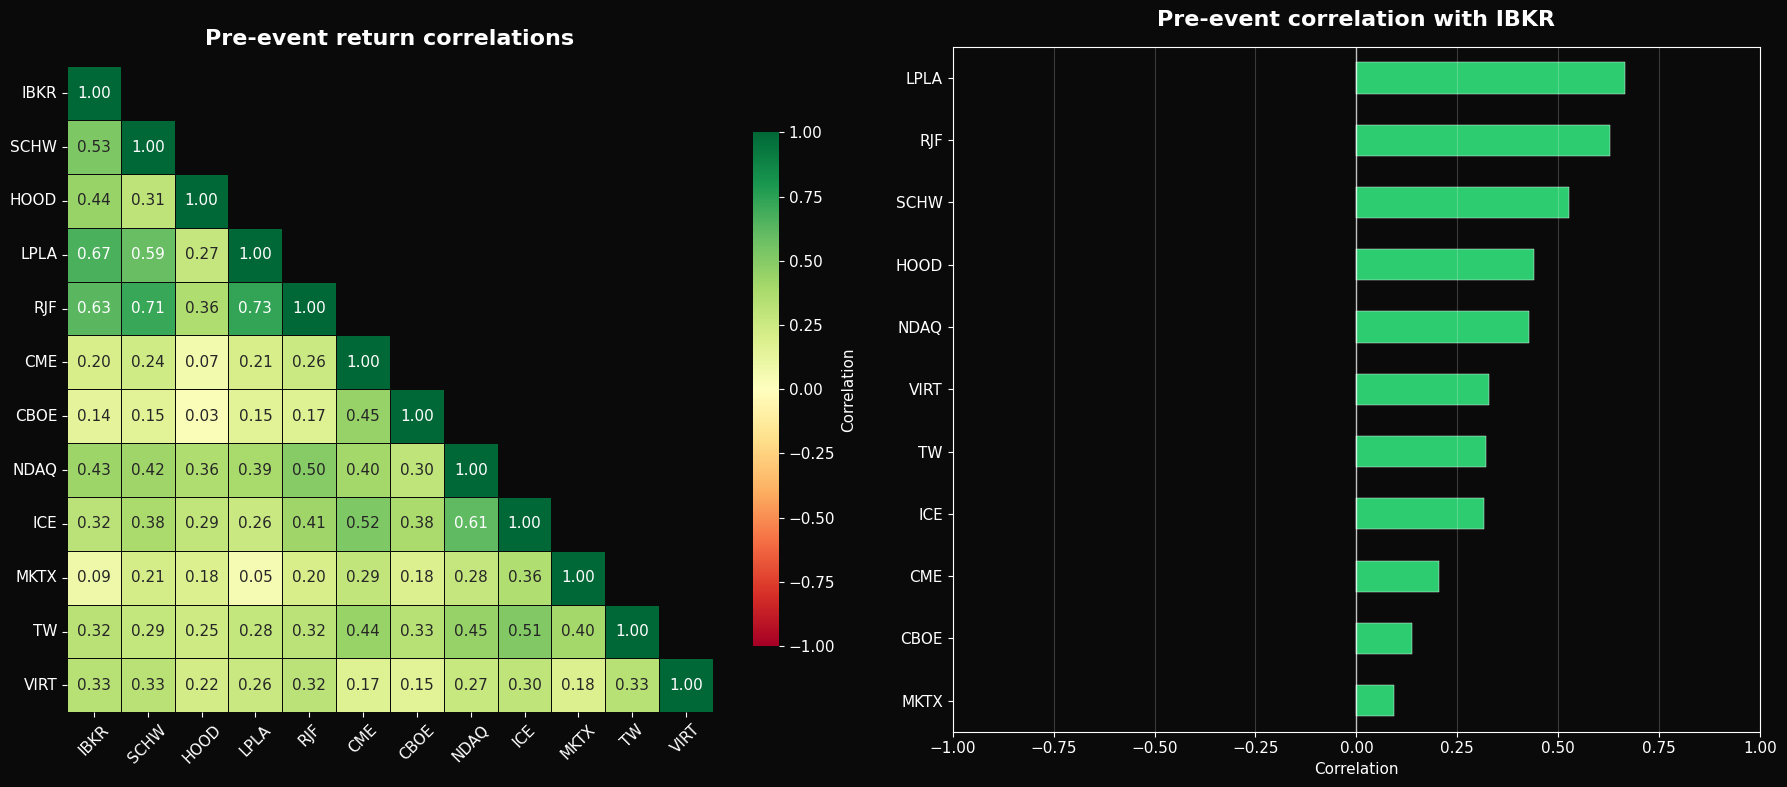

In [21]:
full_pre_event_correlation = pre_event_sample.corr()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8),
)

# Show only the lower half of the symmetric matrix
correlation_mask = np.triu(
    np.ones_like(
        full_pre_event_correlation,
        dtype=bool,
    ),
    k=1,
)

sns.heatmap(
    full_pre_event_correlation,
    mask=correlation_mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    linecolor='#0a0a0a',
    ax=axes[0],
    cbar_kws={
        'shrink': 0.75,
        'label': 'Correlation',
    },
)

axes[0].set_title(
    'Pre-event return correlations',
    fontsize=16,
    fontweight='bold',
    pad=15,
)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].tick_params(
    axis='x',
    rotation=45,
)
axes[0].tick_params(
    axis='y',
    rotation=0,
)
axes[0].grid(False)


# Correlation of each donor with IBKR
ibkr_correlations = (
    full_pre_event_correlation[EVENT.target]
    .drop(EVENT.target)
    .sort_values()
)

bar_colors = [
    '#e74c3c' if value < 0 else '#2ecc71'
    for value in ibkr_correlations
]

ibkr_correlations.plot(
    kind='barh',
    ax=axes[1],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.3,
)

axes[1].axvline(
    x=0,
    color='white',
    linewidth=1,
    alpha=0.7,
)

axes[1].set_title(
    'Pre-event correlation with IBKR',
    fontsize=16,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('Correlation')
axes[1].set_ylabel('')
axes[1].set_xlim(-1, 1)
axes[1].grid(
    axis='x',
    alpha=0.2,
)
axes[1].grid(
    axis='y',
    visible=False,
)

plt.tight_layout()
plt.show()

## 7.1 Findings from the return structure

The donor stocks contain a moderate amount of common information: the average pairwise correlation is approximately **0.32**, while individual correlations range from approximately **0.03 to 0.73**. This means that the donors do not all behave like the same security, but several of them still share meaningful movements.

The stocks most closely related to IBKR are:

- LPL Financial: approximately **0.67**
- Raymond James: approximately **0.63**
- Charles Schwab: approximately **0.53**
- Robinhood: approximately **0.44**

MarketAxess, Cboe and CME have lower direct correlations with IBKR. However, they are not removed automatically because PCA uses relationships across the complete donor universe, not only each donor's individual correlation with IBKR. The leave-one-donor-out test will show whether any of them harms the final result.

In terms of eigenvalues, the donor correlation matrix has the highest one at **4.30**, while the smallest is approximately **0.22**. This gives a condition number of approximately:

$$
\kappa \approx 19.6.
$$

The matrix is, therefore, not close to being singular. At the same time, its eigenvalues are not all equal, which confirms that some common directions are considerably more important than others. Overall, this is a reasonable setting for PCA:

- there is enough shared variation to construct common factors
- the donors are not so similar that they all provide the same information
- using a small number of components may reduce noise relative to a regression containing every donor separately

However, the correlation structure alone does not prove that PCA will predict IBKR well. That question is answered by the walk-forward and final-holdout results.

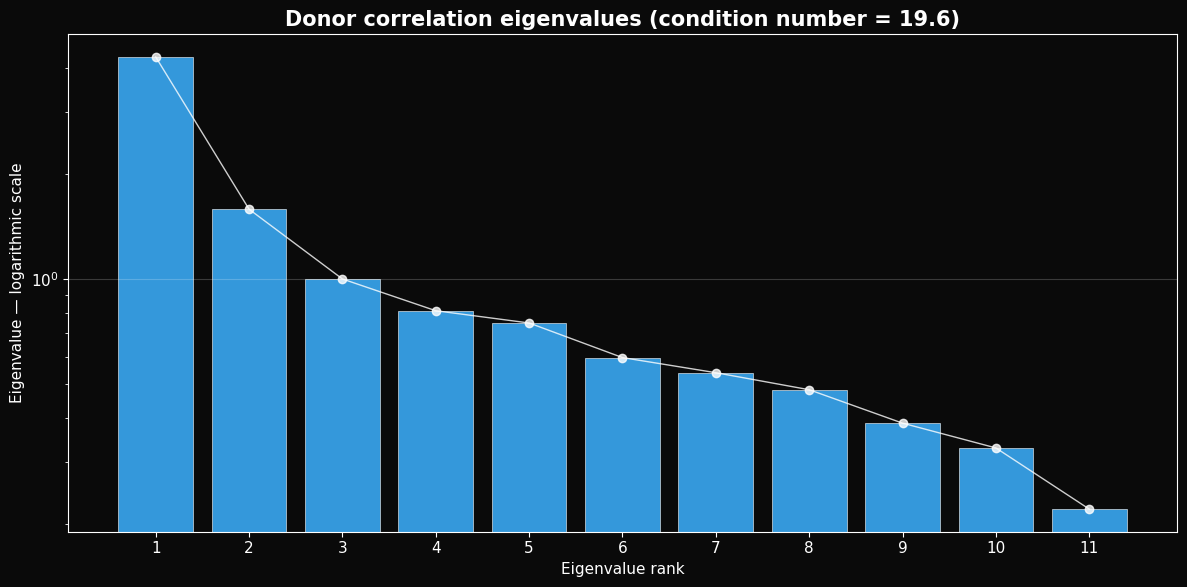

Largest eigenvalue: 4.3050
Smallest eigenvalue: 0.2200
Condition number: 19.56


In [22]:
donor_eigenvalues = np.linalg.eigvalsh(
    donor_correlation
)[::-1]

smallest_eigenvalue = donor_eigenvalues[-1]
largest_eigenvalue = donor_eigenvalues[0]

condition_number = (
    largest_eigenvalue / smallest_eigenvalue
    if smallest_eigenvalue > 0
    else np.inf
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

component_numbers = np.arange(
    1,
    len(donor_eigenvalues) + 1,
)

ax.bar(
    component_numbers,
    donor_eigenvalues,
    color='#3498db',
    edgecolor='white',
    linewidth=0.4,
)

ax.plot(
    component_numbers,
    donor_eigenvalues,
    color='white',
    marker='o',
    linewidth=1,
    alpha=0.8,
)

ax.set_yscale('log')

ax.set_title(
    f'Donor correlation eigenvalues '
    f'(condition number = {condition_number:.1f})',
    fontsize=15,
    fontweight='bold',
)

ax.set_xlabel('Eigenvalue rank')
ax.set_ylabel('Eigenvalue — logarithmic scale')
ax.set_xticks(component_numbers)
ax.grid(
    axis='y',
    alpha=0.2,
)
ax.grid(
    axis='x',
    visible=False,
)

plt.tight_layout()
plt.show()

print(f'Largest eigenvalue: {largest_eigenvalue:.4f}')
print(f'Smallest eigenvalue: {smallest_eigenvalue:.4f}')
print(f'Condition number: {condition_number:.2f}')

## 7.2 Is PCA compression necessary?

Before using PCA, I test whether a standard regression using all 11 donor returns already produces a reliable IBKR counterfactual.

This comparison is important because PCA should not be justified only by assuming that 11 predictors will overfit. If the full OLS model performs well on unseen data and its coefficients remain reasonably stable, there is no evidence of a severe overfitting problem and PCA would then be useful mainly because it creates a simpler model, rather than because OLS has failed.

I compare four different models:

1. **Historical mean:** predicts IBKR's usual average return
2. **SPY market model:** uses only the market return
3. **Equal-weight donor factor:** combines all standardised donor returns with equal weights
4. **Full donor OLS:** estimates a separate coefficient for each of the 11 donors

Performance is measured in three different settings:

- **Development in-sample:** the model is fitted and evaluated on the same observations. This is the most optimistic result
- **Development walk-forward:** each return is estimated using only earlier observations
- **Final holdout:** the model is evaluated on the last 63 admissible trading sessions, which were not used to compare the models

A severely overfitted model would have a low in-sample error followed by a large increase in walk-forward and holdout error, the main error measures are RMSE and MAE, expressed in basis points with lower values that indicate more accurate estimates. The moving-block bootstrap then compares the holdout RMSE of full OLS with each simpler benchmark, consecutive errors are resampled together to preserve some short-term time dependence. If the 95% interval for the OLS improvement remains above zero, the evidence that OLS performs better is stronger.

Finally, the full OLS model is re-estimated at eight expanding sample endpoints, the coefficient table and heatmaps show whether the estimated importance and sign of each donor remain reasonably consistent as new data arrive.

This analysis also provides a useful benchmark for PCA. With all 11 components, principal component regression spans the same predictor information as full OLS. The relevant question is therefore whether a much smaller number of components can preserve similar out-of-sample accuracy.

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


OLS_TARGET = EVENT.target
OLS_DONORS = list(PRIMARY_DONORS)
OLS_MARKET = "SPY"

OLS_MIN_TRAINING_OBSERVATIONS = max(
    252,
    10 * len(OLS_DONORS),
)

OLS_HOLDOUT_OBSERVATIONS = 63
OLS_BOOTSTRAP_DRAWS = 2_000
OLS_RANDOM_SEED = 314


def prepare_ols_diagnostic_data(returns):
    """Create the common sample used by every competing model."""
    required_columns = [
        OLS_TARGET,
        *OLS_DONORS,
        OLS_MARKET,
    ]

    data = (
        returns[required_columns]
        .replace([np.inf, -np.inf], np.nan)
        .sort_index()
        .loc[:STRUCTURE_SAMPLE_END]
        .dropna()
        .copy()
    )

    if len(data) <= (
        OLS_MIN_TRAINING_OBSERVATIONS
        + OLS_HOLDOUT_OBSERVATIONS
    ):
        raise ValueError(
            "Not enough observations for the OLS diagnostic."
        )

    return data


def fit_ols_candidates(training_data, evaluation_data):
    """
    Fit all competing models on training_data and predict
    evaluation_data.
    """
    y_train = training_data[OLS_TARGET].to_numpy()
    y_evaluation = evaluation_data[OLS_TARGET].to_numpy()

    predictions = pd.DataFrame(
        index=evaluation_data.index
    )

    predictions["actual"] = y_evaluation

    # Historical-mean benchmark
    predictions["Historical mean"] = y_train.mean()

    # SPY market model
    spy_model = LinearRegression()

    spy_model.fit(
        training_data[[OLS_MARKET]],
        y_train,
    )

    predictions["SPY market model"] = (
        spy_model.predict(
            evaluation_data[[OLS_MARKET]]
        )
    )

    # Standardise donors using training data only
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        training_data[OLS_DONORS]
    )

    X_evaluation_scaled = scaler.transform(
        evaluation_data[OLS_DONORS]
    )

    # Equal-weight standardised donor factor
    equal_weight_train = (
        X_train_scaled.mean(axis=1)
        .reshape(-1, 1)
    )

    equal_weight_evaluation = (
        X_evaluation_scaled.mean(axis=1)
        .reshape(-1, 1)
    )

    equal_weight_model = LinearRegression()

    equal_weight_model.fit(
        equal_weight_train,
        y_train,
    )

    predictions["Equal-weight donor factor"] = (
        equal_weight_model.predict(
            equal_weight_evaluation
        )
    )

    # Full 11-donor OLS
    full_ols_model = LinearRegression()

    full_ols_model.fit(
        X_train_scaled,
        y_train,
    )

    predictions["Full donor OLS"] = (
        full_ols_model.predict(
            X_evaluation_scaled
        )
    )

    return predictions


def ols_walk_forward_predictions(
    data,
    prediction_dates,
):
    """
    Produce one-step predictions using only observations
    available before each prediction date.
    """
    records = []

    for date in prediction_dates:
        position = data.index.get_loc(date)
        training_data = data.iloc[:position]

        if (
            len(training_data)
            < OLS_MIN_TRAINING_OBSERVATIONS
        ):
            continue

        one_day_prediction = fit_ols_candidates(
            training_data,
            data.loc[[date]],
        )

        records.append(
            one_day_prediction.iloc[0]
        )

    return pd.DataFrame(
        records,
        index=prediction_dates[
            -len(records):
        ],
    )


def score_ols_predictions(predictions):
    """Calculate prediction metrics for all models."""
    actual = predictions["actual"]

    mean_errors = (
        actual
        - predictions["Historical mean"]
    )

    mean_sse = np.sum(
        mean_errors ** 2
    )

    rows = []

    for model_name in predictions.columns:
        if model_name == "actual":
            continue

        errors = (
            actual
            - predictions[model_name]
        )

        rmse = np.sqrt(
            np.mean(errors ** 2)
        )

        mae = np.mean(
            np.abs(errors)
        )

        model_sse = np.sum(
            errors ** 2
        )

        oos_r2 = (
            1 - model_sse / mean_sse
            if mean_sse > 0
            else np.nan
        )

        correlation = (
            actual.corr(
                predictions[model_name]
            )
            if predictions[model_name].std() > 0
            else np.nan
        )

        rows.append({
            "model": model_name,
            "rmse": rmse,
            "mae": mae,
            "oos_r2_vs_mean": oos_r2,
            "correlation": correlation,
        })

    return (
        pd.DataFrame(rows)
        .set_index("model")
    )


def run_ols_diagnostic(returns):
    """Run in-sample, development and holdout comparisons."""
    data = prepare_ols_diagnostic_data(
        returns
    )

    development = data.iloc[
        :-OLS_HOLDOUT_OBSERVATIONS
    ].copy()

    holdout = data.iloc[
        -OLS_HOLDOUT_OBSERVATIONS:
    ].copy()

    # Optimistic in-sample fit
    in_sample_predictions = fit_ols_candidates(
        development,
        development,
    )

    # Development walk-forward predictions
    development_dates = development.index[
        OLS_MIN_TRAINING_OBSERVATIONS:
    ]

    development_predictions = (
        ols_walk_forward_predictions(
            data,
            development_dates,
        )
    )

    # Untouched holdout walk-forward predictions
    holdout_predictions = (
        ols_walk_forward_predictions(
            data,
            holdout.index,
        )
    )

    return {
        "data": data,
        "development": development,
        "holdout": holdout,
        "in_sample_predictions":
            in_sample_predictions,
        "development_predictions":
            development_predictions,
        "holdout_predictions":
            holdout_predictions,
        "in_sample_scores":
            score_ols_predictions(
                in_sample_predictions
            ),
        "development_scores":
            score_ols_predictions(
                development_predictions
            ),
        "holdout_scores":
            score_ols_predictions(
                holdout_predictions
            ),
    }


cc_ols_diagnostic = run_ols_diagnostic(
    cc_log_returns
)

oc_ols_diagnostic = run_ols_diagnostic(
    oc_log_returns
)


OLS_MODEL_ORDER = [
    "Historical mean",
    "SPY market model",
    "Equal-weight donor factor",
    "Full donor OLS",
]


def format_ols_diagnostic(result):
    rows = []

    for model_name in OLS_MODEL_ORDER:
        in_sample = result[
            "in_sample_scores"
        ].loc[model_name]

        development = result[
            "development_scores"
        ].loc[model_name]

        holdout = result[
            "holdout_scores"
        ].loc[model_name]

        rows.append({
            "model": model_name,
            "in_sample_RMSE_bps":
                in_sample["rmse"] * 10_000,
            "development_walk_forward_RMSE_bps":
                development["rmse"] * 10_000,
            "holdout_walk_forward_RMSE_bps":
                holdout["rmse"] * 10_000,
            "holdout_MAE_bps":
                holdout["mae"] * 10_000,
            "holdout_OOS_R2_vs_mean":
                holdout["oos_r2_vs_mean"],
            "holdout_correlation":
                holdout["correlation"],
        })

    return (
        pd.DataFrame(rows)
        .set_index("model")
    )


ols_generalisation_table = pd.concat(
    {
        "Close-to-close":
            format_ols_diagnostic(
                cc_ols_diagnostic
            ),
        "Open-to-close":
            format_ols_diagnostic(
                oc_ols_diagnostic
            ),
    },
    names=[
        "return_definition",
        "model",
    ],
)

display(
    ols_generalisation_table.round(4)
)

in_sample_RMSE_bps  \
return_definition model                                           
Close-to-close    Historical mean                      204.2143   
                  SPY market model                     175.4204   
                  Equal-weight donor factor            165.3570   
                  Full donor OLS                       140.2989   
Open-to-close     Historical mean                      173.3636   
                  SPY market model                     152.3839   
                  Equal-weight donor factor            143.7706   
                  Full donor OLS                       129.5068   

                                             development_walk_forward_RMSE_bps  \
return_definition model                                                          
Close-to-close    Historical mean                                     202.4854   
                  SPY market model                                    184.0993   
                  Equal-weight donor factor                           173.6915   
                  Full donor OLS                                      149.3476   
Open-to-close     Historical mean                                     171.4910   
                  SPY market model                                    157.9760   
                  Equal-weight donor factor                           148.3701   
                  Full donor OLS                                      134.8505   

                                             holdout_walk_forward_RMSE_bps  \
return_definition model                                                      
Close-to-close    Historical mean                                 319.1511   
                  SPY market model                                178.7727   
                  Equal-weight donor factor                       230.8805   
                  Full donor OLS                                  171.2659   
Open-to-close     Historical mean                                 265.6958   
                  SPY market model                                132.0644   
                  Equal-weight donor factor                       170.0687   
                  Full donor OLS                                  123.4144   

                                             holdout_MAE_bps  \
return_definition model                                        
Close-to-close    Historical mean                   201.8323   
                  SPY market model                  126.6519   
                  Equal-weight donor factor         151.4741   
                  Full donor OLS                    112.8484   
Open-to-close     Historical mean                   158.2346   
                  SPY market model                   99.0598   
                  Equal-weight donor factor         107.4185   
                  Full donor OLS                     85.9881   

                                             holdout_OOS_R2_vs_mean  \
return_definition model                                               
Close-to-close    Historical mean                            0.0000   
                  SPY market model                           0.6862   
                  Equal-weight donor factor                  0.4767   
                  Full donor OLS                             0.7120   
Open-to-close     Historical mean                            0.0000   
                  SPY market model                           0.7529   
                  Equal-weight donor factor                  0.5903   
                  Full donor OLS                             0.7842   

                                             holdout_correlation  
return_definition model                                           
Close-to-close    Historical mean                        -0.1477  
                  SPY market model                        0.8755  
                  Equal-weight donor factor               0.7191  
                  Full donor OLS                          0.8670  
Open-to-close     

full_OLS_RMSE_improvement_bps  \
return_definition benchmark                                                  
Close-to-close    Historical mean                                 147.8852   
                  SPY market model                                  7.5068   
                  Equal-weight donor factor                        59.6146   
Open-to-close     Historical mean                                 142.2814   
                  SPY market model                                  8.6500   
                  Equal-weight donor factor                        46.6543   

                                             improvement_95%_low_bps  \
return_definition benchmark                                            
Close-to-close    Historical mean                            61.7156   
                  SPY market model                          -10.9518   
                  Equal-weight donor factor                  18.7639   
Open-to-close     Historical mean                            34.4381   
                  SPY market model                           -1.7341   
                  Equal-weight donor factor                   5.4324   

                                             improvement_95%_high_bps  \
return_definition benchmark                                             
Close-to-close    Historical mean                            224.1666   
                  SPY market model                            22.2440   
                  Equal-weight donor factor                  102.9461   
Open-to-close     Historical mean                            239.7542   
                  SPY market model                            17.5071   
                  Equal-weight donor factor                   83.4223   

                                             interval_entirely_above_zero  \
return_definition benchmark                                                 
Close-to-close    Historical mean                                    True   
                  SPY market model                                  False   
                  Equal-weight donor factor                          True   
Open-to-close     Historical mean                                    True   
                  SPY market model                                  False   
                  Equal-weight donor factor                          True   

                                             bootstrap_fraction_full_OLS_better  \
return_definition benchmark                                                       
Close-to-close    Historical mean                                        1.0000   
                  SPY market model                                       0.7380   
                  Equal-weight donor factor                              0.9995   
Open-to-close     Historical mean                                        1.0000   
                  SPY market model                                       0.9385   
                  Equal-weight donor factor                              0.9930   

                                             bootstrap_block_length  
return_definition benchmark                                          
Close-to-close    Historical mean                                 4  
                  SPY market model                                4  
                  Equal-weight donor factor                       4  
Open-to-close     Historical mean                                 4  
                  SPY market model                                4  
                  Equal-weight donor factor                       4

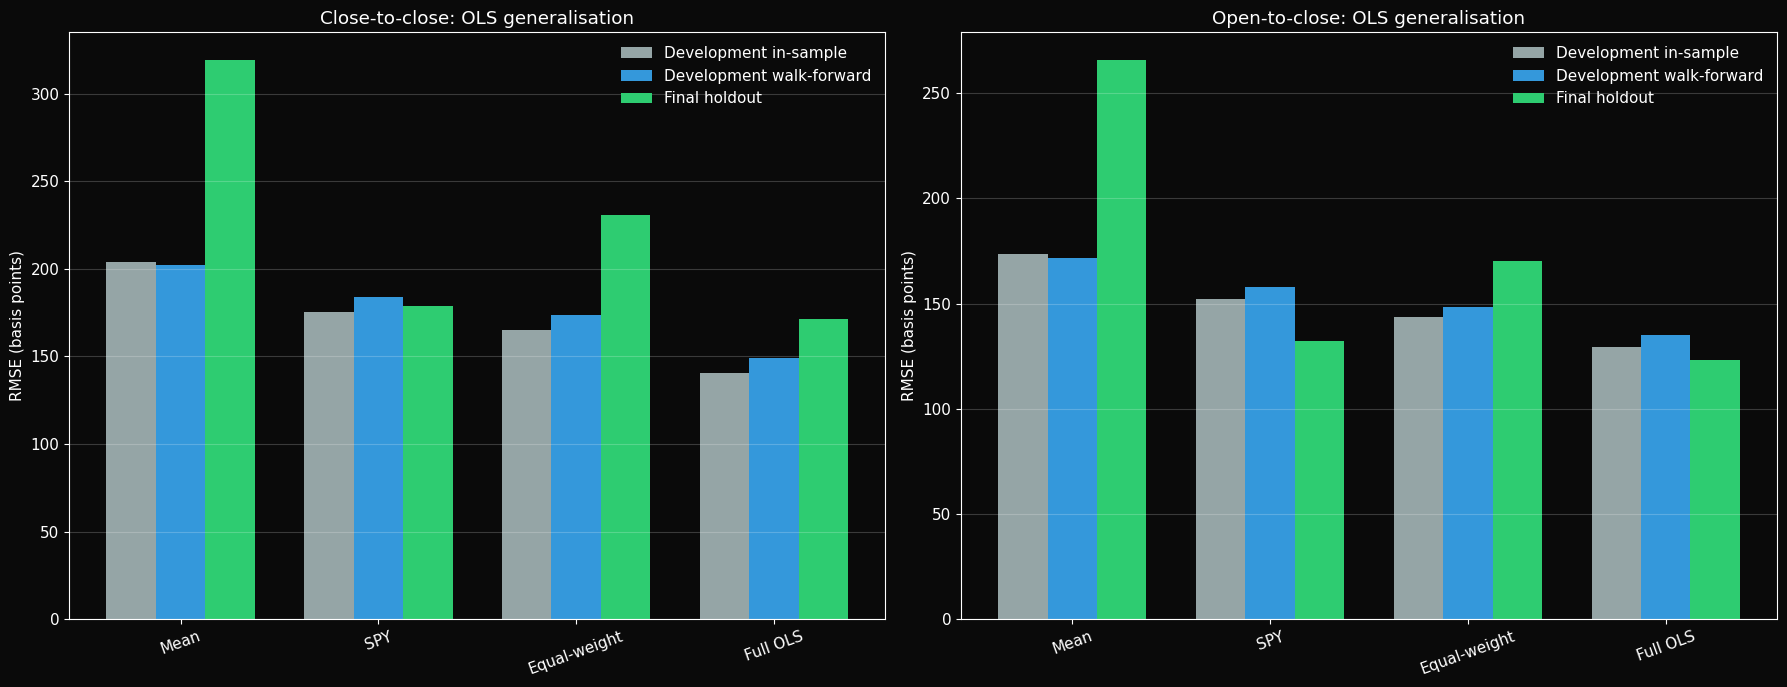

In [24]:
def ols_moving_block_indices(
    sample_size,
    block_length,
    rng,
):
    """Generate one moving-block bootstrap sample."""
    block_length = min(
        block_length,
        sample_size,
    )

    number_of_blocks = int(
        np.ceil(
            sample_size / block_length
        )
    )

    maximum_start = (
        sample_size
        - block_length
    )

    starts = rng.integers(
        0,
        maximum_start + 1,
        size=number_of_blocks,
    )

    indices = np.concatenate([
        np.arange(
            start,
            start + block_length,
        )
        for start in starts
    ])

    return indices[:sample_size]


def bootstrap_full_ols_comparison(
    result,
    return_definition,
    random_seed,
):
    """
    Compare full OLS with simpler benchmarks using paired
    moving-block resamples of the holdout errors.
    """
    predictions = result[
        "holdout_predictions"
    ]

    actual = predictions[
        "actual"
    ].to_numpy()

    full_ols_errors = (
        actual
        - predictions[
            "Full donor OLS"
        ].to_numpy()
    )

    sample_size = len(predictions)

    block_length = max(
        2,
        int(
            np.ceil(
                sample_size ** (1 / 3)
            )
        ),
    )

    rng = np.random.default_rng(
        random_seed
    )

    bootstrap_indices = np.vstack([
        ols_moving_block_indices(
            sample_size,
            block_length,
            rng,
        )
        for _ in range(
            OLS_BOOTSTRAP_DRAWS
        )
    ])

    rows = []

    for benchmark in [
        "Historical mean",
        "SPY market model",
        "Equal-weight donor factor",
    ]:
        benchmark_errors = (
            actual
            - predictions[
                benchmark
            ].to_numpy()
        )

        full_ols_rmse_draws = np.sqrt(
            np.mean(
                full_ols_errors[
                    bootstrap_indices
                ] ** 2,
                axis=1,
            )
        )

        benchmark_rmse_draws = np.sqrt(
            np.mean(
                benchmark_errors[
                    bootstrap_indices
                ] ** 2,
                axis=1,
            )
        )

        improvement_draws = (
            benchmark_rmse_draws
            - full_ols_rmse_draws
        )

        observed_improvement = (
            np.sqrt(
                np.mean(
                    benchmark_errors ** 2
                )
            )
            -
            np.sqrt(
                np.mean(
                    full_ols_errors ** 2
                )
            )
        )

        interval_low, interval_high = (
            np.quantile(
                improvement_draws,
                [0.025, 0.975],
            )
        )

        rows.append({
            "return_definition":
                return_definition,
            "benchmark":
                benchmark,
            "full_OLS_RMSE_improvement_bps":
                observed_improvement * 10_000,
            "improvement_95%_low_bps":
                interval_low * 10_000,
            "improvement_95%_high_bps":
                interval_high * 10_000,
            "interval_entirely_above_zero":
                interval_low > 0,
            "bootstrap_fraction_full_OLS_better":
                np.mean(
                    improvement_draws > 0
                ),
            "bootstrap_block_length":
                block_length,
        })

    return pd.DataFrame(rows)


ols_bootstrap_comparison = pd.concat(
    [
        bootstrap_full_ols_comparison(
            cc_ols_diagnostic,
            "Close-to-close",
            OLS_RANDOM_SEED,
        ),
        bootstrap_full_ols_comparison(
            oc_ols_diagnostic,
            "Open-to-close",
            OLS_RANDOM_SEED + 1,
        ),
    ],
    ignore_index=True,
).set_index([
    "return_definition",
    "benchmark",
])

display(
    ols_bootstrap_comparison.round(4)
)


# Compare optimistic in-sample RMSE with chronological errors.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7),
)

for axis, return_definition in zip(
    axes,
    [
        "Close-to-close",
        "Open-to-close",
    ],
):
    table = (
        ols_generalisation_table
        .loc[return_definition]
        .loc[OLS_MODEL_ORDER]
    )

    x_positions = np.arange(
        len(OLS_MODEL_ORDER)
    )

    bar_width = 0.25

    axis.bar(
        x_positions - bar_width,
        table[
            "in_sample_RMSE_bps"
        ],
        width=bar_width,
        color="#95a5a6",
        label="Development in-sample",
    )

    axis.bar(
        x_positions,
        table[
            "development_walk_forward_RMSE_bps"
        ],
        width=bar_width,
        color="#3498db",
        label="Development walk-forward",
    )

    axis.bar(
        x_positions + bar_width,
        table[
            "holdout_walk_forward_RMSE_bps"
        ],
        width=bar_width,
        color="#2ecc71",
        label="Final holdout",
    )

    axis.set_title(
        f"{return_definition}: OLS generalisation"
    )

    axis.set_ylabel(
        "RMSE (basis points)"
    )

    axis.set_xticks(
        x_positions
    )

    axis.set_xticklabels(
        [
            "Mean",
            "SPY",
            "Equal-weight",
            "Full OLS",
        ],
        rotation=20,
    )

    axis.grid(
        axis="y",
        alpha=0.2,
    )

    axis.grid(
        axis="x",
        visible=False,
    )

    axis.legend(
        frameon=False
    )

plt.tight_layout()
plt.show()

median_coefficient  coefficient_standard_deviation  \
return_definition ticker                                                       
Close-to-close    SCHW                0.1455                          0.0659   
                  HOOD                0.1091                          0.0368   
                  LPLA                0.4136                          0.0551   
                  RJF                 0.1218                          0.0478   
                  CME                 0.0233                          0.0450   
                  CBOE                0.0443                          0.0330   
                  NDAQ                0.0187                          0.0174   
                  ICE                 0.0011                          0.0192   
                  MKTX                0.0164                          0.0467   
                  TW                  0.0525                          0.0183   
                  VIRT                0.0329                          0.0247   
Open-to-close     SCHW                0.1643                          0.0619   
                  HOOD                0.0948                          0.0363   
                  LPLA                0.3115                          0.0385   
                  RJF                 0.1665                          0.0447   
                  CME                 0.0268                          0.0494   
                  CBOE                0.0752                          0.0294   
                  NDAQ                0.0231                          0.0131   
                  ICE                -0.0151                          0.0419   
                  MKTX                0.0034                          0.0411   
                  TW                  0.0597                          0.0119   
                  VIRT                0.0330                          0.0275   

                          minimum_coefficient  maximum_coefficient  \
return_definition ticker                                             
Close-to-close    SCHW                 0.0596               0.2587   
                  HOOD                 0.0939               0.2030   
                  LPLA                 0.2903               0.4633   
                  RJF                  0.0661               0.2343   
                  CME                 -0.0713               0.0542   
                  CBOE                -0.0006               0.0969   
                  NDAQ                 0.0004               0.0499   
                  ICE                 -0.0183               0.0395   
                  MKTX                -0.0629               0.0828   
                  TW                   0.0316               0.0810   
                  VIRT                 0.0110               0.0863   
Open-to-close     SCHW                 0.0974               0.2897   
                  HOOD                 0.0803               0.1870   
                  LPLA                 0.2189               0.3417   
                  RJF                  0.0650               0.2102   
                  CME                 -0.0739               0.0652   
                  CBOE                 0.0397               0.1194   
                  NDAQ                 0.0072               0.0482   
                  ICE                 -0.0487               0.0874   
                  MKTX                -0.0625               0.0782   
                  TW                   0.0428               0.0756   
                  VIRT                 0.0151               0.1017   

                          sign_changes  
return_definition ticker                
Close-to-close    SCHW           False  
                  HOOD           False  
                  LPLA           False  
                  RJF            False  
                  CME             True  
                  CBOE            True  
                  NDAQ           False  
                  ICE             True  
              

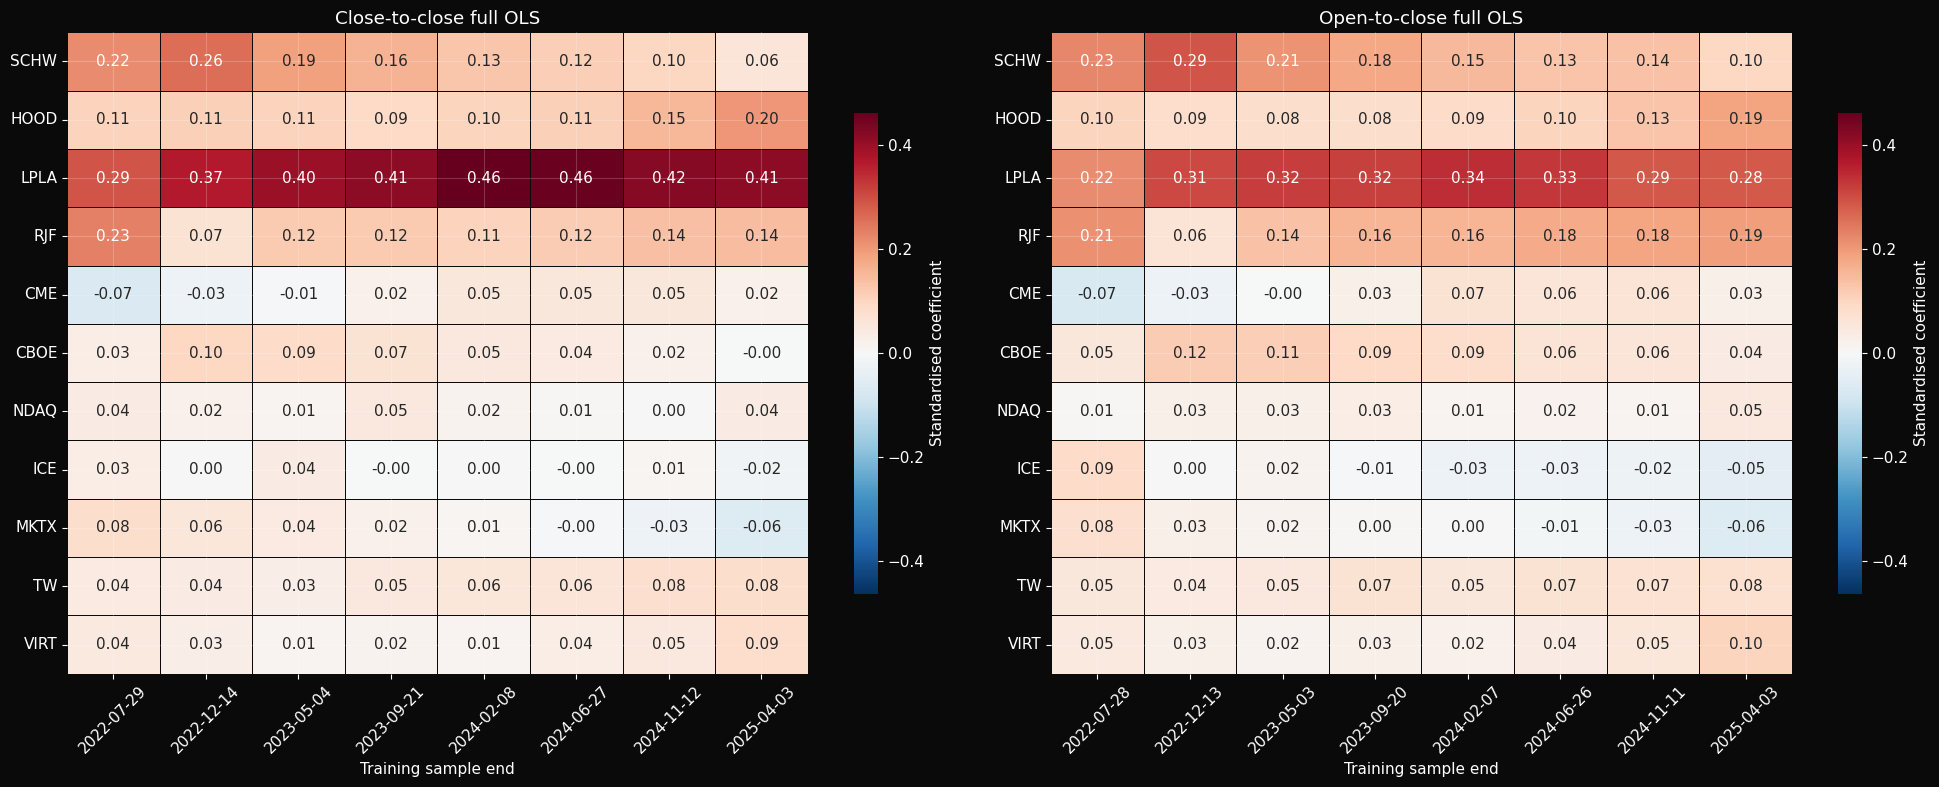

In [25]:
OLS_COEFFICIENT_CHECKPOINTS = 8


def expanding_ols_coefficient_path(result):
    """Estimate standardised OLS coefficients at expanding endpoints."""
    development = result[
        "development"
    ]

    endpoint_positions = np.unique(
        np.linspace(
            OLS_MIN_TRAINING_OBSERVATIONS,
            len(development),
            OLS_COEFFICIENT_CHECKPOINTS,
            dtype=int,
        )
    )

    records = []

    for endpoint_position in endpoint_positions:
        sample = development.iloc[
            :endpoint_position
        ]

        scaler = StandardScaler()

        X_scaled = scaler.fit_transform(
            sample[OLS_DONORS]
        )

        y = sample[
            OLS_TARGET
        ].to_numpy()

        y_standard_deviation = y.std(
            ddof=0
        )

        if y_standard_deviation <= 0:
            raise ValueError(
                "The target volatility is zero."
            )

        y_scaled = (
            y - y.mean()
        ) / y_standard_deviation

        model = LinearRegression()

        model.fit(
            X_scaled,
            y_scaled,
        )

        training_end = (
            sample.index[-1].date()
        )

        for ticker, coefficient in zip(
            OLS_DONORS,
            model.coef_,
        ):
            records.append({
                "training_end":
                    training_end,
                "ticker":
                    ticker,
                "standardised_coefficient":
                    coefficient,
            })

    coefficient_path = (
        pd.DataFrame(records)
        .pivot(
            index="ticker",
            columns="training_end",
            values="standardised_coefficient",
        )
        .reindex(OLS_DONORS)
    )

    return coefficient_path


cc_ols_coefficient_path = (
    expanding_ols_coefficient_path(
        cc_ols_diagnostic
    )
)

oc_ols_coefficient_path = (
    expanding_ols_coefficient_path(
        oc_ols_diagnostic
    )
)


def coefficient_stability_summary(
    coefficient_path,
):
    summary = pd.DataFrame(
        index=coefficient_path.index
    )

    summary["median_coefficient"] = (
        coefficient_path.median(axis=1)
    )

    summary[
        "coefficient_standard_deviation"
    ] = coefficient_path.std(axis=1)

    summary["minimum_coefficient"] = (
        coefficient_path.min(axis=1)
    )

    summary["maximum_coefficient"] = (
        coefficient_path.max(axis=1)
    )

    summary["sign_changes"] = (
        (
            summary["minimum_coefficient"] < 0
        )
        &
        (
            summary["maximum_coefficient"] > 0
        )
    )

    return summary


ols_coefficient_stability = pd.concat(
    {
        "Close-to-close":
            coefficient_stability_summary(
                cc_ols_coefficient_path
            ),
        "Open-to-close":
            coefficient_stability_summary(
                oc_ols_coefficient_path
            ),
    },
    names=[
        "return_definition",
        "ticker",
    ],
)

display(
    ols_coefficient_stability.round(4)
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 8),
)

coefficient_plot_inputs = [
    (
        axes[0],
        cc_ols_coefficient_path,
        "Close-to-close full OLS",
    ),
    (
        axes[1],
        oc_ols_coefficient_path,
        "Open-to-close full OLS",
    ),
]

maximum_absolute_coefficient = max(
    np.abs(
        cc_ols_coefficient_path.to_numpy()
    ).max(),
    np.abs(
        oc_ols_coefficient_path.to_numpy()
    ).max(),
)

for axis, coefficient_path, title in (
    coefficient_plot_inputs
):
    sns.heatmap(
        coefficient_path,
        cmap="RdBu_r",
        center=0,
        vmin=-maximum_absolute_coefficient,
        vmax=maximum_absolute_coefficient,
        annot=True,
        fmt=".2f",
        linewidths=0.4,
        linecolor="#0a0a0a",
        ax=axis,
        cbar_kws={
            "shrink": 0.75,
            "label": "Standardised coefficient",
        },
    )

    axis.set_title(
        title
    )

    axis.set_xlabel(
        "Training sample end"
    )

    axis.set_ylabel("")

    axis.tick_params(
        axis="x",
        rotation=45,
    )

    axis.tick_params(
        axis="y",
        rotation=0,
    )

plt.tight_layout()
plt.show()

## 7.3 Findings from the full OLS diagnostic

The results do not show a strong predictive overfitting problem.

For close-to-close returns, full OLS RMSE increases from approximately **140 basis points in-sample** to **149 basis points during walk-forward validation** and **171 basis points in the final holdout**. It true that the deterioration is visible but it is not extreme. Part of the larger holdout error may also reflect a more difficult market period because the historical-mean and equal-weight models deteriorate more sharply.

For open-to-close returns, full OLS RMSE moves from approximately **130 basis points in-sample** to **135 basis points during walk-forward validation**, before improving to approximately **123 basis points in the holdout**. This provides little evidence of overfitting.

The generalisation table and grouped bar charts show that:

- full OLS improves on the historical mean
- full OLS also performs materially better than the equal-weight donor factor
- full OLS produces slightly lower RMSE than the SPY model, with a relativly small advantage

The bootstrap table also supports this interpretation, with the 95% intervals for the OLS improvement over the historical mean and equal-weight factor remain above zero. By contrast, the intervals for the improvement over SPY include zero for both return definitions. Therefore, the additional donors contain useful information collectively, but the evidence that all 11 predictors reliably outperform a simple market model is not conclusive. The coefficient table reports the median, dispersion and range of each standardised coefficient across the expanding estimation samples, while the heatmaps show the same information visually: each column represents a later training endpoint, while each row represents one donor.

The largest coefficients, particularly those of **LPLA, SCHW, RJF and HOOD**, remain positive across all checkpoints. This suggests that the main brokerage relationships are reasonably stable and sign changes are concentrated in smaller coefficients such as CME, ICE and MKTX. These securities appear to add limited and less stable marginal information after the other donors are already included. The coefficient paths should not be described as statistically stable because no formal stability test or confidence interval has been calculated. They instead show that there is **no obvious practical breakdown among the main predictors**, while some low-contribution coefficients remain sensitive to the estimation sample.

Overall, the full OLS model is usable and does not display severe overfitting, the purpose of PCA in this case is to test whether the common information in 11 donor returns can be represented by only a few components without materially reducing out-of-sample accuracy. Because PCA selects high-variance directions rather than directions chosen specifically to predict IBKR, this simplification must be justified by the subsequent walk-forward and holdout results.

# 8. Building and validating the PCA counterfactual model

The purpose of this section is to estimate the return that IBKR would normally earn when comparable financial companies move. The difference between the actual and estimated return is:

$$
AR_t
=
r_{IBKR,t}
-
\widehat r_{IBKR,t}.
$$

This is an **event-associated abnormal return**, but it is not automatically the return caused by passive funds.

## 8.1 From donor returns to an IBKR counterfactual

PCA compresses the 11 donor returns into a smaller number of common movements. Each donor is first standardised using parameters estimated from the training sample:

$$
X^*_{i,t}
=
\frac{X_{i,t}-\mu_i}{\sigma_i}.
$$

PCA then forms weighted portfolios of the standardised donor returns:

$$
Z_t=X_t^*V.
$$

Each column of $V$ is a principal-component weighting vector. The first component is the donor portfolio with the greatest historical variation, while later components describe different and progressively smaller directions of variation.

I then regress IBKR's return on the first $K$ component returns:

$$
r_{IBKR,t}
=
\alpha
+
\beta_1PC_{1,t}
+\cdots+
\beta_KPC_{K,t}
+\varepsilon_t.
$$

This is a principal component regression, or PCR. Using few components can reduce nois, using too few can discard useful information. The number of components is selected using out-of-sample performance rather than an arbitrary explained-variance threshold.

## 8.2 Validation and the anticipation cutoff

The public discussion of IBKR as a possible S&P 500 candidate began on 8 July 2025. The final model is therefore allowed to use observations only through the previous trading session.

The data are divided chronologically into:

1. **Development period:** used to compare different values of $K$
2. **Final holdout:** the last 63 admissible sessions ending before possible anticipation, basically a trading quarter
3. **Possible-anticipation period:** 8 July through 25 August, excluded from model construction
4. **Announcement and implementation period:** also completely excluded from model construction

Inside the development period, expanding walk-forward validation repeatedly:

- fits the model using earlier observations
- observes the donor returns on the next day
- estimates IBKR's normal return for that day
- records the prediction error
- moves forward by one session

The scaler, PCA and regression are refitted using past data at every step and this prevents preprocessing leakage.

## 8.3 Selecting the number of components

I compare $K=1,\ldots,11$ using:

- RMSE
- MAE
- out-of-sample $R^2$
- actual-predicted correlation
- comparison with a historical mean, SPY model and equal-weight donor factor

The model with the lowest development RMSE is the empirical best fit. Small RMSE differences may be noise, so the one-standard-error rule chooses the smallest $K$ sufficiently close to that minimum. This RMSE standard error is estimated using a moving-block bootstrap: consecutive residuals are resampled together so that some time dependence is retained.

## 8.4 Final holdout 

The selected $K$ is evaluated on the untouched holdout and cannot be changed afterward. A useful counterfactual should:

- improve on the historical-mean model
- compete with SPY and the equal-weight donor model
- have positive out-of-sample $R^2$
- avoid needing almost all components
- leave residuals without strong bias or serial dependence

After validation, two models are frozen using all admissible observations through the session before 8 July:

- a close-to-close model
- an open-to-close model

They are separate because overnight and regular-session returns can have different relationships with the donor stocks. Even a well-validated PCR model cannot prove that an event residual was caused by index funds. Its role is narrower: remove the portion of IBKR's return associated with the observed common donor movements.

In [155]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


TARGET = EVENT.target
DONORS = list(PRIMARY_DONORS)
MARKET_BENCHMARK = 'SPY'

MIN_TRAINING_OBSERVATIONS = max(
    252,
    10 * len(DONORS),
)

HOLDOUT_OBSERVATIONS = 63
BOOTSTRAP_DRAWS = 2_000
RANDOM_SEED = 42


def as_session_date(value):
    '''Return a timezone-naive, normalised timestamp.'''
    timestamp = pd.Timestamp(value)

    if timestamp.tzinfo is not None:
        timestamp = timestamp.tz_localize(None)

    return timestamp.normalize()


# Every observation from the first public candidate signal onward
# is excluded from model selection and final estimation.
QUARANTINE_DATES = pd.DatetimeIndex([
    as_session_date(
        session_for_event_time(event_time)
    )
    for event_time in range(
        ANTICIPATION_START_T,
        0,
    )
])

MODEL_CUTOFF = as_session_date(
    session_for_event_time(
        ANTICIPATION_START_T - 1
    )
)


def prepare_model_data(returns):
    '''
    Keep the target, donors and SPY only through MODEL_CUTOFF.

    Missing or infinite observations are removed so all competing
    models are evaluated on the same dates.
    '''
    required_columns = [
        TARGET,
        *DONORS,
        MARKET_BENCHMARK,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in returns.columns
    ]

    if missing_columns:
        raise KeyError(
            'Missing return columns: '
            + ', '.join(missing_columns)
        )

    data = (
        returns[required_columns]
        .replace([np.inf, -np.inf], np.nan)
        .copy()
    )

    data.index = pd.to_datetime(
        data.index
    )

    if data.index.tz is not None:
        data.index = (
            data.index.tz_localize(None)
        )

    data.index = data.index.normalize()

    data = (
        data
        .sort_index()
        .loc[
            lambda frame:
            ~frame.index.duplicated(
                keep='last'
            )
        ]
        .loc[:MODEL_CUTOFF]
        .dropna()
    )

    if data.empty:
        raise ValueError(
            'The modelling sample is empty.'
        )

    return data


def create_validation_design(data):
    '''Split admissible data into development and holdout periods.'''
    required_observations = (
        MIN_TRAINING_OBSERVATIONS
        + HOLDOUT_OBSERVATIONS
        + 1
    )

    if len(data) < required_observations:
        raise ValueError(
            f'At least {required_observations} complete observations '
            f'are required, but only {len(data)} are available.'
        )

    development = data.iloc[
        :-HOLDOUT_OBSERVATIONS
    ].copy()

    holdout = data.iloc[
        -HOLDOUT_OBSERVATIONS:
    ].copy()

    walk_forward_dates = development.index[
        MIN_TRAINING_OBSERVATIONS:
    ]

    return {
        'all_pre_event': data,
        'development': development,
        'holdout': holdout,
        'walk_forward_dates':
            walk_forward_dates,
    }


cc_model_data = prepare_model_data(
    cc_log_returns
)

oc_model_data = prepare_model_data(
    oc_log_returns
)

cc_validation_design = (
    create_validation_design(
        cc_model_data
    )
)

oc_validation_design = (
    create_validation_design(
        oc_model_data
    )
)


def validation_summary_row(design):
    return {
        'sample_start':
            design['all_pre_event']
            .index.min().date(),
        'development_end':
            design['development']
            .index.max().date(),
        'holdout_start':
            design['holdout']
            .index.min().date(),
        'holdout_end':
            design['holdout']
            .index.max().date(),
        'model_cutoff':
            MODEL_CUTOFF.date(),
        'possible_anticipation_start':
            POSSIBLE_ANTICIPATION_START.date(),
        'development_observations':
            len(design['development']),
        'walk_forward_predictions':
            len(design['walk_forward_dates']),
        'holdout_observations':
            len(design['holdout']),
    }


validation_summary = pd.DataFrame(
    {
        'Close-to-close':
            validation_summary_row(
                cc_validation_design
            ),
        'Open-to-close':
            validation_summary_row(
                oc_validation_design
            ),
    }
).T

assert TARGET not in DONORS
assert len(DONORS) == len(set(DONORS))
assert len(DONORS) == 11

assert (
    MODEL_CUTOFF
    < QUARANTINE_DATES.min()
)

assert not MODEL_CUTOFF in QUARANTINE_DATES

validation_summary

,sample_start,development_end,holdout_start,holdout_end,model_cutoff,possible_anticipation_start,development_observations,walk_forward_predictions,holdout_observations
Close-to-close,2021-07-30,2025-04-03,2025-04-04,2025-07-07,2025-07-07,2025-07-08,924,672,63
Open-to-close,2021-07-29,2025-04-03,2025-04-04,2025-07-07,2025-07-07,2025-07-08,925,673,63


In [156]:
def one_factor_prediction(
    factor_train,
    target_train,
    factor_test,
):
    '''OLS prediction using an intercept and one factor.'''
    factor_train = np.asarray(
        factor_train,
        dtype=float,
    )

    target_train = np.asarray(
        target_train,
        dtype=float,
    )

    design_matrix = np.column_stack([
        np.ones(len(factor_train)),
        factor_train,
    ])

    coefficients = np.linalg.lstsq(
        design_matrix,
        target_train,
        rcond=None,
    )[0]

    return float(
        coefficients[0]
        + coefficients[1] * factor_test
    )


def predict_all_pcr_models(
    training_data,
    test_row,
):
    '''
    Fit the scaler and full PCA using the training sample.

    Return predictions using the first 1, 2, ..., 11 components,
    together with the benchmark-model predictions.
    '''
    X_train = training_data[DONORS].to_numpy()
    y_train = training_data[TARGET].to_numpy()

    X_test = (
        test_row[DONORS]
        .to_numpy(dtype=float)
        .reshape(1, -1)
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_test_scaled = scaler.transform(
        X_test
    )

    pca = PCA(
        n_components=len(DONORS),
        svd_solver='full',
    )

    training_scores = pca.fit_transform(
        X_train_scaled
    )

    test_scores = pca.transform(
        X_test_scaled
    )[0]

    # Because PCA scores are orthogonal, each OLS coefficient can
    # be calculated independently. Cumulative contributions then
    # give the prediction for K = 1, ..., 11.
    target_centered = y_train - y_train.mean()

    score_variances = np.sum(
        training_scores ** 2,
        axis=0,
    )

    score_covariances = (
        training_scores.T
        @ target_centered
    )

    component_coefficients = np.divide(
        score_covariances,
        score_variances,
        out=np.zeros_like(score_covariances),
        where=score_variances > 1e-12,
    )

    component_contributions = (
        test_scores
        * component_coefficients
    )

    pcr_predictions = (
        y_train.mean()
        + np.cumsum(component_contributions)
    )

    # Benchmark 1: historical mean
    historical_mean_prediction = float(
        y_train.mean()
    )

    # Benchmark 2: SPY market model
    spy_prediction = one_factor_prediction(
        training_data[MARKET_BENCHMARK],
        y_train,
        test_row[MARKET_BENCHMARK],
    )

    # Benchmark 3: equal-weight standardised donor factor
    equal_weight_training_factor = (
        X_train_scaled.mean(axis=1)
    )

    equal_weight_test_factor = float(
        X_test_scaled.mean()
    )

    equal_weight_prediction = one_factor_prediction(
        equal_weight_training_factor,
        y_train,
        equal_weight_test_factor,
    )

    predictions = {
        'Historical mean': historical_mean_prediction,
        'SPY market model': spy_prediction,
        'Equal-weight donor factor': equal_weight_prediction,
    }

    predictions.update({
        f'PCR_{component_count}': float(
            pcr_predictions[component_count - 1]
        )
        for component_count in range(
            1,
            len(DONORS) + 1,
        )
    })

    return predictions


def walk_forward_predictions(
    data,
    prediction_dates,
):
    '''
    Generate expanding-window, one-step counterfactual estimates.

    The same-day donor returns are observed, but the same-day IBKR
    return is never included in that day's training sample.
    '''
    records = []

    for date in prediction_dates:
        position = data.index.get_loc(date)

        training_data = data.iloc[:position]
        test_row = data.iloc[position]

        if len(training_data) < MIN_TRAINING_OBSERVATIONS:
            continue

        predictions = predict_all_pcr_models(
            training_data,
            test_row,
        )

        records.append({
            'date': date,
            'actual': float(test_row[TARGET]),
            **predictions,
        })

    prediction_frame = (
        pd.DataFrame(records)
        .set_index('date')
        .sort_index()
    )

    return prediction_frame


def score_predictions(prediction_frame):
    '''Calculate out-of-sample performance statistics.'''
    actual = prediction_frame['actual']

    mean_errors = (
        actual
        - prediction_frame['Historical mean']
    )

    mean_sse = np.sum(mean_errors ** 2)

    rows = []

    for model_name in prediction_frame.columns:
        if model_name == 'actual':
            continue

        prediction = prediction_frame[model_name]
        errors = actual - prediction

        rmse = np.sqrt(
            np.mean(errors ** 2)
        )

        mae = np.mean(
            np.abs(errors)
        )

        model_sse = np.sum(
            errors ** 2
        )

        if mean_sse > 0:
            oos_r2 = 1 - model_sse / mean_sse
        else:
            oos_r2 = np.nan

        if (
            actual.std() > 0
            and prediction.std() > 0
        ):
            correlation = actual.corr(
                prediction
            )
        else:
            correlation = np.nan

        rows.append({
            'model': model_name,
            'rmse': rmse,
            'mae': mae,
            'oos_r2_vs_mean': oos_r2,
            'correlation': correlation,
        })

    return (
        pd.DataFrame(rows)
        .set_index('model')
    )


def moving_block_indices(
    sample_size,
    block_length,
    rng,
):
    '''Generate one moving-block bootstrap sample.'''
    block_length = min(
        block_length,
        sample_size,
    )

    number_of_blocks = int(
        np.ceil(sample_size / block_length)
    )

    maximum_start = (
        sample_size
        - block_length
    )

    starts = rng.integers(
        0,
        maximum_start + 1,
        size=number_of_blocks,
    )

    indices = np.concatenate([
        np.arange(
            start,
            start + block_length,
        )
        for start in starts
    ])

    return indices[:sample_size]


def select_component_count(
    prediction_frame,
    score_table,
    bootstrap_draws=BOOTSTRAP_DRAWS,
    random_seed=RANDOM_SEED,
):
    '''
    Apply the one-standard-error rule to development RMSE.

    The bootstrap estimates the sampling variability of the lowest
    observed PCR RMSE.
    '''
    pcr_models = [
        f'PCR_{component_count}'
        for component_count in range(
            1,
            len(DONORS) + 1,
        )
    ]

    pcr_scores = score_table.loc[
        pcr_models
    ].copy()

    best_model = pcr_scores['rmse'].idxmin()
    best_component_count = int(
        best_model.split('_')[1]
    )

    actual = prediction_frame['actual'].to_numpy()
    best_prediction = prediction_frame[
        best_model
    ].to_numpy()

    best_errors = (
        actual
        - best_prediction
    )

    sample_size = len(best_errors)

    block_length = max(
        2,
        int(np.ceil(sample_size ** (1 / 3))),
    )

    rng = np.random.default_rng(
        random_seed
    )

    bootstrap_rmse = np.empty(
        bootstrap_draws
    )

    for draw in range(bootstrap_draws):
        sample_indices = moving_block_indices(
            sample_size,
            block_length,
            rng,
        )

        bootstrap_rmse[draw] = np.sqrt(
            np.mean(
                best_errors[sample_indices] ** 2
            )
        )

    rmse_standard_error = bootstrap_rmse.std(
        ddof=1
    )

    selection_threshold = (
        pcr_scores.loc[best_model, 'rmse']
        + rmse_standard_error
    )

    eligible_components = [
        component_count
        for component_count in range(
            1,
            len(DONORS) + 1,
        )
        if (
            pcr_scores.loc[
                f'PCR_{component_count}',
                'rmse',
            ]
            <= selection_threshold
        )
    ]

    selected_component_count = min(
        eligible_components
    )

    return {
        'best_model': best_model,
        'best_component_count': best_component_count,
        'selected_component_count': selected_component_count,
        'rmse_standard_error': rmse_standard_error,
        'selection_threshold': selection_threshold,
        'block_length': block_length,
        'bootstrap_rmse': bootstrap_rmse,
    }


def run_development_validation(
    data,
    validation_design,
    random_seed=RANDOM_SEED,
):
    predictions = walk_forward_predictions(
        data,
        validation_design['walk_forward_dates'],
    )

    scores = score_predictions(
        predictions
    )

    selection = select_component_count(
        predictions,
        scores,
        random_seed=random_seed,
    )

    return {
        'design': validation_design,
        'predictions': predictions,
        'scores': scores,
        'selection': selection,
    }

,empirical_best_K,selected_K,selected_RMSE_bps,minimum_RMSE_bps,one_SE_threshold_bps,bootstrap_block_length
Close-to-close,11.0,2.0,154.637,149.348,157.960,9.0
Open-to-close,9.0,2.0,136.553,134.351,140.633,9.0


RMSE_bps   MAE_bps  \
return_definition model                                           
Close-to-close    Historical mean            202.4855  145.2277   
                  SPY market model           184.0994  130.2252   
                  Equal-weight donor factor  173.6915  122.8214   
                  PCR_2                      154.6373  111.8352   
Open-to-close     Historical mean            171.4910  126.1843   
                  SPY market model           157.9760  115.6243   
                  Equal-weight donor factor  148.3701  110.2307   
                  PCR_2                      136.5526  102.5801   

                                             OOS_R2_vs_mean  \
return_definition model                                       
Close-to-close    Historical mean                    0.0000   
                  SPY market model                   0.1734   
                  Equal-weight donor factor          0.2642   
                  PCR_2                              0.4168   
Open-to-close     Historical mean                    0.0000   
                  SPY market model                   0.1514   
                  Equal-weight donor factor          0.2515   
                  PCR_2                              0.3660   

                                             actual_predicted_correlation  
return_definition model                                                    
Close-to-close    Historical mean                                 -0.0683  
                  SPY market model                                 0.4159  
                  Equal-weight donor factor                        0.5115  
                  PCR_2                                            0.6445  
Open-to-close     Historical mean                                 -0.1181  
                  SPY market model                                 0.3906  
                  Equal-weight donor factor                        0.5004  
                  PCR_2                                            0.6040

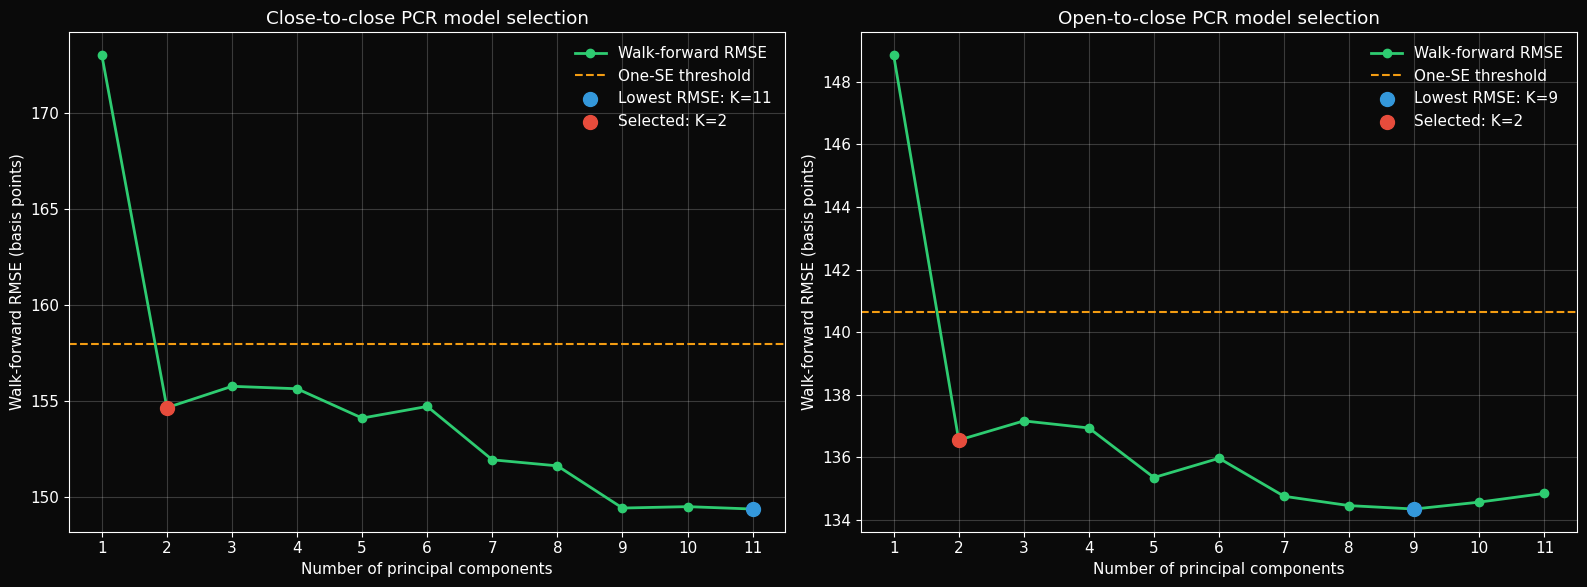

In [157]:
cc_development_result = run_development_validation(
    cc_model_data,
    cc_validation_design,
    random_seed=RANDOM_SEED,
)

oc_development_result = run_development_validation(
    oc_model_data,
    oc_validation_design,
    random_seed=RANDOM_SEED + 1,
)


def selection_summary_row(result):
    selection = result['selection']
    scores = result['scores']

    selected_model = (
        f'PCR_{selection['selected_component_count']}'
    )

    return {
        'empirical_best_K': selection[
            'best_component_count'
        ],
        'selected_K': selection[
            'selected_component_count'
        ],
        'selected_RMSE_bps': (
            scores.loc[selected_model, 'rmse']
            * 10_000
        ),
        'minimum_RMSE_bps': (
            scores.loc[
                selection['best_model'],
                'rmse',
            ]
            * 10_000
        ),
        'one_SE_threshold_bps': (
            selection['selection_threshold']
            * 10_000
        ),
        'bootstrap_block_length': selection[
            'block_length'
        ],
    }


component_selection_summary = pd.DataFrame(
    {
        'Close-to-close': selection_summary_row(
            cc_development_result
        ),
        'Open-to-close': selection_summary_row(
            oc_development_result
        ),
    }
).T

display(component_selection_summary.round(3))


def compact_development_comparison(result):
    selected_model = (
        'PCR_'
        + str(
            result['selection'][
                'selected_component_count'
            ]
        )
    )

    models = [
        'Historical mean',
        'SPY market model',
        'Equal-weight donor factor',
        selected_model,
    ]

    table = result['scores'].loc[
        models,
        [
            'rmse',
            'mae',
            'oos_r2_vs_mean',
            'correlation',
        ],
    ].copy()

    table['rmse'] *= 10_000
    table['mae'] *= 10_000

    return table.rename(
        columns={
            'rmse': 'RMSE_bps',
            'mae': 'MAE_bps',
            'oos_r2_vs_mean': 'OOS_R2_vs_mean',
            'correlation': 'actual_predicted_correlation',
        }
    )


development_model_comparison = pd.concat(
    {
        'Close-to-close': compact_development_comparison(
            cc_development_result
        ),
        'Open-to-close': compact_development_comparison(
            oc_development_result
        ),
    },
    names=[
        'return_definition',
        'model',
    ],
)

display(
    development_model_comparison.round(4)
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
)

plot_inputs = [
    (
        axes[0],
        cc_development_result,
        'Close-to-close',
    ),
    (
        axes[1],
        oc_development_result,
        'Open-to-close',
    ),
]

for axis, result, title in plot_inputs:
    component_counts = np.arange(
        1,
        len(DONORS) + 1,
    )

    rmse_values = np.array([
        result['scores'].loc[
            f'PCR_{component_count}',
            'rmse',
        ]
        * 10_000
        for component_count in component_counts
    ])

    selected_k = result['selection'][
        'selected_component_count'
    ]

    best_k = result['selection'][
        'best_component_count'
    ]

    threshold = (
        result['selection'][
            'selection_threshold'
        ]
        * 10_000
    )

    axis.plot(
        component_counts,
        rmse_values,
        marker='o',
        color='#2ecc71',
        linewidth=2,
        label='Walk-forward RMSE',
    )

    axis.axhline(
        threshold,
        color='#f39c12',
        linestyle='--',
        linewidth=1.5,
        label='One-SE threshold',
    )

    axis.scatter(
        best_k,
        rmse_values[best_k - 1],
        color='#3498db',
        s=100,
        zorder=3,
        label=f'Lowest RMSE: K={best_k}',
    )

    axis.scatter(
        selected_k,
        rmse_values[selected_k - 1],
        color='#e74c3c',
        s=100,
        zorder=4,
        label=f'Selected: K={selected_k}',
    )

    axis.set_title(
        f'{title} PCR model selection'
    )

    axis.set_xlabel(
        'Number of principal components'
    )

    axis.set_ylabel(
        'Walk-forward RMSE (basis points)'
    )

    axis.set_xticks(
        component_counts
    )

    axis.legend(
        frameon=False
    )

plt.tight_layout()
plt.show()

RMSE_bps   MAE_bps  \
return_definition model                                           
Close-to-close    Historical mean            319.1512  201.8325   
                  SPY market model           178.7729  126.6521   
                  Equal-weight donor factor  230.8807  151.4743   
                  PCR_2                      171.4179  116.5162   
Open-to-close     Historical mean            265.6958  158.2346   
                  SPY market model           132.0644   99.0598   
                  Equal-weight donor factor  170.0687  107.4185   
                  PCR_2                      122.1221   86.9832   

                                             OOS_R2_vs_mean  \
return_definition model                                       
Close-to-close    Historical mean                    0.0000   
                  SPY market model                   0.6862   
                  Equal-weight donor factor          0.4767   
                  PCR_2                              0.7115   
Open-to-close     Historical mean                    0.0000   
                  SPY market model                   0.7529   
                  Equal-weight donor factor          0.5903   
                  PCR_2                              0.7887   

                                             actual_predicted_correlation  \
return_definition model                                                     
Close-to-close    Historical mean                                 -0.1477   
                  SPY market model                                 0.8755   
                  Equal-weight donor factor                        0.7191   
                  PCR_2                                            0.8939   
Open-to-close     Historical mean                                 -0.2888   
                  SPY market model                                 0.9157   
                  Equal-weight donor factor                        0.8006   
                  PCR_2                                            0.9323   

                                             RMSE_95%_low_bps  \
return_definition model                                         
Close-to-close    Historical mean                    186.3475   
                  SPY market model                   128.4491   
                  Equal-weight donor factor          150.8288   
                  PCR_2                              114.7133   
Open-to-close     Historical mean                    133.8360   
                  SPY market model                    98.7222   
                  Equal-weight donor factor          100.5382   
                  PCR_2                               88.6328   

                                             RMSE_95%_high_bps  
return_definition model                                         
Close-to-close    Historical mean                     432.0430  
                  SPY market model                    224.8856  
                  Equal-weight donor factor           309.6863  
                  PCR_2                               223.3121  
Open-to-close     Historical mean                     406.0104  
                  SPY market model                    175.0341  
                  Equal-weight donor factor           248.1708  
                  PCR_2                               168.7439

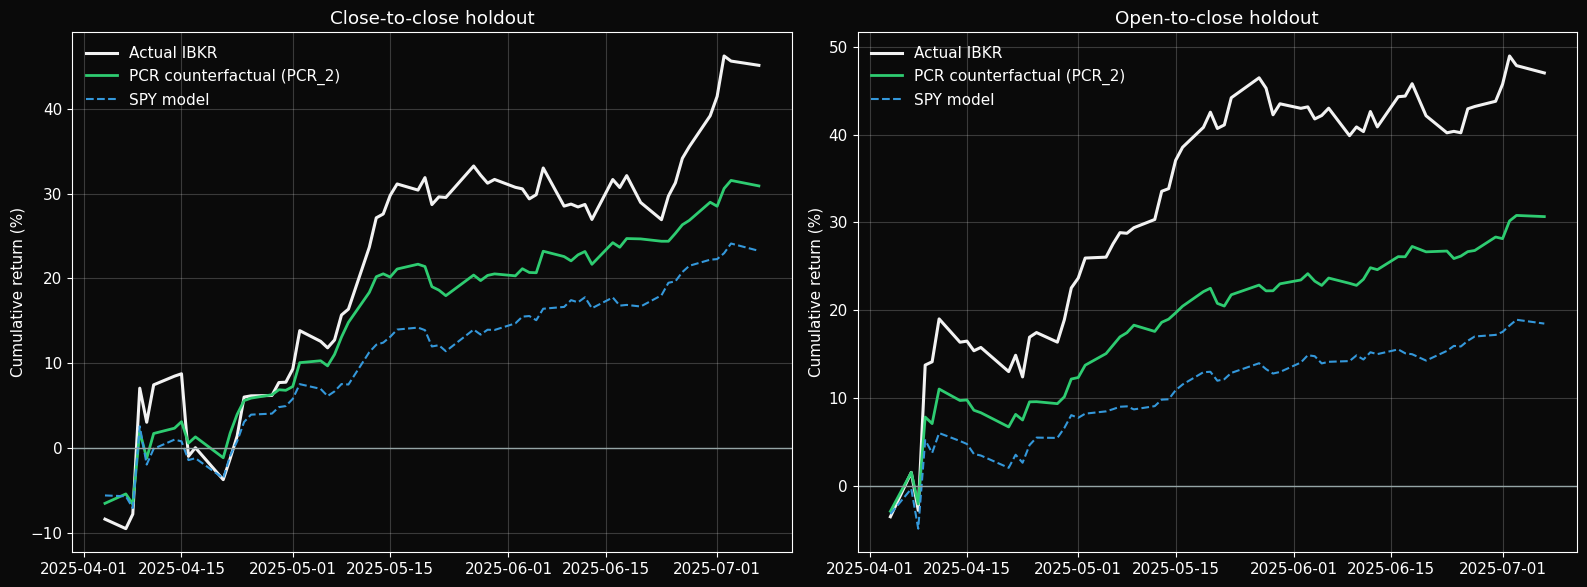

In [158]:
def bootstrap_rmse_intervals(
    prediction_frame,
    model_names,
    bootstrap_draws=BOOTSTRAP_DRAWS,
    random_seed=RANDOM_SEED,
):
    '''
    Moving-block bootstrap confidence intervals for holdout RMSE.
    '''
    sample_size = len(
        prediction_frame
    )

    block_length = max(
        2,
        int(np.ceil(sample_size ** (1 / 3))),
    )

    rng = np.random.default_rng(
        random_seed
    )

    bootstrap_indices = np.vstack([
        moving_block_indices(
            sample_size,
            block_length,
            rng,
        )
        for _ in range(bootstrap_draws)
    ])

    actual = prediction_frame[
        'actual'
    ].to_numpy()

    rows = []

    for model_name in model_names:
        prediction = prediction_frame[
            model_name
        ].to_numpy()

        errors = actual - prediction

        bootstrap_rmse = np.sqrt(
            np.mean(
                errors[bootstrap_indices] ** 2,
                axis=1,
            )
        )

        rows.append({
            'model': model_name,
            'rmse_ci_low': np.quantile(
                bootstrap_rmse,
                0.025,
            ),
            'rmse_ci_high': np.quantile(
                bootstrap_rmse,
                0.975,
            ),
        })

    intervals = (
        pd.DataFrame(rows)
        .set_index('model')
    )

    return intervals, block_length


def evaluate_holdout(
    data,
    development_result,
    random_seed,
):
    selected_k = development_result[
        'selection'
    ]['selected_component_count']

    selected_model = (
        f'PCR_{selected_k}'
    )

    holdout_dates = development_result[
        'design'
    ]['holdout'].index

    predictions = walk_forward_predictions(
        data,
        holdout_dates,
    )

    models = [
        'Historical mean',
        'SPY market model',
        'Equal-weight donor factor',
        selected_model,
    ]

    reduced_predictions = predictions[
        [
            'actual',
            *models,
        ]
    ].copy()

    scores = score_predictions(
        reduced_predictions
    )

    intervals, block_length = (
        bootstrap_rmse_intervals(
            reduced_predictions,
            models,
            random_seed=random_seed,
        )
    )

    scores = scores.join(
        intervals
    )

    return {
        'selected_k': selected_k,
        'selected_model': selected_model,
        'predictions': reduced_predictions,
        'scores': scores,
        'bootstrap_block_length': block_length,
    }


cc_holdout_result = evaluate_holdout(
    cc_model_data,
    cc_development_result,
    random_seed=RANDOM_SEED + 10,
)

oc_holdout_result = evaluate_holdout(
    oc_model_data,
    oc_development_result,
    random_seed=RANDOM_SEED + 11,
)


def format_holdout_table(result):
    table = result['scores'].copy()

    basis_point_columns = [
        'rmse',
        'mae',
        'rmse_ci_low',
        'rmse_ci_high',
    ]

    table[basis_point_columns] *= 10_000

    return table.rename(
        columns={
            'rmse': 'RMSE_bps',
            'mae': 'MAE_bps',
            'rmse_ci_low': 'RMSE_95%_low_bps',
            'rmse_ci_high': 'RMSE_95%_high_bps',
            'oos_r2_vs_mean': 'OOS_R2_vs_mean',
            'correlation': 'actual_predicted_correlation',
        }
    )


holdout_model_comparison = pd.concat(
    {
        'Close-to-close': format_holdout_table(
            cc_holdout_result
        ),
        'Open-to-close': format_holdout_table(
            oc_holdout_result
        ),
    },
    names=[
        'return_definition',
        'model',
    ],
)

display(
    holdout_model_comparison.round(4)
)


def cumulative_return_from_log_returns(log_returns):
    return (
        np.expm1(log_returns.cumsum())
        * 100
    )


fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
)

holdout_plot_inputs = [
    (
        axes[0],
        cc_holdout_result,
        'Close-to-close holdout',
    ),
    (
        axes[1],
        oc_holdout_result,
        'Open-to-close holdout',
    ),
]

for axis, result, title in holdout_plot_inputs:
    predictions = result['predictions']
    selected_model = result['selected_model']

    actual_cumulative = (
        cumulative_return_from_log_returns(
            predictions['actual']
        )
    )

    pcr_cumulative = (
        cumulative_return_from_log_returns(
            predictions[selected_model]
        )
    )

    spy_cumulative = (
        cumulative_return_from_log_returns(
            predictions['SPY market model']
        )
    )

    axis.plot(
        actual_cumulative.index,
        actual_cumulative,
        color='#f2f2f2',
        linewidth=2.2,
        label='Actual IBKR',
    )

    axis.plot(
        pcr_cumulative.index,
        pcr_cumulative,
        color='#2ecc71',
        linewidth=2,
        label=f'PCR counterfactual ({selected_model})',
    )

    axis.plot(
        spy_cumulative.index,
        spy_cumulative,
        color='#3498db',
        linewidth=1.5,
        linestyle='--',
        label='SPY model',
    )

    axis.axhline(
        0,
        color='#95a5a6',
        linewidth=1,
    )

    axis.set_title(title)
    axis.set_xlabel('')
    axis.set_ylabel('Cumulative return (%)')
    axis.legend(frameon=False)

plt.tight_layout()
plt.show()

## 8.5 PCA validation findings

The main specification is a two-component PCR model for both return definitions. In particular, the development procedure found that:

- 11 components produced the lowest close-to-close RMSE
- 9 components produced the lowest open-to-close RMSE
- most of the useful improvement was already obtained with 2 components

The one-standard-error rule therefore selected **$K=2$** in both cases. This is a useful result because the model does not need to fit almost every component to explain IBKR. On the contrary, the selected components explain approximately:

- **53.5%** of donor variation for close-to-close returns
- **53.1%** for open-to-close returns

The untouched holdout results are:

| Measure | Close-to-close PCR | Open-to-close PCR |
|---|---:|---:|
| RMSE | 171.4 bps | 122.1 bps |
| MAE | 116.5 bps | 87.0 bps |
| Out-of-sample $R^2$ | 0.712 | 0.789 |
| Actual-predicted correlation | 0.894 | 0.932 |

The positive out-of-sample $R^2$ values mean that PCR reduces prediction error substantially relative to using IBKR's historical average return. The high correlations also show that the model captures much of IBKR's ordinary daily movement. PCR clearly improves on the equal-weight donor factor for both return definitions.

The advantage over SPY is slightly more modest:

- for close-to-close returns, PCR improves RMSE by approximately **7.4 basis points**, but the confidence interval includes zero
- for open-to-close returns, PCR improves RMSE by approximately **9.9 basis points**, and the bootstrap interval is just above zero

Therefore, PCR adds information beyond a simple market model, particularly for intraday returns, but its close-to-close advantage over SPY is not estimated very precisely.

The residual audit is also satisfactory:

- the average residual confidence intervals contain zero
- the Ljung–Box p-values are **0.26** and **0.98**
- no clear residual persistence is detected

Overall, the earlier cutoff strengthens the research design because possible anticipation is excluded from model estimation. The model remains usable and the selected value of $K$ remains unchanged.

# 9. Estimating the event abnormal returns

The following analysis are performed:

1. auditing of the holdout residuals
2. freezing of the selected PCR models
3. estimating IBKR's counterfactual return
4. calculating abnormal returns across the registered phases
5. uncertainty estimation using historical out-of-sample errors

## 9.1 Residual audit

For each holdout session:

$$
e_t
=
r_{IBKR,t}
-
\widehat r_{IBKR,t}.
$$

The audit examines average residual bias, residual volatility, serial dependence and PCR's RMSE improvement over the simpler benchmarks. These tests measure normal model error before the possible anticipation period, but they do not use the event observations.

## 9.2 Frozen models

The selected number of components is fixed using the development data. The scaler, PCA transformation and regression are then re-estimated using all admissible observations through `MODEL_CUTOFF`. Two models are required:

- close-to-close PCR for complete daily returns
- open-to-close PCR for the first tradeable session

For a trade beginning at the first post-announcement open:

$$
r^{tradeable}_{0:H}
=
r^{OC}_0
+
\sum_{t=1}^{H}r^{CC}_t.
$$

## 9.3 The economic object being measured

IBKR was added to the S&P 500 and removed from the S&P MidCap 400 at the same time. [Official S&P announcement](https://www.spglobal.com/spdji/en/documents/indexnews/announcements/20250825-1479699/1479699_wba5-ppbi6.pdf). So, the relevant passive trade is:

$$
\text{net passive trade}
=
\text{S\&P 500 purchases}
-
\text{S\&P 400 sales}.
$$

The notebook cannot observe either leg directly, but it estimates the abnormal return associated with the complete migration.

The main estimands are:

- **primary total:** 25 August close to 27 August close
- **primary tradeable:** 26 August open to 27 August close

The 27 August close is considered the best daily-data proxy for the implementation trade because membership became effective before the following open, I treat it as an assumption.

## 9.4 Abnormal returns and uncertainty

For every return leg:

$$
AR_t
=
r_{IBKR,t}
-
\widehat r_{IBKR,t}.
$$

Cumulative abnormal log returns are:

$$
CAR_{a:b}
=
\sum_{t=a}^{b}AR_t,
$$

and the equivalent simple abnormal return is:

$$
A^{simple}_{a:b}
=
\exp(CAR_{a:b})-1.
$$

Historical holdout errors with the same return-leg structure provide the uncertainty distribution. This asks how unusual the observed residual is relative to errors made by the model during ordinary out-of-sample sessions. The long anticipation window has fewer historical blocks available than the short primary windows. Its interval will consequently be less reliable and should remain descriptive.

An interval excluding zero means that the return is unusual relative to the model's historical errors. It does not prove that passive funds caused it.

,observations,mean_residual_bps,mean_residual_95%_low_bps,mean_residual_95%_high_bps,mean_interval_contains_zero,residual_volatility_bps,ljung_box_lag,ljung_box_pvalue,bootstrap_block_length
return_definition,,,,,,,,,
Close-to-close,63,16.3760,-23.9837,62.7625,True,172.0045,10,0.2552,4
Open-to-close,63,18.7462,-6.6927,51.7180,True,121.6440,10,0.9817,4


PCR_RMSE_improvement_bps  \
return_definition benchmark                                             
Close-to-close    SPY market model                             7.3549   
                  Equal-weight donor factor                   59.4628   
Open-to-close     SPY market model                             9.9423   
                  Equal-weight donor factor                   47.9466   

                                             improvement_95%_low_bps  \
return_definition benchmark                                            
Close-to-close    SPY market model                           -9.7210   
                  Equal-weight donor factor                  21.8465   
Open-to-close     SPY market model                            0.2363   
                  Equal-weight donor factor                   7.2818   

                                             improvement_95%_high_bps  \
return_definition benchmark                                             
Close-to-close    SPY market model                            21.4272   
                  Equal-weight donor factor                  102.3745   
Open-to-close     SPY market model                            20.4426   
                  Equal-weight donor factor                   82.5852   

                                             interval_entirely_above_zero  \
return_definition benchmark                                                 
Close-to-close    SPY market model                                  False   
                  Equal-weight donor factor                          True   
Open-to-close     SPY market model                                   True   
                  Equal-weight donor factor                          True   

                                             bootstrap_fraction_PCR_better  
return_definition benchmark                                                 
Close-to-close    SPY market model                                  0.7875  
                  Equal-weight donor factor                         1.0000  
Open-to-close     SPY market model                                  0.9780  
                  Equal-weight donor factor                         0.9985

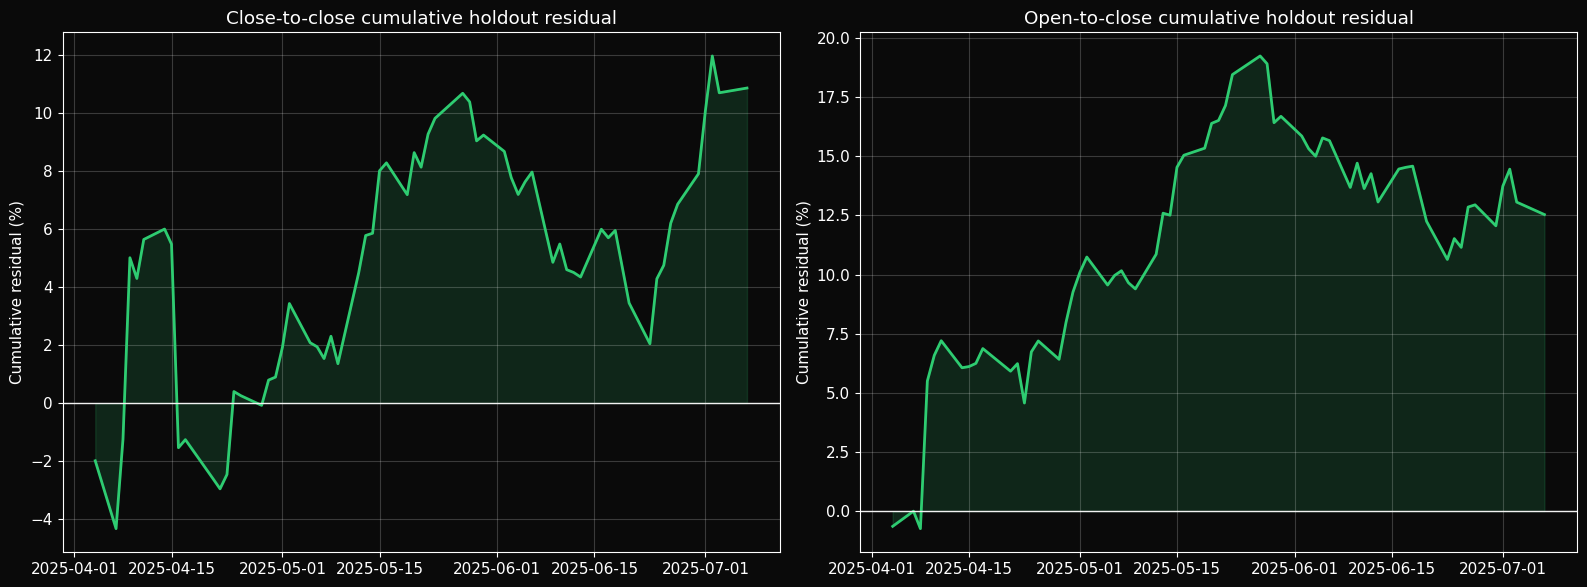

In [159]:
from statsmodels.stats.diagnostic import acorr_ljungbox


def selected_holdout_residuals(result):
    predictions = result['predictions']
    selected_model = result['selected_model']

    return (
        predictions['actual']
        - predictions[selected_model]
    ).rename('residual')


def bootstrap_index_matrix(
    sample_size,
    block_length,
    bootstrap_draws,
    random_seed,
):
    rng = np.random.default_rng(
        random_seed
    )

    return np.vstack([
        moving_block_indices(
            sample_size,
            block_length,
            rng,
        )
        for _ in range(bootstrap_draws)
    ])


def residual_diagnostics(
    result,
    return_definition,
    random_seed,
):
    residuals = selected_holdout_residuals(
        result
    )

    sample_size = len(residuals)

    block_length = max(
        2,
        int(np.ceil(sample_size ** (1 / 3))),
    )

    bootstrap_indices = bootstrap_index_matrix(
        sample_size,
        block_length,
        BOOTSTRAP_DRAWS,
        random_seed,
    )

    residual_array = residuals.to_numpy()

    bootstrap_mean_residuals = np.mean(
        residual_array[bootstrap_indices],
        axis=1,
    )

    ljung_box_lag = min(
        10,
        sample_size // 5,
    )

    ljung_box_result = acorr_ljungbox(
        residuals,
        lags=[ljung_box_lag],
        return_df=True,
    )

    mean_ci_low, mean_ci_high = np.quantile(
        bootstrap_mean_residuals,
        [0.025, 0.975],
    )

    return {
        'return_definition': return_definition,
        'observations': sample_size,
        'mean_residual_bps': residuals.mean() * 10_000,
        'mean_residual_95%_low_bps': mean_ci_low * 10_000,
        'mean_residual_95%_high_bps': mean_ci_high * 10_000,
        'mean_interval_contains_zero': (
            mean_ci_low <= 0 <= mean_ci_high
        ),
        'residual_volatility_bps': residuals.std() * 10_000,
        'ljung_box_lag': ljung_box_lag,
        'ljung_box_pvalue': (
            ljung_box_result['lb_pvalue'].iloc[0]
        ),
        'bootstrap_block_length': block_length,
    }


cc_residual_diagnostics = residual_diagnostics(
    cc_holdout_result,
    'Close-to-close',
    RANDOM_SEED + 20,
)

oc_residual_diagnostics = residual_diagnostics(
    oc_holdout_result,
    'Open-to-close',
    RANDOM_SEED + 21,
)

residual_diagnostic_table = (
    pd.DataFrame([
        cc_residual_diagnostics,
        oc_residual_diagnostics,
    ])
    .set_index('return_definition')
)

display(
    residual_diagnostic_table.round(4)
)


def paired_rmse_comparison(
    result,
    return_definition,
    random_seed,
):
    predictions = result['predictions']
    selected_model = result['selected_model']

    comparison_models = [
        'SPY market model',
        'Equal-weight donor factor',
    ]

    sample_size = len(predictions)

    block_length = max(
        2,
        int(np.ceil(sample_size ** (1 / 3))),
    )

    bootstrap_indices = bootstrap_index_matrix(
        sample_size,
        block_length,
        BOOTSTRAP_DRAWS,
        random_seed,
    )

    actual = predictions['actual'].to_numpy()

    pcr_errors = (
        actual
        - predictions[selected_model].to_numpy()
    )

    rows = []

    for benchmark in comparison_models:
        benchmark_errors = (
            actual
            - predictions[benchmark].to_numpy()
        )

        pcr_rmse_draws = np.sqrt(
            np.mean(
                pcr_errors[bootstrap_indices] ** 2,
                axis=1,
            )
        )

        benchmark_rmse_draws = np.sqrt(
            np.mean(
                benchmark_errors[bootstrap_indices] ** 2,
                axis=1,
            )
        )

        rmse_improvement_draws = (
            benchmark_rmse_draws
            - pcr_rmse_draws
        )

        observed_improvement = (
            np.sqrt(np.mean(benchmark_errors ** 2))
            - np.sqrt(np.mean(pcr_errors ** 2))
        )

        interval_low, interval_high = np.quantile(
            rmse_improvement_draws,
            [0.025, 0.975],
        )

        rows.append({
            'return_definition': return_definition,
            'benchmark': benchmark,
            'PCR_RMSE_improvement_bps':
                observed_improvement * 10_000,
            'improvement_95%_low_bps':
                interval_low * 10_000,
            'improvement_95%_high_bps':
                interval_high * 10_000,
            'interval_entirely_above_zero':
                interval_low > 0,
            'bootstrap_fraction_PCR_better':
                np.mean(rmse_improvement_draws > 0),
        })

    return pd.DataFrame(rows)


paired_comparison_table = pd.concat(
    [
        paired_rmse_comparison(
            cc_holdout_result,
            'Close-to-close',
            RANDOM_SEED + 30,
        ),
        paired_rmse_comparison(
            oc_holdout_result,
            'Open-to-close',
            RANDOM_SEED + 31,
        ),
    ],
    ignore_index=True,
).set_index([
    'return_definition',
    'benchmark',
])

display(
    paired_comparison_table.round(4)
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
)

residual_plot_inputs = [
    (
        axes[0],
        selected_holdout_residuals(
            cc_holdout_result
        ),
        'Close-to-close',
    ),
    (
        axes[1],
        selected_holdout_residuals(
            oc_holdout_result
        ),
        'Open-to-close',
    ),
]

for axis, residuals, title in residual_plot_inputs:
    cumulative_residual = (
        np.expm1(residuals.cumsum())
        * 100
    )

    axis.plot(
        cumulative_residual.index,
        cumulative_residual,
        color='#2ecc71',
        linewidth=2,
    )

    axis.fill_between(
        cumulative_residual.index,
        0,
        cumulative_residual,
        color='#2ecc71',
        alpha=0.15,
    )

    axis.axhline(
        0,
        color='#f2f2f2',
        linewidth=1,
    )

    axis.set_title(
        f'{title} cumulative holdout residual'
    )

    axis.set_xlabel('')
    axis.set_ylabel('Cumulative residual (%)')

plt.tight_layout()
plt.show()

,selected_K,variance_explained_by_selected_PCs,training_start,training_end,training_observations
Close-to-close,2,0.5351,2021-07-30,2025-07-07,987
Open-to-close,2,0.5312,2021-07-29,2025-07-07,988


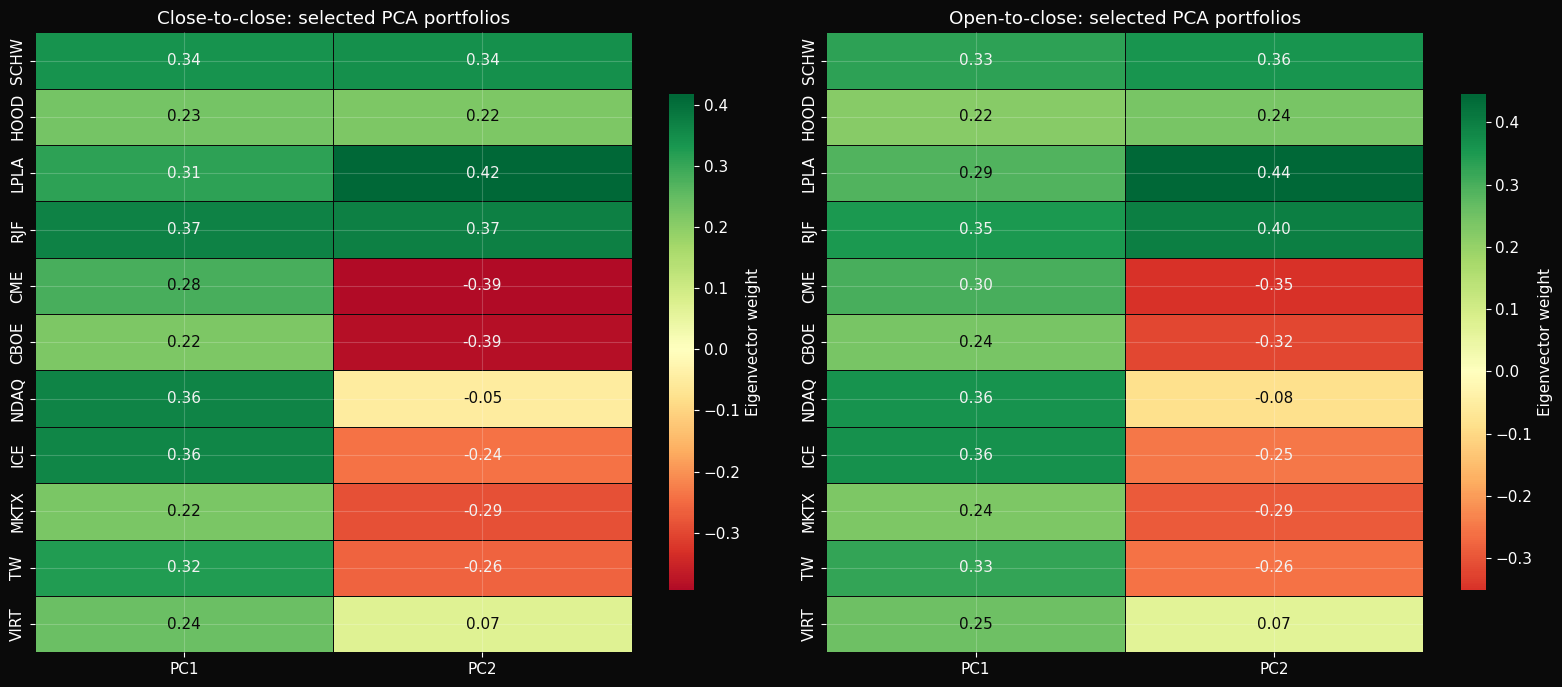

In [160]:
def fit_frozen_pcr_model(
    data,
    selected_k,
):
    '''
    Fit the final PCR model using all clean observations through t=-6.
    '''
    X = data[DONORS]
    y = data[TARGET]

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(
        X
    )

    pca = PCA(
        n_components=len(DONORS),
        svd_solver='full',
    )

    pca.fit(
        X_scaled
    )

    # PCA signs are arbitrary. Orient each component so that its
    # largest absolute donor weight is positive.
    dominant_positions = np.argmax(
        np.abs(pca.components_),
        axis=1,
    )

    orientation_signs = np.sign(
        pca.components_[
            np.arange(len(DONORS)),
            dominant_positions,
        ]
    )

    orientation_signs[
        orientation_signs == 0
    ] = 1

    pca.components_ = (
        pca.components_
        * orientation_signs[:, None]
    )

    component_scores = pca.transform(
        X_scaled
    )

    regression = LinearRegression()

    regression.fit(
        component_scores[:, :selected_k],
        y,
    )

    fitted_returns = regression.predict(
        component_scores[:, :selected_k]
    )

    residuals = pd.Series(
        y.to_numpy() - fitted_returns,
        index=data.index,
        name='training_residual',
    )

    component_names = [
        f'PC{number}'
        for number in range(
            1,
            len(DONORS) + 1,
        )
    ]

    component_weights = pd.DataFrame(
        pca.components_.T,
        index=DONORS,
        columns=component_names,
    )

    explained_variance = pd.DataFrame(
        {
            'explained_variance_ratio':
                pca.explained_variance_ratio_,
            'cumulative_explained_variance':
                np.cumsum(
                    pca.explained_variance_ratio_
                ),
        },
        index=component_names,
    )

    return {
        'target': TARGET,
        'donors': DONORS,
        'selected_k': selected_k,
        'training_start': data.index.min(),
        'training_end': data.index.max(),
        'scaler': scaler,
        'pca': pca,
        'regression': regression,
        'component_weights': component_weights,
        'explained_variance': explained_variance,
        'training_residuals': residuals,
    }


def predict_frozen_pcr_model(
    model,
    donor_returns,
):
    '''Apply a frozen PCR model to one or more donor-return rows.'''
    if isinstance(donor_returns, pd.Series):
        donor_frame = (
            donor_returns
            .reindex(model['donors'])
            .to_frame()
            .T
        )
    else:
        donor_frame = donor_returns[
            model['donors']
        ].copy()

    if donor_frame.isna().any().any():
        raise ValueError(
            'The donor-return input contains missing values.'
        )

    donor_scaled = model[
        'scaler'
    ].transform(
        donor_frame
    )

    component_scores = model[
        'pca'
    ].transform(
        donor_scaled
    )

    predictions = model[
        'regression'
    ].predict(
        component_scores[
            :,
            :model['selected_k'],
        ]
    )

    return pd.Series(
        predictions,
        index=donor_frame.index,
        name='expected_IBKR_return',
    )


frozen_cc_model = fit_frozen_pcr_model(
    cc_model_data,
    cc_holdout_result['selected_k'],
)

frozen_oc_model = fit_frozen_pcr_model(
    oc_model_data,
    oc_holdout_result['selected_k'],
)

frozen_models = {
    'close_to_close': frozen_cc_model,
    'open_to_close': frozen_oc_model,
}


def frozen_model_summary_row(model):
    selected_k = model['selected_k']

    return {
        'selected_K': selected_k,
        'variance_explained_by_selected_PCs': (
            model['explained_variance']
            ['explained_variance_ratio']
            .iloc[:selected_k]
            .sum()
        ),
        'training_start': model[
            'training_start'
        ].date(),
        'training_end': model[
            'training_end'
        ].date(),
        'training_observations': len(
            model['training_residuals']
        ),
    }


frozen_model_summary = pd.DataFrame(
    {
        'Close-to-close': frozen_model_summary_row(
            frozen_cc_model
        ),
        'Open-to-close': frozen_model_summary_row(
            frozen_oc_model
        ),
    }
).T

display(
    frozen_model_summary
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7),
)

loading_plot_inputs = [
    (
        axes[0],
        frozen_cc_model,
        'Close-to-close',
    ),
    (
        axes[1],
        frozen_oc_model,
        'Open-to-close',
    ),
]

for axis, model, title in loading_plot_inputs:
    selected_weights = (
        model['component_weights']
        .iloc[:, :model['selected_k']]
    )

    heatmap = sns.heatmap(
        selected_weights,
        cmap='RdYlGn',
        center=0,
        annot=True,
        fmt='.2f',
        linewidths=0.5,
        linecolor='#0a0a0a',
        ax=axis,
        cbar_kws={
            'label': 'Eigenvector weight',
            'shrink': 0.8,
        },
    )

    # Make the annotations readable on both light and dark cells.
    colour_mesh = heatmap.collections[0]

    for annotation in axis.texts:
        value = float(annotation.get_text())

        red, green, blue, _ = (
            colour_mesh.cmap(
                colour_mesh.norm(value)
            )
        )

        luminance = (
            0.2126 * red
            + 0.7152 * green
            + 0.0722 * blue
        )

        annotation.set_color(
            '#0a0a0a'
            if luminance > 0.58
            else '#f2f2f2'
        )

    axis.set_title(
        f'{title}: selected PCA portfolios'
    )

    axis.set_xlabel('')
    axis.set_ylabel('')

plt.tight_layout()
plt.show()

In [161]:
CORE_WINDOW_ORDER = [
    window.name
    for window in WINDOWS
]

window_lookup = {
    window.name: window
    for window in WINDOWS
}


def return_legs_for_window(window):
    '''
    Return (event time, return type) pairs for one event window.
    '''
    if window.scope in {
        'total',
        'close_to_close_diagnostic',
    }:
        return [
            (event_time, 'cc')
            for event_time in range(
                window.start_t,
                window.end_t + 1,
            )
        ]

    if window.scope == 'tradeable':
        if window.start_t != 0:
            raise ValueError(
                'Tradeable windows must begin at t=0.'
            )

        return [
            (0, 'oc'),
            *[
                (event_time, 'cc')
                for event_time in range(
                    1,
                    window.end_t + 1,
                )
            ],
        ]

    raise ValueError(
        f'Unsupported window scope: {window.scope}'
    )


first_analysis_t = min(
    window.start_t
    for window in WINDOWS
)

last_analysis_t = max(
    window.end_t
    for window in WINDOWS
)

analysis_event_times = list(
    range(
        first_analysis_t,
        last_analysis_t + 1,
    )
)

analysis_dates = [
    as_session_date(
        session_for_event_time(event_time)
    )
    for event_time in analysis_event_times
]

cc_event_data = (
    cc_log_returns
    .reindex(analysis_dates)[
        [TARGET, *DONORS]
    ]
)

oc_event_data = (
    oc_log_returns
    .reindex(analysis_dates)[
        [TARGET, *DONORS]
    ]
)

if cc_event_data.isna().any().any():
    raise ValueError(
        'Missing close-to-close event data.'
    )

if oc_event_data.isna().any().any():
    raise ValueError(
        'Missing open-to-close event data.'
    )


expected_cc_returns = (
    predict_frozen_pcr_model(
        frozen_cc_model,
        cc_event_data[DONORS],
    )
)

expected_oc_returns = (
    predict_frozen_pcr_model(
        frozen_oc_model,
        oc_event_data[DONORS],
    )
)

phase_lookup = (
    event_calendar
    .set_index('event_time')['phase']
)

daily_rows = []

for event_time, date in zip(
    analysis_event_times,
    analysis_dates,
):
    actual_cc = float(
        cc_event_data.loc[
            date,
            TARGET,
        ]
    )

    expected_cc = float(
        expected_cc_returns.loc[date]
    )

    actual_oc = float(
        oc_event_data.loc[
            date,
            TARGET,
        ]
    )

    expected_oc = float(
        expected_oc_returns.loc[date]
    )

    daily_rows.append(
        {
            'event_time': event_time,
            'date': date,
            'phase': phase_lookup.loc[
                event_time
            ],
            'actual_cc_log': actual_cc,
            'expected_cc_log': expected_cc,
            'abnormal_cc_log':
                actual_cc - expected_cc,
            'actual_oc_log': actual_oc,
            'expected_oc_log': expected_oc,
            'abnormal_oc_log':
                actual_oc - expected_oc,
        }
    )


daily_event_counterfactual = (
    pd.DataFrame(daily_rows)
    .set_index('event_time')
)

daily_event_display = (
    daily_event_counterfactual.copy()
)

percentage_columns = [
    column
    for column in daily_event_display.columns
    if column.endswith('_log')
]

daily_event_display[
    percentage_columns
] *= 100

daily_event_display = (
    daily_event_display.rename(
        columns={
            column:
                column.replace(
                    '_log',
                    '_pct',
                )
            for column
            in percentage_columns
        }
    )
)

display(
    daily_event_display.loc[
        -5:POST_IMPLEMENTATION_END_T
    ].round(4)
)


window_rows = []

for window_name in CORE_WINDOW_ORDER:
    window = window_lookup[
        window_name
    ]

    legs = return_legs_for_window(
        window
    )

    actual_log_return = 0.0
    expected_log_return = 0.0

    for event_time, return_type in legs:
        actual_log_return += float(
            daily_event_counterfactual.loc[
                event_time,
                f'actual_{return_type}_log',
            ]
        )

        expected_log_return += float(
            daily_event_counterfactual.loc[
                event_time,
                f'expected_{return_type}_log',
            ]
        )

    abnormal_log_return = (
        actual_log_return
        - expected_log_return
    )

    window_rows.append(
        {
            'window': window.name,
            'role': window.role,
            'scope': window.scope,
            'start_t': window.start_t,
            'end_t': window.end_t,
            'number_of_legs': len(legs),
            'return_leg_sequence':
                ' + '.join(
                    return_type.upper()
                    for _, return_type
                    in legs
                ),
            'actual_log_return':
                actual_log_return,
            'expected_log_return':
                expected_log_return,
            'abnormal_log_return':
                abnormal_log_return,
            'actual_return_pct':
                np.expm1(
                    actual_log_return
                ) * 100,
            'expected_return_pct':
                np.expm1(
                    expected_log_return
                ) * 100,
            'abnormal_return_pct':
                np.expm1(
                    abnormal_log_return
                ) * 100,
        }
    )


event_window_results = (
    pd.DataFrame(window_rows)
    .set_index('window')
)

display(
    event_window_results[
        [
            'role',
            'start_t',
            'end_t',
            'return_leg_sequence',
            'actual_return_pct',
            'expected_return_pct',
            'abnormal_return_pct',
        ]
    ].round(4)
)

,date,phase,actual_cc_pct,expected_cc_pct,abnormal_cc_pct,actual_oc_pct,expected_oc_pct,abnormal_oc_pct
event_time,,,,,,,,
-5,2025-08-19,possible anticipation,-1.9517,-0.8339,-1.1177,-2.1714,-0.6784,-1.4930
-4,2025-08-20,possible anticipation,0.0801,-0.1307,0.2108,0.5136,0.0497,0.4639
-3,2025-08-21,possible anticipation,0.0160,0.4732,-0.4572,0.1442,0.5296,-0.3854
-2,2025-08-22,possible anticipation,-0.1121,1.2093,-1.3214,-0.3200,0.8834,-1.2034
-1,2025-08-25,last close before announcement,0.5753,-0.1437,0.7189,0.5913,-0.1491,0.7404
0,2025-08-26,announcement reaction,0.8567,1.4911,-0.6343,-1.8780,1.4620,-3.3400
1,2025-08-27,implementation-session proxy,-2.4144,-0.3669,-2.0474,-1.2704,-0.2869,-0.9835
2,2025-08-28,first effective session,1.5895,0.3644,1.2251,0.4790,-0.0029,0.4819
3,2025-08-29,post-implementation,-0.7363,-0.2579,-0.4785,-0.3849,-0.2012,-0.1837


,role,start_t,end_t,return_leg_sequence,actual_return_pct,expected_return_pct,abnormal_return_pct
window,,,,,,,
primary_total,primary,0,1,CC + CC,-1.5456,1.1305,-2.6461
primary_tradeable,primary,0,1,OC + CC,-4.2015,1.1011,-5.2449
announcement_reaction_total,secondary,0,0,CC,0.8604,1.5022,-0.6323
announcement_reaction_tradeable,secondary,0,0,OC,-1.8605,1.4728,-3.2848
implementation_session,secondary,1,1,CC,-2.3855,-0.3663,-2.0266
possible_anticipation,diagnostic,-35,-1,CC + CC + CC + CC + CC + CC + CC + CC + CC + C...,8.6189,4.4167,4.0244
post_implementation_5d,diagnostic,2,6,CC + CC + CC + CC + CC,4.1625,0.2550,3.8976
post_implementation_10d,diagnostic,2,11,CC + CC + CC + CC + CC + CC + CC + CC + CC + CC,2.6393,-0.7319,3.3960


,role,raw_abnormal_return_pct,bootstrap_median_effect_pct,effect_95%_low_pct,effect_95%_high_pct,effect_interval_excludes_zero,normal_error_95%_low_pct,normal_error_95%_high_pct,available_historical_blocks,bootstrap_draws
window,,,,,,,,,,
primary_total,primary,-2.6461,-2.9909,-7.8274,4.0035,False,-5.3171,4.9582,62,2000
primary_tradeable,primary,-5.2449,-5.9291,-10.2358,-1.9459,True,-3.1811,4.6773,62,2000
announcement_reaction_total,secondary,-0.6323,-0.8149,-3.7319,2.3185,False,-2.6120,3.1525,63,2000
announcement_reaction_tradeable,secondary,-3.2848,-3.4609,-5.2435,-1.2764,True,-1.8565,1.9189,63,2000
implementation_session,secondary,-2.0266,-2.2067,-5.0827,0.8828,False,-2.6120,3.1525,63,2000
possible_anticipation,diagnostic,4.0244,-1.0433,-9.8487,3.9053,False,0.6114,13.6659,29,2000
post_implementation_5d,diagnostic,3.8976,2.7269,-3.6111,12.7080,False,-7.6892,7.3853,59,2000
post_implementation_10d,diagnostic,3.3960,2.2287,-3.5213,9.3179,False,-5.3606,7.0539,54,2000


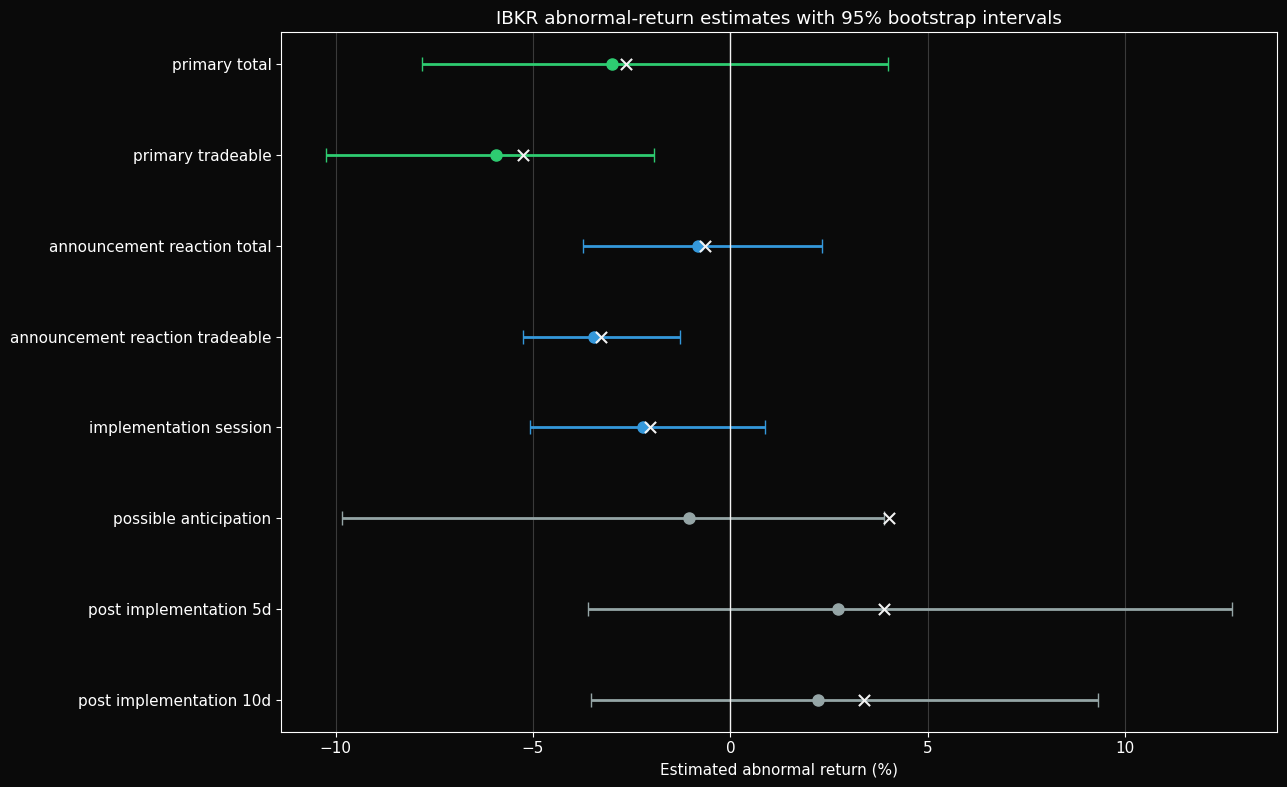

In [162]:
cc_holdout_residuals = (
    cc_holdout_result['predictions']['actual']
    - cc_holdout_result['predictions'][
        cc_holdout_result['selected_model']
    ]
)

oc_holdout_residuals = (
    oc_holdout_result['predictions']['actual']
    - oc_holdout_result['predictions'][
        oc_holdout_result['selected_model']
    ]
)

historical_holdout_residuals = pd.concat(
    {
        'cc': cc_holdout_residuals,
        'oc': oc_holdout_residuals,
    },
    axis=1,
    join='inner',
).dropna()


def historical_window_error_sums(
    residual_frame,
    return_leg_sequence,
):
    '''
    Build overlapping historical errors with the same CC/OC
    sequence as an event window.
    '''
    horizon = len(
        return_leg_sequence
    )

    number_of_windows = (
        len(residual_frame)
        - horizon
        + 1
    )

    if number_of_windows <= 0:
        raise ValueError(
            'The residual history is shorter than the event window.'
        )

    error_sums = []

    for start_position in range(
        number_of_windows
    ):
        cumulative_error = 0.0

        for offset, return_type in enumerate(
            return_leg_sequence
        ):
            cumulative_error += (
                residual_frame
                .iloc[start_position + offset][
                    return_type
                ]
            )

        error_sums.append(
            cumulative_error
        )

    return np.asarray(
        error_sums
    )


bootstrap_rng = np.random.default_rng(
    RANDOM_SEED + 100
)

uncertainty_rows = []

event_effect_draws_log = {}
event_effect_draws_simple = {}


for window_name in CORE_WINDOW_ORDER:
    window = window_lookup[
        window_name
    ]

    legs = return_legs_for_window(
        window
    )

    return_leg_sequence = [
        return_type
        for _, return_type in legs
    ]

    historical_errors = (
        historical_window_error_sums(
            historical_holdout_residuals,
            return_leg_sequence,
        )
    )

    sampled_normal_errors = bootstrap_rng.choice(
        historical_errors,
        size=BOOTSTRAP_DRAWS,
        replace=True,
    )

    observed_abnormal_log = (
        event_window_results.loc[
            window_name,
            'abnormal_log_return',
        ]
    )

    effect_draws_log = (
        observed_abnormal_log
        - sampled_normal_errors
    )

    effect_draws_simple = np.expm1(
        effect_draws_log
    )

    event_effect_draws_log[
        window_name
    ] = pd.Series(
        effect_draws_log,
        name=window_name,
    )

    event_effect_draws_simple[
        window_name
    ] = pd.Series(
        effect_draws_simple,
        name=window_name,
    )

    effect_low, effect_median, effect_high = (
        np.quantile(
            effect_draws_simple,
            [0.025, 0.50, 0.975],
        )
        * 100
    )

    normal_error_low, normal_error_high = (
        np.expm1(
            np.quantile(
                historical_errors,
                [0.025, 0.975],
            )
        )
        * 100
    )

    uncertainty_rows.append({
        'window': window_name,
        'role': window.role,
        'raw_abnormal_return_pct':
            event_window_results.loc[
                window_name,
                'abnormal_return_pct',
            ],
        'bootstrap_median_effect_pct':
            effect_median,
        'effect_95%_low_pct':
            effect_low,
        'effect_95%_high_pct':
            effect_high,
        'effect_interval_excludes_zero':
            not (
                effect_low <= 0 <= effect_high
            ),
        'normal_error_95%_low_pct':
            normal_error_low,
        'normal_error_95%_high_pct':
            normal_error_high,
        'available_historical_blocks':
            len(historical_errors),
        'bootstrap_draws':
            BOOTSTRAP_DRAWS,
    })


event_uncertainty_results = (
    pd.DataFrame(uncertainty_rows)
    .set_index('window')
)

display(
    event_uncertainty_results.round(4)
)


plot_table = event_uncertainty_results.loc[
    CORE_WINDOW_ORDER
].copy()

y_positions = np.arange(
    len(plot_table)
)

role_colours = {
    'primary': '#2ecc71',
    'secondary': '#3498db',
    'diagnostic': '#95a5a6',
}

fig, ax = plt.subplots(
    figsize=(13, 8)
)

for position, (window_name, row) in enumerate(
    plot_table.iterrows()
):
    median = row[
        'bootstrap_median_effect_pct'
    ]

    lower_error = (
        median
        - row['effect_95%_low_pct']
    )

    upper_error = (
        row['effect_95%_high_pct']
        - median
    )

    colour = role_colours[
        row['role']
    ]

    ax.errorbar(
        median,
        position,
        xerr=np.array([
            [lower_error],
            [upper_error],
        ]),
        fmt='o',
        color=colour,
        ecolor=colour,
        elinewidth=2,
        capsize=5,
        markersize=8,
    )

    ax.scatter(
        row['raw_abnormal_return_pct'],
        position,
        marker='x',
        color='#f2f2f2',
        s=65,
        zorder=3,
    )

ax.axvline(
    0,
    color='#f2f2f2',
    linewidth=1,
)

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    [
        window_name.replace('_', ' ')
        for window_name in plot_table.index
    ]
)

ax.invert_yaxis()

ax.set_title(
    'IBKR abnormal-return estimates with 95% bootstrap intervals'
)

ax.set_xlabel(
    'Estimated abnormal return (%)'
)

ax.set_ylabel('')

ax.grid(
    axis='x',
    alpha=0.2,
)

ax.grid(
    axis='y',
    visible=False,
)

plt.tight_layout()
plt.show()

## 9.5 Findings

The analysed timeline considers the main endpoint from the close on 28 August to the close on 27 August. This is the last close before IBKR's new index membership became effective.

The event results are:

| Window | Raw abnormal return | Bootstrap median | 95% interval |
|---|---:|---:|---:|
| Announcement reaction: total | −0.63% | −0.81% | −3.73% to +2.32% |
| Announcement reaction: tradeable | −3.28% | −3.46% | −5.24% to −1.28% |
| Primary total | −2.65% | −2.99% | −7.83% to +4.00% |
| Primary tradeable | −5.24% | −5.93% | −10.24% to −1.95% |
| Implementation session | −2.03% | −2.21% | −5.08% to +0.88% |
| Possible anticipation | +4.02% | −1.04% | −9.85% to +3.91% |
| Five post-implementation sessions | +3.90% | +2.73% | −3.61% to +12.71% |
| Ten post-implementation sessions | +3.40% | +2.23% | −3.52% to +9.32% |

The raw abnormal return and bootstrap median can differ because the bootstrap corrects the event residual using the model errors observed in the holdout. This difference is particularly large for the 35-session anticipation period, where small daily model biases accumulate over time.

### Announcement reaction

IBKR's total first-session abnormal return is small and its interval contains zero. However, the return available after the 26 August open is approximately **−3.28%**, with a pointwise interval below zero. Interestingly, the difference between the total and tradeable results implies a positive abnormal overnight gap of approximately **2.7%**, followed by a negative intraday reversal.

This means that the favourable reaction appeared mainly before regular trading began and an investor buying at the first post-announcement open would not have captured that overnight increase.

### Announcement through implementation

From the pre-announcement close through the 27 August close, the raw abnormal return is approximately **−2.65%**. Its interval contains zero, so the total price reaction is not estimated precisely.

From the 26 August open through the 27 August close, the tradeable abnormal return is approximately **−5.24%**. Its pointwise 95% interval remains below zero.

The implementation session itself produced an abnormal return of approximately **−2.03%**, but its individual interval contains zero. The evidence is therefore stronger when the two tradeable sessions are considered together.

### Anticipation and post-implementation returns

IBKR's raw cumulative abnormal return during the possible-anticipation period is approximately **+4.02%**. However, the uncertainty interval is very wide and contains zero. Only 29 historical residual windows of the same length are available. There is therefore no reliable statistical evidence of pre-announcement anticipation, even though public discussion made anticipation economically possible.

The five- and ten-session post-implementation abnormal returns are positive, but both intervals are wide and contain zero. We cannot conclude that the earlier decline permanently reversed or that passive buying continued after implementation.

### Economic interpretation

IBKR was simultaneously:

- added to the S&P 500
- removed from the S&P MidCap 400

The result therefore concerns the **net index migration**:

$$
\text{net passive trade}
=
\text{S\&P 500 buying}
-
\text{S\&P 400 selling}.
$$

The negative tradeable abnormal return is compatible with a weak or negative net migration effect. Greenwood and Sammon find that the traditional S&P 500 addition effect has become much smaller and that recent migrations from the S&P 400 can experience slight net selling pressure. [Greenwood and Sammon, “The Disappearing Index Effect”](https://www.nber.org/papers/w30748)

Their paper provides useful external support for this interpretation, but, naturally, it does not prove that passive trading caused IBKR's return.

Overall, I can conclude:

> The total announcement-to-implementation return is not clearly abnormal: the return available after the first post-announcement open is unusually negative relative to the PCA counterfactual. This is a net migration-related residual, not a separately identified ETF effect.

# 10. Timing, robustness and identification limits

Before concluding the research design, there are still three questions worth considering for the event-study:

1. When did the abnormal return and unusual trading volume appear?
2. Does the main estimate survive reasonable changes to the model?
3. How strongly can the result be attributed to passive trading?

## 10.1 Return and volume timing

I plot IBKR's cumulative abnormal return from the first public candidate signal through ten post-implementation sessions. I also compare IBKR's daily volume with its trailing 63-session median and with the median relative volume of the extended clean donor set.

Volume can show when unusual trading activity occurred, but Yahoo reports total volume rather than the identity of the buyer. A volume spike at the implementation close would be consistent with index-related activity, but would not prove that every trade came from passive buying. The daily data also cannot isolate the closing auction. The complete return and volume on 27 August are only proxies for activity around the final close before effectiveness.

## 10.2 Statistical robustness

The primary results obtained are subjected to three checks.

### Historical residual placebos

The event residual is compared with residual windows of the same length from the untouched holdout. This asks whether similarly large model errors occurred during ordinary periods. Because four related primary and announcement windows are tested, the raw empirical p-values are adjusted using Holm's procedure. This prevents from declaring a result convincing merely because one of several overlapping windows produced a favourable number.

Bonferroni-adjusted confidence intervals are also reported. They are conservative but control the probability that the family of intervals jointly misses the true values.

### Leave-one-donor-out analysis

The counterfactual is estimated after removing one donor at a time. If the main result changes sign after removing a single stock, it is dependent on that donor and is not robust. If the sign and approximate magnitude remain stable, no individual donor is driving the result.

### Winsorized-model sensitivity

The primary model retains raw returns because extreme observations may contain genuine information. However, as a sensitivity test, the training target and donor returns are capped at their pre-event 1st and 99th percentiles, while event-period IBKR returns are never capped. Event donor inputs are capped using only the bounds learned from the training sample.

## 10.3 Literature contribution

Greenwood and Sammon document that the traditional S&P 500 addition effect has become much smaller over time. They also find that recent stocks migrating from the S&P MidCap 400 to the S&P 500 may experience slight net selling pressure from index funds. [Greenwood and Sammon, “The Disappearing Index Effect”](https://www.nber.org/papers/w30748)

This evidence is directly relevant because IBKR was a migration:

$$
\text{net passive trade}
=
\text{S\&P 500 buying}
-
\text{S\&P 400 selling}.
$$

The paper provides **external validation** for why a small or negative IBKR response is not economically possible, but also plausible. It does not provide statistical robustness for the particular IBKR estimate.

## 10.4 Identification boundary

The observed abnormal return can be written as:

$$
AR_t
=
\text{net passive demand}
+
\text{anticipation and arbitrage}
+
\text{IBKR-specific information}
+
\text{model error}.
$$

Prices and total volume do not provide enough separate information to solve for all four terms.

,date,IBKR_volume_multiple,donor_median_volume_multiple,abnormal_volume_score
event_time,,,,
-5,2025-08-19,0.834,1.010,-0.435
-4,2025-08-20,1.227,1.131,0.206
-3,2025-08-21,0.575,0.744,-0.597
-2,2025-08-22,0.848,0.970,-0.304
-1,2025-08-25,1.131,0.784,0.879
0,2025-08-26,2.702,1.029,2.297
1,2025-08-27,21.706,0.805,7.836
2,2025-08-28,1.764,0.708,2.174
3,2025-08-29,1.301,0.727,1.439


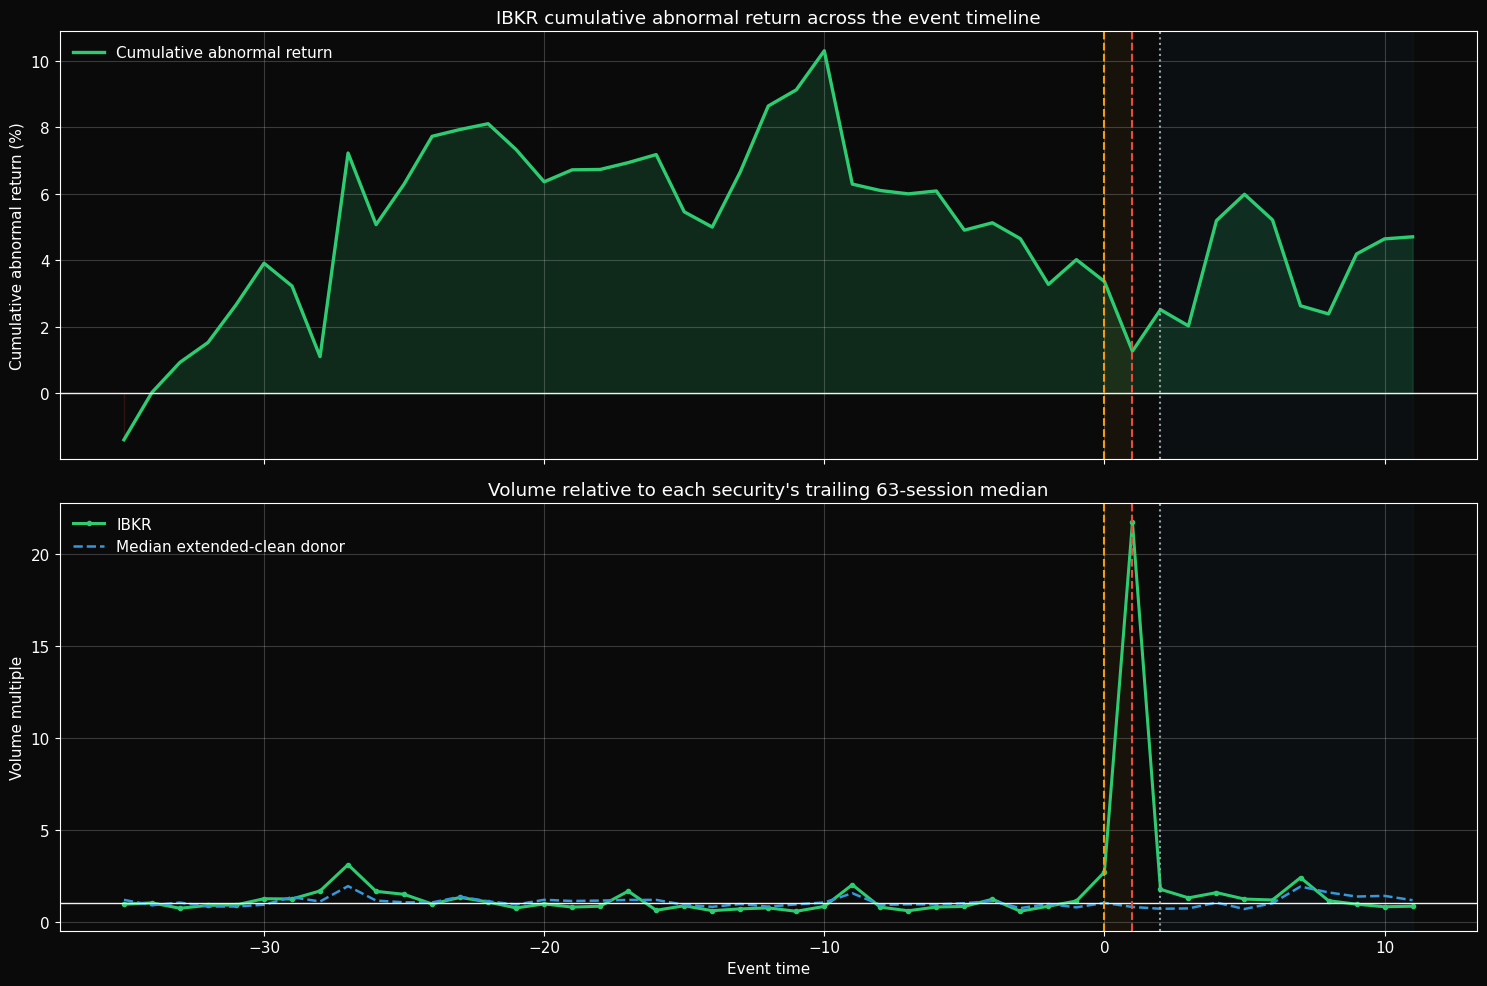

In [163]:
event_path = (
    daily_event_counterfactual
    .loc[
        ANTICIPATION_START_T:
        POST_IMPLEMENTATION_END_T
    ]
    .copy()
)

event_path['cumulative_abnormal_pct'] = (
    np.expm1(
        event_path[
            'abnormal_cc_log'
        ].cumsum()
    )
    * 100
)


# Relative volume is measured against a trailing baseline
# that uses only earlier observations.
VOLUME_BASELINE_SESSIONS = 63
VOLUME_DONORS = list(
    EXTENDED_CLEAN_DONORS
)

volume_columns = [
    TARGET,
    *VOLUME_DONORS,
]

volume_history = (
    volumes[volume_columns]
    .astype(float)
    .copy()
)

volume_history.index = (
    pd.to_datetime(
        volume_history.index
    )
    .tz_localize(None)
    .normalize()
)

trailing_volume_median = (
    volume_history
    .shift(1)
    .rolling(
        VOLUME_BASELINE_SESSIONS,
        min_periods=VOLUME_BASELINE_SESSIONS,
    )
    .median()
)

relative_volume = (
    volume_history
    / trailing_volume_median
)

log_relative_volume = np.log(
    relative_volume.replace(
        0,
        np.nan,
    )
)

donor_median_log_relative_volume = (
    log_relative_volume[
        VOLUME_DONORS
    ]
    .median(axis=1)
)

ibkr_abnormal_log_volume = (
    log_relative_volume[TARGET]
    - donor_median_log_relative_volume
)

# Robust historical location and scale.
historical_abnormal_volume = (
    ibkr_abnormal_log_volume
    .loc[:MODEL_CUTOFF]
    .dropna()
)

historical_volume_location = (
    historical_abnormal_volume.median()
)

historical_volume_mad = (
    (
        historical_abnormal_volume
        - historical_volume_location
    )
    .abs()
    .median()
)

historical_volume_scale = (
    1.4826
    * historical_volume_mad
)

if historical_volume_scale <= 0:
    raise ValueError(
        'Historical abnormal-volume scale is zero.'
    )

event_dates_index = pd.DatetimeIndex(
    event_path['date']
)

volume_path = pd.DataFrame(
    {
        'date': event_dates_index,
        'IBKR_volume_multiple': (
            relative_volume[TARGET]
            .reindex(event_dates_index)
            .to_numpy()
        ),
        'donor_median_volume_multiple': (
            relative_volume[
                VOLUME_DONORS
            ]
            .median(axis=1)
            .reindex(event_dates_index)
            .to_numpy()
        ),
        'abnormal_volume_score': (
            (
                ibkr_abnormal_log_volume
                - historical_volume_location
            )
            / historical_volume_scale
        )
        .reindex(event_dates_index)
        .to_numpy(),
    },
    index=event_path.index,
)


display(
    volume_path.loc[
        -5:
        POST_IMPLEMENTATION_END_T
    ].round(3)
)


fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 10),
    sharex=True,
)

x_values = (
    event_path.index.to_numpy()
)

cumulative_abnormal = (
    event_path[
        'cumulative_abnormal_pct'
    ].to_numpy()
)

axes[0].plot(
    x_values,
    cumulative_abnormal,
    color='#2ecc71',
    linewidth=2.4,
    label='Cumulative abnormal return',
)

axes[0].fill_between(
    x_values,
    0,
    cumulative_abnormal,
    where=cumulative_abnormal >= 0,
    color='#2ecc71',
    alpha=0.16,
)

axes[0].fill_between(
    x_values,
    0,
    cumulative_abnormal,
    where=cumulative_abnormal < 0,
    color='#e74c3c',
    alpha=0.16,
)

axes[0].axhline(
    0,
    color='#f2f2f2',
    linewidth=1,
)

axes[0].set_title(
    'IBKR cumulative abnormal return across the event timeline'
)

axes[0].set_ylabel(
    'Cumulative abnormal return (%)'
)

axes[0].legend(
    frameon=False
)


axes[1].plot(
    volume_path.index,
    volume_path[
        'IBKR_volume_multiple'
    ],
    color='#2ecc71',
    linewidth=2.2,
    marker='o',
    markersize=3,
    label='IBKR',
)

axes[1].plot(
    volume_path.index,
    volume_path[
        'donor_median_volume_multiple'
    ],
    color='#3498db',
    linewidth=1.8,
    linestyle='--',
    label='Median extended-clean donor',
)

axes[1].axhline(
    1,
    color='#f2f2f2',
    linewidth=1,
)

axes[1].set_title(
    'Volume relative to each security\'s trailing 63-session median'
)

axes[1].set_xlabel(
    'Event time'
)

axes[1].set_ylabel(
    'Volume multiple'
)

axes[1].legend(
    frameon=False
)


for axis in axes:
    axis.axvline(
        0,
        color='#f39c12',
        linestyle='--',
        linewidth=1.5,
        label='Announcement reaction',
    )

    axis.axvline(
        IMPLEMENTATION_CLOSE_T,
        color='#e74c3c',
        linestyle='--',
        linewidth=1.5,
        label='Implementation-close proxy',
    )

    axis.axvline(
        EFFECTIVE_T,
        color='#95a5a6',
        linestyle=':',
        linewidth=1.5,
        label='First effective session',
    )

    axis.axvspan(
        0,
        IMPLEMENTATION_CLOSE_T,
        color='#f39c12',
        alpha=0.06,
    )

    axis.axvspan(
        EFFECTIVE_T,
        POST_IMPLEMENTATION_END_T,
        color='#3498db',
        alpha=0.04,
    )

plt.tight_layout()
plt.show()

## 10.5 Timing and volume findings

Trading volume is strongly concentrated around the implementation date.

| Event time | Date | IBKR volume relative to baseline | Donor median | Abnormal-volume score |
|---:|---|---:|---:|---:|
| $t=0$ | 26 August | 2.70× | 1.03× | 2.30 |
| $t=1$ | 27 August | 21.71× | 0.81× | 7.84 |
| $t=2$ | 28 August | 1.76× | 0.71× | 2.17 |
| $t=3$ | 29 August | 1.30× | 0.73× | 1.44 |

The most important result is on 27 August. IBKR traded approximately **21.7 times** its trailing 63-session median volume, while the median extended-clean donor traded at only **0.81 times** its own baseline. The abnormal volume score of **7.84** shows that the difference is extremely large relative to IBKR's historical volume behaviour and the same day donor activity.

Volume was also elevated on 26 and 28 August, but neither session was as large as 27 August, activity then generally moved back toward normal levels. On 5 September, IBKR volume rose to approximately **2.4 times** its baseline. However, donor volume was also high at approximately **1.9 times** baseline. Its abnormal-volume score was only **0.58**, so this later increase was not especially specific to IBKR.

This timing is strongly consistent with index-related trading being concentrated around the final close before effectiveness. It provides little support for the idea that the main implementation trade was delayed by more than five sessions.

However, the dataset reports total volume. It cannot identify whether individual trades came from:

- S&P 500 funds buying
- S&P 400 funds selling
- arbitrageurs trading ahead of those funds
- active investors
- other market participants

The volume evidence therefore strengthens the timing interpretation, but it does not identify the trader or the direction of net passive demand.

In [164]:
from statsmodels.stats.multitest import (
    multipletests
)


# These windows form the inferential family.
# The longer anticipation and post-event windows remain diagnostic.
INFERENCE_WINDOW_ORDER = [
    'announcement_reaction_total',
    'announcement_reaction_tradeable',
    'primary_total',
    'primary_tradeable',
]

FAMILY_ALPHA = 0.05
family_size = len(
    INFERENCE_WINDOW_ORDER
)

# Bonferroni quantiles provide 95% family-wise coverage.
lower_quantile = (
    FAMILY_ALPHA
    / (2 * family_size)
)

upper_quantile = (
    1
    - lower_quantile
)

inference_rows = []

for window_name in INFERENCE_WINDOW_ORDER:
    window = window_lookup[
        window_name
    ]

    legs = return_legs_for_window(
        window
    )

    return_leg_sequence = [
        return_type
        for _, return_type in legs
    ]

    historical_errors = (
        historical_window_error_sums(
            historical_holdout_residuals,
            return_leg_sequence,
        )
    )

    observed_abnormal_log = float(
        event_window_results.loc[
            window_name,
            'abnormal_log_return',
        ]
    )

    historical_center = np.median(
        historical_errors
    )

    centred_historical_errors = (
        historical_errors
        - historical_center
    )

    centred_event_error = (
        observed_abnormal_log
        - historical_center
    )

    # Finite-sample empirical two-sided placebo p-value.
    empirical_p_value = (
        1
        + np.sum(
            np.abs(
                centred_historical_errors
            )
            >= abs(
                centred_event_error
            )
        )
    ) / (
        len(historical_errors)
        + 1
    )

    effect_draws_pct = (
        event_effect_draws_simple[
            window_name
        ].to_numpy()
        * 100
    )

    familywise_low, familywise_high = (
        np.quantile(
            effect_draws_pct,
            [
                lower_quantile,
                upper_quantile,
            ],
        )
    )

    inference_rows.append(
        {
            'window': window_name,
            'raw_abnormal_return_pct':
                event_window_results.loc[
                    window_name,
                    'abnormal_return_pct',
                ],
            'familywise_95%_low_pct':
                familywise_low,
            'familywise_95%_high_pct':
                familywise_high,
            'familywise_interval_excludes_zero':
                not (
                    familywise_low
                    <= 0
                    <= familywise_high
                ),
            'empirical_placebo_p_value':
                empirical_p_value,
            'available_historical_windows':
                len(historical_errors),
        }
    )


familywise_inference = (
    pd.DataFrame(inference_rows)
    .set_index('window')
)

holm_result = multipletests(
    familywise_inference[
        'empirical_placebo_p_value'
    ],
    alpha=FAMILY_ALPHA,
    method='holm',
)

familywise_inference[
    'holm_adjusted_p_value'
] = holm_result[1]

familywise_inference[
    'reject_after_holm'
] = holm_result[0]

display(
    familywise_inference.round(4)
)

,raw_abnormal_return_pct,familywise_95%_low_pct,familywise_95%_high_pct,familywise_interval_excludes_zero,empirical_placebo_p_value,available_historical_windows,holm_adjusted_p_value,reject_after_holm
window,,,,,,,,
announcement_reaction_total,-0.6323,-6.5614,6.4551,False,0.5000,63,0.500,False
announcement_reaction_tradeable,-3.2848,-9.0041,-1.2160,True,0.0312,63,0.125,False
primary_total,-2.6461,-11.3106,4.8129,False,0.1270,62,0.254,False
primary_tradeable,-5.2449,-10.2370,1.4660,False,0.0317,62,0.125,False


window,primary_total,primary_tradeable
specification,,
baseline_refit,-2.6461,-5.2449
winsorized_1_99,-2.4703,-5.1036
without_CBOE,-2.3955,-5.1077
without_CME,-2.6617,-5.2515
without_HOOD,-2.8931,-5.4419
without_ICE,-2.6293,-5.2193
without_LPLA,-2.4007,-5.0331
without_MKTX,-2.5986,-5.2185
without_NDAQ,-2.4971,-5.1060


,minimum,median,maximum
window,,,
primary_total,-2.8931,-2.5986,-2.3955
primary_tradeable,-5.4419,-5.2185,-5.0331


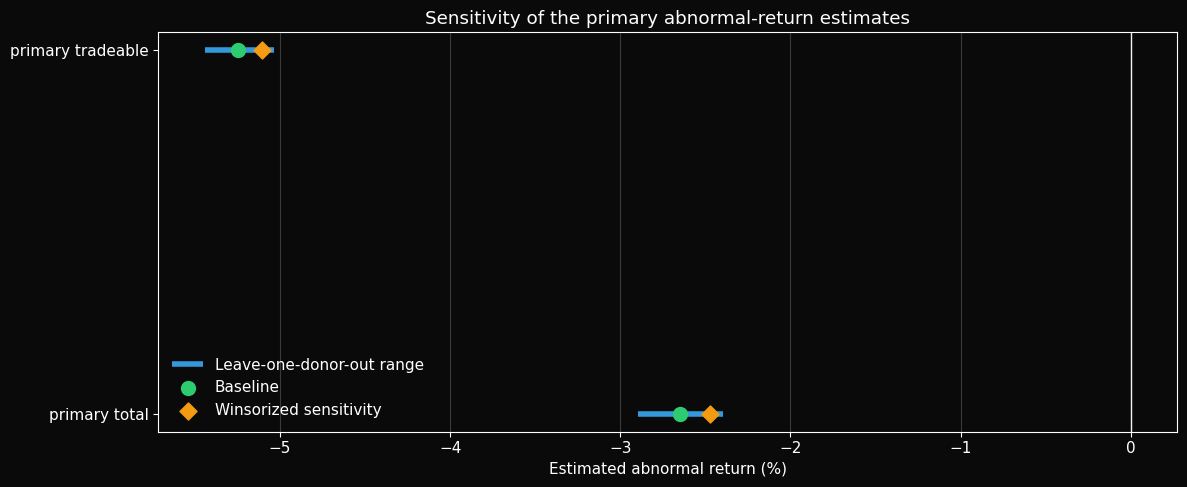

In [165]:
def fit_sensitivity_pcr(
    training_data,
    donors,
    selected_k,
    winsor_limits=None,
):
    '''
    Fit PCR on a specified donor subset.

    If winsor_limits is supplied, bounds are learned only from
    the training data.
    '''
    required_columns = [
        TARGET,
        *donors,
    ]

    training_sample = (
        training_data[
            required_columns
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
        .copy()
    )

    lower_bounds = None
    upper_bounds = None

    if winsor_limits is not None:
        lower_probability, upper_probability = (
            winsor_limits
        )

        lower_bounds = (
            training_sample.quantile(
                lower_probability
            )
        )

        upper_bounds = (
            training_sample.quantile(
                upper_probability
            )
        )

        fitted_sample = (
            training_sample.clip(
                lower=lower_bounds,
                upper=upper_bounds,
                axis=1,
            )
        )
    else:
        fitted_sample = training_sample

    X = fitted_sample[
        donors
    ]

    y = fitted_sample[
        TARGET
    ]

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(
        X
    )

    component_count = min(
        selected_k,
        len(donors),
    )

    pca = PCA(
        n_components=component_count,
        svd_solver='full',
    )

    scores = pca.fit_transform(
        X_scaled
    )

    regression = LinearRegression()

    regression.fit(
        scores,
        y,
    )

    return {
        'donors': list(donors),
        'selected_k': component_count,
        'scaler': scaler,
        'pca': pca,
        'regression': regression,
        'lower_bounds': lower_bounds,
        'upper_bounds': upper_bounds,
    }


def predict_sensitivity_pcr(
    model,
    donor_row,
):
    donor_input = (
        donor_row[
            model['donors']
        ]
        .astype(float)
        .copy()
    )

    if model['lower_bounds'] is not None:
        donor_input = donor_input.clip(
            lower=model[
                'lower_bounds'
            ][model['donors']],
            upper=model[
                'upper_bounds'
            ][model['donors']],
        )

    scaled_input = (
        model['scaler']
        .transform(
            donor_input
            .to_numpy()
            .reshape(1, -1)
        )
    )

    scores = (
        model['pca']
        .transform(
            scaled_input
        )
    )

    return float(
        model['regression']
        .predict(scores)[0]
    )


def sensitivity_effect_for_window(
    window_name,
    cc_model,
    oc_model,
):
    window = window_lookup[
        window_name
    ]

    actual_log_return = 0.0
    expected_log_return = 0.0

    for event_time, return_type in (
        return_legs_for_window(window)
    ):
        date = as_session_date(
            session_for_event_time(
                event_time
            )
        )

        if return_type == 'cc':
            return_data = cc_log_returns
            model = cc_model
        else:
            return_data = oc_log_returns
            model = oc_model

        actual_log_return += float(
            return_data.loc[
                date,
                TARGET,
            ]
        )

        expected_log_return += (
            predict_sensitivity_pcr(
                model,
                return_data.loc[date],
            )
        )

    return (
        np.expm1(
            actual_log_return
            - expected_log_return
        )
        * 100
    )


SENSITIVITY_WINDOWS = [
    'primary_total',
    'primary_tradeable',
]

cc_selected_k = (
    cc_holdout_result[
        'selected_k'
    ]
)

oc_selected_k = (
    oc_holdout_result[
        'selected_k'
    ]
)

sensitivity_rows = []


# Baseline and leave-one-donor-out specifications.
donor_exclusions = [
    None,
    *DONORS,
]

for excluded_donor in donor_exclusions:
    sensitivity_donors = [
        donor
        for donor in DONORS
        if donor != excluded_donor
    ]

    cc_sensitivity_model = (
        fit_sensitivity_pcr(
            cc_model_data,
            sensitivity_donors,
            cc_selected_k,
        )
    )

    oc_sensitivity_model = (
        fit_sensitivity_pcr(
            oc_model_data,
            sensitivity_donors,
            oc_selected_k,
        )
    )

    if excluded_donor is None:
        specification = 'baseline_refit'
        specification_type = 'baseline'
    else:
        specification = (
            f'without_{excluded_donor}'
        )
        specification_type = (
            'leave_one_out'
        )

    for window_name in SENSITIVITY_WINDOWS:
        sensitivity_rows.append(
            {
                'specification':
                    specification,
                'specification_type':
                    specification_type,
                'window':
                    window_name,
                'abnormal_return_pct':
                    sensitivity_effect_for_window(
                        window_name,
                        cc_sensitivity_model,
                        oc_sensitivity_model,
                    ),
            }
        )


# Winsorized training-data sensitivity.
WINSOR_LIMITS = (
    0.01,
    0.99,
)

winsorized_cc_model = (
    fit_sensitivity_pcr(
        cc_model_data,
        DONORS,
        cc_selected_k,
        winsor_limits=WINSOR_LIMITS,
    )
)

winsorized_oc_model = (
    fit_sensitivity_pcr(
        oc_model_data,
        DONORS,
        oc_selected_k,
        winsor_limits=WINSOR_LIMITS,
    )
)

for window_name in SENSITIVITY_WINDOWS:
    sensitivity_rows.append(
        {
            'specification':
                'winsorized_1_99',
            'specification_type':
                'winsorized',
            'window':
                window_name,
            'abnormal_return_pct':
                sensitivity_effect_for_window(
                    window_name,
                    winsorized_cc_model,
                    winsorized_oc_model,
                ),
        }
    )


sensitivity_results = (
    pd.DataFrame(
        sensitivity_rows
    )
)

sensitivity_table = (
    sensitivity_results
    .pivot(
        index='specification',
        columns='window',
        values='abnormal_return_pct',
    )
)

display(
    sensitivity_table.round(4)
)


leave_one_out_summary = (
    sensitivity_results.loc[
        sensitivity_results[
            'specification_type'
        ].eq('leave_one_out')
    ]
    .groupby('window')[
        'abnormal_return_pct'
    ]
    .agg(
        minimum='min',
        median='median',
        maximum='max',
    )
)

display(
    leave_one_out_summary.round(4)
)


fig, ax = plt.subplots(
    figsize=(12, 5)
)

y_positions = np.arange(
    len(SENSITIVITY_WINDOWS)
)

for position, window_name in enumerate(
    SENSITIVITY_WINDOWS
):
    window_results = (
        sensitivity_results.loc[
            sensitivity_results[
                'window'
            ].eq(window_name)
        ]
    )

    leave_one_out_values = (
        window_results.loc[
            window_results[
                'specification_type'
            ].eq('leave_one_out'),
            'abnormal_return_pct',
        ]
    )

    baseline_value = float(
        window_results.loc[
            window_results[
                'specification_type'
            ].eq('baseline'),
            'abnormal_return_pct',
        ].iloc[0]
    )

    winsorized_value = float(
        window_results.loc[
            window_results[
                'specification_type'
            ].eq('winsorized'),
            'abnormal_return_pct',
        ].iloc[0]
    )

    ax.hlines(
        y=position,
        xmin=leave_one_out_values.min(),
        xmax=leave_one_out_values.max(),
        color='#3498db',
        linewidth=4,
        label=(
            'Leave-one-donor-out range'
            if position == 0
            else None
        ),
    )

    ax.scatter(
        baseline_value,
        position,
        color='#2ecc71',
        marker='o',
        s=100,
        zorder=3,
        label=(
            'Baseline'
            if position == 0
            else None
        ),
    )

    ax.scatter(
        winsorized_value,
        position,
        color='#f39c12',
        marker='D',
        s=75,
        zorder=3,
        label=(
            'Winsorized sensitivity'
            if position == 0
            else None
        ),
    )


ax.axvline(
    0,
    color='#f2f2f2',
    linewidth=1,
)

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    [
        name.replace('_', ' ')
        for name in SENSITIVITY_WINDOWS
    ]
)

ax.set_xlabel(
    'Estimated abnormal return (%)'
)

ax.set_ylabel('')

ax.set_title(
    'Sensitivity of the primary abnormal-return estimates'
)

ax.legend(
    frameon=False
)

ax.grid(
    axis='y',
    visible=False,
)

plt.tight_layout()
plt.show()

## 10.6 Robustness findings

### Multiple-window inference

The unadjusted empirical placebo p-values are approximately:

| Window | Empirical p-value | Holm-adjusted p-value |
|---|---:|---:|
| Announcement reaction: total | 0.500 | 0.500 |
| Announcement reaction: tradeable | 0.031 | 0.125 |
| Primary total | 0.127 | 0.254 |
| Primary tradeable | 0.032 | 0.125 |

The two tradeable windows are unusual when each is examined separately, however, neither remains significant at the 5% level after correcting for the four related windows. This does not show that the negative return is false but it means that 63 holdout observations do not provide enough evidence to make a strong overall statistical claim after allowing for all the windows examined.

### Leave-one-donor-out stability

The primary estimates are extremely stable when each donor is removed separately:

| Window | Most negative estimate | Median estimate | Least negative estimate |
|---|---:|---:|---:|
| Primary total | −2.89% | −2.60% | −2.40% |
| Primary tradeable | −5.44% | −5.22% | −5.03% |

Every specification produces the same sign and a similar magnitude and single donor is responsible for the negative result. This is particularly interesting for lower-correlation donors such as MarketAxess, Cboe and CME: removing them individually does not materially change the estimate, so their inclusion is not driving the final conclusion.

### Winsorization sensitivity

The raw and winsorized models produce:

| Window | Raw-return model | Winsorized model |
|---|---:|---:|
| Primary total | −2.65% | −2.47% |
| Primary tradeable | −5.24% | −5.10% |

Winsorization makes the estimates only slightly less negative and extreme training observations therefore do not explain the main result.

### Overall robustness assessment

The main tradeable result is robust to:

- the selected number of components
- removing any individual donor
- winsorizing extreme training returns

The result is also supported by a very large volume concentration on the implementation-close proxy. Its main weakness is statistical power: the tradeable estimate has a pointwise interval below zero, but it does not survive the conservative multiple-window correction, the long anticipation and post-implementation estimates are even less precise.

---

## 11. Conclusion

I studied how Interactive Brokers' stock behaved around its promotion to the S&P 500: IBKR entered the S&P 500 and left the S&P MidCap 400 before trading opened on 28 August 2025. The event should therefore be interpreted as a **net index migration** (S&P 500 inclusion minus S&P MidCap 400 deletion) rather than as a pure S&P 500 inclusion. The event date and the two simultaneous index changes are confirmed by the official [S&P Dow Jones Indices announcement](https://press.spglobal.com/2025-08-25-Interactive-Brokers-Group-Set-to-Join-S-P-500%2C-Talen-Energy-to-Join-S-P-MidCap-400-and-Kinetik-Holdings-to-Join-S-P-SmallCap-600).

### What the model measured

A PCA regression model was estimated using the pre-event returns of comparable financial companies and market-infrastructure firms. PCA condensed their shared movements into a small number of components, these components were then used to estimate the return IBKR would normally have earned given the movements of the control universe.

The difference between IBKR's actual return and its model-implied return was defined as the abnormal return:


$$AR_t=r^{IBKR}_t-\widehat r^{IBKR}_t$$


This follows the standard event-study idea of comparing the observed return with an estimate of the stock's normal return. See [MacKinlay's event-study framework](https://ideas.repec.org/a/aea/jeclit/v35y1997i1p13-39.html).

The model is an **ex-post counterfactual** and it is not a forecast available before trading began. It uses the contemporaneous returns of the donor securities to remove market and peer movements observed on the same day.

### Main results

The answer depends importantly on the exact return interval:

- The announcement-total abnormal return was approximately **−0.63%**. This includes the positive overnight response following the announcement and the entire next trading session
- The announcement-tradeable abnormal return was approximately **−3.28%**. This begins at the next market open and therefore excludes the overnight price gap
- The primary-total abnormal return was approximately **−2.65%** from the pre-announcement close through the implementation-close proxy
- The primary-tradeable abnormal return was approximately **−5.24%** from the first post-announcement open through the implementation-close proxy
- The implementation-session abnormal return was approximately **−2.03%**

The stronger negative tradeable returns arose because IBKR initially experienced a positive abnormal overnight gap, followed by a substantial negative intraday reversal. The result therefore cannot be summarized by one daily closing return without considering when an investor could actually have entered the trade.

The wider anticipation and post-implementation windows did not provide precise evidence of persistent abnormal performance, their uncertainty intervals are wide and crossed zero.

### Model validation and robustness

The PCA regression was tested using chronological walk-forward validation and every validation prediction was produced using only information available before that observation. The final 63-session holdout was kept separate from model selection and later used to measure the model's genuine out-of-sample errors.

Historical residual placebos compared the real event with equally long fake events constructed from this holdout. The announcement-tradeable and primary-tradeable windows produced empirical p-values of approximately **0.031** and **0.032**. Considered separately, both are below 5%.
However, four related inferential windows were examined and, after applying the Holm correction for multiple testing, both adjusted p-values increased to approximately **0.125**. None of the four windows was therefore statistically significant at the family-wide 5% level.

The estimated economic effect was stable across alternative model specifications:

- removing one donor security at a time left the primary-tradeable estimate between approximately **−5.44% and −5.03%**
- winsorizing extreme training returns changed it only from approximately **−5.24% to −5.10%**

This suggests that negative estimate is therefore not being generated by one particular donor or by a few extreme observations.

### Interpretation

The evidence supports a clear but limited conclusion:

> IBKR experienced economically meaningful negative abnormal performance over the post-announcement tradeable period relative to the PCA counterfactual. The sign and magnitude are robust to reasonable changes in model construction, but the evidence does not remain statistically significant after correcting for the four event windows examined.

This is best described as **robust and suggestive evidence**, rather than conclusive causal evidence.

The negative result is not necessarily inconsistent with an index promotion. Greenwood and Sammon document that the average S&P 500 inclusion effect has become much smaller in recent decades, despite the growth of index-linked assets. See [The Disappearing Index Effect](https://www.nber.org/papers/w30748).

Moreover, IBKR's event combined buying related to S&P 500 entry with selling related to S&P MidCap 400 deletion, the analysis therefore estimates the market response to the **net migration**, not the gross demand generated by S&P 500 trackers alone.

### Identification limits

The PCA model removes return movements shared with the donor universe, but it cannot determine what caused the remaining residual. The abnormal return may contain:

- passive index demand
- active investor repositioning
- anticipation before the announcement
- liquidity provision and arbitrage activity
- IBKR-specific information
- model error or omitted risk factors

Yahoo Finance provides daily market prices and volume, but not closing-auction imbalances, ETF-level orders, dealer inventories or investor identities. The implementation-session return is consequently a daily proxy for the implementation period, not a direct measurement of ETF purchases. 

The inference also assumes that the 63-session holdout represents the errors the model could normally have made during the event. With such a small sample, the tails of the placebo and bootstrap distributions remain imprecise.